# SR250 UWB (Ultra-Wide Band) Radar Visualisation and Digital Beamforming
# Searching for the best blobs

## 1. Import required libraries

In this part we install the required libraries for the notebook.

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from typing import Optional, List

## 2. Decluttering

In [2]:
# Size of the moving windows, necessary also for DBF
W = 20

In [3]:
def decluttering_ma(cirs: np.ndarray, W: int) -> np.ndarray:
    """
    Performs decluttering on the time series of CIRs using a moving average
    background subtraction method, as described in Equation (9) of the thesis.

    The decluttered signal s_hat_n,m[k] is calculated as:
    s_hat_n,m[k] = s_n,m[k] - (1/W) * sum(s_n,i[k] for i from m-W+1 to m)

    Args:
        cirs (np.ndarray): Input radar data matrix of shape (time_frames, range_bins),
                           containing complex data.
        W (int): The window dimension (number of subsequent radar frames)
                 to be considered for the moving average. W must be >= 1.

    Returns:
        np.ndarray: The decluttered radar data matrix of the same shape as cirs,
                    containing complex data. The first (W-1) frames will be zeros.
    """
    if cirs.shape[0] == 0:
        return cirs
    
    if not isinstance(W, int) or W < 1:
        raise ValueError("Window size 'W' must be an integer and W >= 1.")

    num_frames, num_range_bins = cirs.shape
    result = np.zeros_like(cirs, dtype=np.complex64)

    # The thesis states: "the first scan of each window must be rejected"
    # This means for frames where a full 'W' window is not available,
    # the output is effectively zero or undefined. We'll set them to zero.
    
    # Loop from the (W-1)-th frame (0-indexed) onwards,
    # as this is the first frame for which a full 'W'-sized window is available.
    for m in range(W - 1, num_frames):
        # Define the window: from (m - W + 1) up to and including m
        # np.mean calculates the mean along axis=0 (frames) for each range bin
        window_average = np.mean(cirs[m - W + 1 : m + 1, :], axis=0)
        
        # Apply the subtraction formula: current_frame - window_average
        result[m, :] = cirs[m, :] - window_average
        
    return result

## 3. Process a file

First we load a single .npy file, applying decluttering, then show the time-distance plot obtained as an average of the data coming from the three files.

In [4]:
def load_declutter_sr250_file(filename):
    """
    Loads and declutters a single SR250 antenna file.
    """
    if not os.path.exists(filename):
        print(f"Warning: File not found, skipping: {filename}")
        return None

    raw_frames_full = np.load(filename)  # (time, range_bins)
    # Keep only the first 50 bins
    raw_frames = raw_frames_full[:, :50]
    # Apply decluttering to remove the static background.
    decluttered_matrix = decluttering_ma(raw_frames, W)
    
    return decluttered_matrix

In [5]:
def visualise_sr250(base_filename):
    """
    Loads, processes, and visualizes SR250 data from three antennas.
    Returns the list of complex decluttered matrices and their magnitudes.
    """
    # Automatically find paths for all three antennas
    file_list = []
    if "_sr250_rx0" in base_filename:
        base_path = base_filename.replace("_sr250_rx0.npy", "")
        for i in range(3):
            file_list.append(f"{base_path}_sr250_rx{i}.npy")
    else:
        print("Error: Please provide the path to an 'sr250_rx0' file.")
        return [], [] # Return empty lists for both complex and magnitude

    # --- Process each antenna and store the resulting complex matrix ---
    all_decluttered_complex = []
    all_magnitudes = []
    for f in file_list:
        # Process the file to get the complex decluttered matrix
        decluttered_result = load_declutter_sr250_file(f)
        if decluttered_result is not None:
            # Remove the first W time frames from the decluttered data
            decluttered_result = decluttered_result[W:, :]
            # Store complex data
            all_decluttered_complex.append(decluttered_result)
            # Also store magnitude for original visualization if needed
            all_magnitudes.append(np.abs(decluttered_result))
    
    if not all_decluttered_complex:
        print("Error: No data was processed. Exiting.")
        return [], []
    
    # Only complex data is needed for beamforming, so we return just that.
    return all_decluttered_complex

## 4. Apply Digital Beamforming

In [6]:
# --- Radar Parameters ---
d = 1.75e-2          # Distance between rx antenna elements for azimuth
f = 7.987e9          # Center frequency of radar pulse (Hz) -> 7.737 - 8.237 GHz
c = 299792458        # Speed of light (m/s)

l = c/f              # Wavelength
k = 2*np.pi/l        # Wavenumber

# Beam steering angles for azimuth
min_angle = -45
max_angle = 45
num_angles = round((max_angle - min_angle + 1) / 2)
print("Number of angles considered: ", num_angles)
beam_steering_angles = np.deg2rad(np.linspace(min_angle, max_angle, num_angles))

# Receivers to be considered, RX0 and RX2
receivers = [0, 2]
# Initial time frame for window plot
initial_time_frame = 0
# Target time frame for window plot, 20 time frames correspond to 1 second
target_time_frame = 20

Number of angles considered:  46


In [7]:
# --- Beamforming Helper Functions ---
def compute_bf_weights(angle_range, delta, k, num_rx_elements):
    """
    Computes beamforming weights for a linear array.
    
    Args:
        angle_range (np.ndarray): Array of angles (in radians) for which to compute weights.
        delta (float): Distance between adjacent antenna elements.
        k (float): Wavenumber (2*pi/lambda).
        num_rx_elements (int): Number of receive antenna elements.
        
    Returns:
        np.ndarray: Beamforming weights of shape (len(angle_range), num_rx_elements).
    """
    bf_weights = np.zeros((angle_range.shape[0], num_rx_elements), dtype="complex")
    for i in range(angle_range.shape[0]):      # Loop over angles
        for j in range(num_rx_elements):       # Loop over antenna elements
            # Phase shift for element j at angle_range[i]
            bf_weights[i, j] = np.exp(-1j * k * delta * j * np.sin(angle_range[i]))
    return bf_weights

In [8]:
def perform_azimuth_beamforming(rx0_complex_data, rx1_complex_data, d, k, beam_steering_angles):
    """
    Performs azimuth beamforming on complex data from rx0 and rx1 antennas.
    This version processes all time frames individually, producing a 3D output.
    
    Args:
        rx0_complex_data (np.ndarray): Complex CIRs from rx0 (time_frames, range_bins).
        rx1_complex_data (np.ndarray): Complex CIRs from rx1 (time_frames, range_bins).
        d (float): Distance between rx0 and rx1 antennas (element spacing).
        k (float): Wavenumber (2*pi/lambda).
        beam_steering_angles (np.ndarray): Array of angles in radians for beamsteering.

    Returns:
        np.ndarray: Beamformed data of shape (time_frames, range_bins, angles), or None if error.
    """

    # Resize the range bins due to slight mismatch
    rx0_complex_data = rx0_complex_data[:, 0:45]
    rx1_complex_data = rx1_complex_data[:, 2:47]
    
    if rx0_complex_data is None or rx1_complex_data is None:
        print("Error: Input data for beamforming is missing.")
        return None
    if rx0_complex_data.shape != rx1_complex_data.shape:
        print("Error: rx0 and rx1 data shapes do not match. Cannot perform beamforming.")
        return None
    else:
        print(f"Shape of the antennas: {rx0_complex_data.shape}, with dtype {rx0_complex_data.dtype}")
    
    num_time_frames = rx0_complex_data.shape[0]   # Slow time
    num_range_bins = rx0_complex_data.shape[1]    # Fast time
    num_rx_elements = 2
    num_angles = beam_steering_angles.shape[0]    # Number of angles to be considered

    # Compute beamforming weights. These are constant for all time frames and range bins.
    bf_weights = compute_bf_weights(beam_steering_angles, d, k, num_rx_elements)

    # Initialize a 3D array to store beamformed results
    beamformed_3d_result = np.zeros((num_time_frames, num_range_bins, num_angles), dtype=complex)

    # This version performs the same carried out by bf.py but exploiting NumPY vectorized operations.
    for t in range(num_time_frames):
        # Extract the complex CIRs for the current time frame from both RX antennas       
        # and stack them to form the input for beamforming for the current frame.
        # data_for_current_frame_all_bins will have shape (num_rx_elements, range_bins)
        data_for_current_frame_all_bins = np.stack([rx0_complex_data[t, :], rx1_complex_data[t, :]], axis=0)

        # Perform matrix multiplication for all range bins in the current frame simultaneously
        # (num_angles, num_rx_elements) @ (num_rx_elements, num_range_bins)
        # Result of dot product: (num_angles, num_range_bins)
        beamformed_slice_transposed = np.dot(bf_weights, data_for_current_frame_all_bins)
        
        # Transpose the result to get (range_bins, angles) for this time slice
        beamformed_3d_result[t, :, :] = beamformed_slice_transposed.T
            
    print("Beamforming complete for all frames and range bins.")
    return beamformed_3d_result

In [9]:
def show_range_angle_plot(matrix, angles_rad, title="Beamformed Range-Azimuth Image", range_conversion_factor=10, gt_highlight_coords_list: Optional[List[tuple]] = None):
    """
    Visualizes the beamformed data as a 2D heatmap (Distance vs. Azimuth Angle).
    Converts range bins to meters for visualization.
    Optionally draws cross markers at specified ground truth positions.
    
    Args:
        matrix (np.ndarray): The beamformed data, shape (range_bins, angles).\
                              This should be the magnitude for plotting.
        angles_rad (np.ndarray): Array of angles in radians used for beamsteering.
        title (str): Title for the plot.
        range_conversion_factor (int/float): Number of bins per meter.
        gt_highlight_coords_list (Optional[List[tuple]]): A list of (range_bin_idx, angle_idx) tuples
                                                           to draw cross markers on the heatmap.
                                                           If None or empty, no markers are drawn.
    """
    print("Generating Beamformed plot...\n")

    heatmap_data = matrix
    fig, ax = plt.subplots(figsize=(12, 5))

    angles_deg = np.rad2deg(angles_rad)

    # Convert range bins to meters for the y-axis extent
    min_range_meters = 0
    max_range_meters = heatmap_data.shape[0] / range_conversion_factor # (number of range bins) / (bins per meter)

    # extent defines (left, right, bottom, top) in data coordinates
    # For imshow: x-axis maps to columns, y-axis maps to rows.
    # matrix is (rows=range_bins, cols=angles) -> extent = [x_min, x_max, y_min, y_max]
    extent = [angles_deg.min(), angles_deg.max(), min_range_meters, max_range_meters] 
    

    im = ax.imshow(
        heatmap_data, 
        aspect='auto', 
        origin='lower', # Origin lower for distance on Y-axis (0 at bottom)
        cmap='gist_gray',
        interpolation='nearest',
        vmin=np.min(heatmap_data),
        vmax=np.max(heatmap_data),
        extent=extent # Map data coordinates to image pixels
    )

    ax.set_title(title)
    ax.set_xlabel("Azimuth Angle (degrees)")
    ax.set_ylabel("Distance (meters)") # Changed label to meters
    fig.colorbar(im, ax=ax, label="Beamformed Signal Magnitude")
    
    # Set x-axis ticks to display angles more meaningfully
    num_ticks_x = 7 # Example, adjust as needed
    tick_indices_x = np.linspace(0, len(angles_deg) - 1, num_ticks_x).astype(int)
    ax.set_xticks(angles_deg[tick_indices_x])
    ax.set_xticklabels([f"{a:.0f}°" for a in angles_deg[tick_indices_x]])

    # Set y-axis ticks to display meters more meaningfully
    # Determine appropriate interval for y-axis ticks based on max_range_meters
    if max_range_meters <= 1:
        y_tick_interval = 0.1
    elif max_range_meters <= 5:
        y_tick_interval = 0.5
    else:
        y_tick_interval = 1.0
    
    y_ticks = np.arange(min_range_meters, max_range_meters + y_tick_interval, y_tick_interval)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{d:.1f}m" for d in y_ticks])

    # --- Add cross markers for ground truth positions if provided ---
    if gt_highlight_coords_list:
        for i, (r_idx, a_idx) in enumerate(gt_highlight_coords_list):
            # Convert range_bin_idx to meters and angle_idx to degrees for plotting
            plot_y_meters = r_idx / range_conversion_factor
            plot_x_degrees = angles_deg[a_idx]
            # Use `label` for the first marker only, or handle labels explicitly for each
            label_text = 'Ground Truth Position' if i == 0 else None
            ax.scatter(plot_x_degrees, plot_y_meters, marker='x', color='red', s=200, linewidth=3, label=label_text)
        if gt_highlight_coords_list: # Only show legend if at least one marker was plotted
            ax.legend()

    plt.tight_layout()
    plt.show()

In [10]:
def normalize_range_angle_map(matrix: np.ndarray) -> np.ndarray:
    """
    Normalizes a 2D Range-Angle map to the range [0, 1] using min-max scaling,
    as described in Equation (11) of the thesis.

    Args:
        matrix (np.ndarray): The input 2D Range-Angle map.

    Returns:
        np.ndarray: The normalized map.
    """
    min_val = np.min(matrix)
    max_val = np.max(matrix)
    if max_val == min_val: # Avoid division by zero for uniform matrices
        return np.zeros_like(matrix)
    normalized_matrix = (matrix - min_val) / (max_val - min_val)
    return normalized_matrix

In [11]:
# Define 9 ground truth positions (range_bin, angle_index)
# The dimensions of the beamformed 2D matrix (range-azimuth) are (45, 46).
# Range bins typically go from 0 to 44. Angle indices typically go from 0 to 45.
ground_truth_positions = {
    "2": (15, 35),
    "3": (15, 23),
    "4": (15, 12),
    "7": (25, 35),
    "8": (25, 23),
    "9": (25, 12),
    "12": (35, 35),
    "13": (35, 23),
    "14": (35, 12)
}

# Threshold for detection for normalised values (0 to 1)
detection_threshold = 0.6

# Window parameters for time series analysis
window_size_frames = 20  # Number of time frames in each analysis window
stride_frames = 10       # Step size (stride) for sliding the window

In [12]:
def extract_scenario_numbers(filepath: str) -> List[str]:
    """
    Extracts a list of scenario numbers from a SR250 radar file path.
    These numbers are typically hyphen-separated digits found immediately before
    '_Still position_' or '_Moving position_'.
    This enhanced version handles cases with trailing hyphens, multiple hyphens
    between numbers, and optional whitespace before the '_Still position_' or
    '_Moving position_' marker.

    Examples based on common interpretations of such filenames:
    - "/path/to/12-13-14_Still position_...rx0.npy" -> ['12', '13', '14']
    - "/path/to/5_Moving position_...rx0.npy" -> ['5']
    - "/path/to/(move)2-12-9-3-13-14-4-8-13-2_Still position_...rx0.npy" -> ['2', '12', '9', '3', '13', '14', '4', '8', '13', '2']
    - "/path/to/7-8-9-_Still position_...rx0.npy" -> ['7', '8', '9']
    - "/path/to/2--8-14_Still position_...rx0.npy" -> ['2', '8', '14']
    - "/path/to/2-12-14 _Still position_20250618-115119_sr250_rx0.npy" -> ['2', '12', '14'] (NEW case handled)
    - "/path/to/test-no-numbers_Still position_...rx0.npy" -> [] (no numbers in the specific pattern)
    - "/path/to/no_position_marker_file.npy" -> [] (no position marker)

    Args:
        filepath (str): The full path to the SR250 radar data file.

    Returns:
        List[str]: A list of strings, where each string is an extracted number.
                   Returns an empty list if no such pattern is found.
    """
    filename = os.path.basename(filepath)

    # '([0-9-]+)': This captures one or more occurrences of digits (0-9) or hyphens (-).
    # This will capture strings like "7-8-9-" or "2--8-14".
    # The subsequent split and filter will clean these into actual numbers.
    # '\s*': Matches zero or more whitespace characters. This is the key addition.
    pattern = r'([0-9-]+)\s*_(?:Still|Moving) position_' # MODIFIED LINE

    match = re.search(pattern, filename)

    if match:
        numbers_str = match.group(1) # Get the captured sequence (e.g., "7-8-9-", "2--8-14")
        # Split the captured string by '-' and then use a list comprehension
        # to filter out any empty strings that result from multiple or trailing hyphens.
        return [num for num in numbers_str.split('-') if num]
    else:
        return []

In [13]:
def analyze_blobs_in_time_windows(
    beamformed_3d_data: np.ndarray,
    ground_truth_positions: dict,
    detection_threshold: float,
    window_size_frames: int,
    stride_frames: int,
    gt_labels_to_analyze: Optional[List[str]] = None # New parameter here
) -> dict:
    """
    Analyzes beamformed data in sliding time windows to find "blobs" (high-intensity regions)
    at predefined ground truth positions. It processes each window by coherently summing,
    taking the absolute value, and then normalizing before checking against a threshold.

    Args:
        beamformed_3d_data (np.ndarray): The 3D beamformed data of shape
                                         (time_frames, range_bins, angles).
                                         Expected to contain complex values.
        ground_truth_positions (dict): A dictionary where keys are GT labels (str)
                                       and values are (range_bin_idx, angle_idx) tuples.
        detection_threshold (float): The normalized magnitude threshold for detection (0 to 1).
        window_size_frames (int): The number of time frames in each window.
        stride_frames (int): The step size (stride) for sliding the window.
        gt_labels_to_analyze (Optional[List[str]]): A list of specific ground truth labels
                                                    (e.g., ["2", "4"]) to analyze.
                                                    If None, all positions in `ground_truth_positions`
                                                    will be analyzed.

    Returns:
        dict: A dictionary where keys are ground truth labels (e.g., "2")
              and values are lists of time frames (start_frame_idx) where
              the blob was detected at that position. Only includes labels that were analyzed.
    """
    num_total_frames = beamformed_3d_data.shape[0]

    # Determine which GT labels to actually analyze
    if gt_labels_to_analyze is None:
        print("No ground truth label specified!")
        return None
    else:
        # Filter for labels that actually exist in ground_truth_positions
        actual_gt_labels = [label for label in gt_labels_to_analyze if label in ground_truth_positions]
        if len(actual_gt_labels) != len(gt_labels_to_analyze):
            missing_labels = set(gt_labels_to_analyze) - set(ground_truth_positions.keys())
            print(f"Warning: The following requested GT labels were not found in `ground_truth_positions` and will be skipped: {list(missing_labels)}")

    detected_windows = {gt_label: [] for gt_label in actual_gt_labels}
    
    print(f"\n--- Analyzing blobs in time windows (Window size: {window_size_frames} frames, Stride: {stride_frames} frames) ---")
    print(f"Total time frames available for analysis: {num_total_frames}")
    print(f"Detection threshold for normalized value: {detection_threshold}")
    print(f"Analyzing only the following GT positions: {actual_gt_labels}")

    # Iterate through the time frames using the specified window and stride
    # The loop condition `num_total_frames - window_size_frames + 1` ensures the last window fits completely.
    for start_frame in range(0, num_total_frames - window_size_frames + 1, stride_frames):
        end_frame = start_frame + window_size_frames
        
        # Extract the complex data for the current time window
        current_window_complex_data = beamformed_3d_data[start_frame:end_frame, :, :]

        # Aggregate the data for the current window.
        # As per the problem description (and `apply_bf_pipeline`'s coherent_incoherent_avg = 0),
        # we perform coherent summation (sum complex values then take absolute magnitude).
        aggregated_data_2d = np.abs(np.sum(current_window_complex_data, axis=0))

        # Normalize the 2D aggregated data to a [0, 1] range
        normalized_data_2d = normalize_range_angle_map(aggregated_data_2d)

        # Check the normalized value at each selected ground truth position
        for gt_label in actual_gt_labels:
            r_idx, a_idx = ground_truth_positions[gt_label] # Get coordinates for the current label
            
            # Basic bounds checking for safety, though indices should be pre-validated
            if 0 <= r_idx < normalized_data_2d.shape[0] and 0 <= a_idx < normalized_data_2d.shape[1]:
                value_at_position = normalized_data_2d[r_idx, a_idx]
                if value_at_position >= detection_threshold:
                    detected_windows[gt_label].append(start_frame)
            else:
                print(f"Warning: Ground truth position '{gt_label}' ({r_idx}, {a_idx}) is out of bounds for matrix shape {normalized_data_2d.shape}. Skipping.")

    print("\n--- Blob analysis complete ---")
    for gt_label, frames in detected_windows.items():
        if frames:
            print(f"  '{gt_label}' detected in {len(frames)} windows, starting at frames: {frames}")
        else:
            print(f"  '{gt_label}' not detected above threshold in any window.")
            
    return detected_windows

In [14]:
def apply_bf_pipeline (base_file, rx_s = [0, 2], coherent_incoherent_avg = 0, gt_labels_to_highlight: Optional[List[str]] = None):
    # Load and declutter data for all antennas
    all_complex_data = visualise_sr250(base_file)

    if not all_complex_data or len(all_complex_data) <= max(rx_s):
        print(f"Error: Not enough complex data returned from visualise_sr250 or specified RX indices ({rx_s}) are out of bounds.")
        return None # Indicate failure

    # Select the data for the two specified receivers (e.g., RX0 and RX2)
    antenna1_data = all_complex_data[rx_s[0]]
    antenna2_data = all_complex_data[rx_s[1]]

    # Perform azimuth beamforming, return a 3D array (time_frames, range_bins, angles)
    beamformed_3d_data = perform_azimuth_beamforming(antenna1_data, antenna2_data, d, k, beam_steering_angles)
    
    if beamformed_3d_data is None:
        print("Beamforming failed. Exiting apply_bf_pipeline.")
        return None # Indicate failure

    print(f"Shape of the full beamformed data: {beamformed_3d_data.shape} with dtype {beamformed_3d_data.dtype}")
    
    # Aggregate the 3D data for 2D visualization (Range-Azimuth Heatmap) for the first N frames
    # This visualization section uses the original notebook's logic for the display window (initial_time_frame to target_time_frame).
    vis_target_time_frame = 20 # 1 sec of data, original variable name `target_time_frame`

    # Ensure visualization window does not exceed available frames
    vis_end_frame = min(vis_target_time_frame + 1, beamformed_3d_data.shape[0])

    if coherent_incoherent_avg == 0:
        # Coherent averaging for visualization
        print("Applying coherent averaging for visualization (first 20 frames)...")
        aggregated_beamformed_data_vis = np.abs(np.sum(beamformed_3d_data[initial_time_frame:vis_end_frame, :, ], axis=0))
    elif coherent_incoherent_avg == 1:
        # Incoherent averaging for visualization
        print("Applying incoherent averaging for visualization (first 20 frames)....")
        aggregated_beamformed_data_vis = np.sum(np.abs(beamformed_3d_data[initial_time_frame:vis_end_frame, :, ]), axis=0)
    else:
        # Incoherent averaging with mean for visualization
        print("Applying incoherent averaging by mean for visualization (first 20 frames)...")
        aggregated_beamformed_data_vis = np.mean(np.abs(beamformed_3d_data[initial_time_frame:vis_end_frame, :, ]), axis=0)
    
    # Normalization for visualization
    normalized_beamformed_data_vis = normalize_range_angle_map(aggregated_beamformed_data_vis)
    title = f"Beamforming ({vis_target_time_frame} time frames) - {os.path.basename(base_file).replace('_sr250_rx0.npy', '')}"
    
    # Determine ground truth coordinates to highlight, if requested
    gt_coords_for_plot_list = []
    if gt_labels_to_highlight:
        for label in gt_labels_to_highlight:
            if label in ground_truth_positions:
                gt_coords_for_plot_list.append(ground_truth_positions[label])
            else:
                print(f"Warning: Requested GT label '{label}' not found in ground_truth_positions. Skipping highlight for this label.")

    show_range_angle_plot(normalized_beamformed_data_vis, beam_steering_angles, title, gt_highlight_coords_list=gt_coords_for_plot_list)
    
    # Return the full 3D beamformed data for further analysis (e.g., blob detection)
    return beamformed_3d_data

In [15]:
def extract_best_blobs (base_filename):
    print(f"--- FILENAME: {base_filename} ---\n")
    
    labels = extract_scenario_numbers(base_filename)
    
    # Call the modified apply_bf_pipeline to get the full 3D beamformed data
    # Pass the selected ground truth label to highlight
    full_beamformed_data = apply_bf_pipeline(base_filename, coherent_incoherent_avg = 0, gt_labels_to_highlight=labels)

    if full_beamformed_data is not None:
        # The analysis function remains the same, it processes all relevant labels
        detected_blobs_specific = analyze_blobs_in_time_windows(
            full_beamformed_data,
            ground_truth_positions,
            detection_threshold,
            window_size_frames,
            stride_frames,
            gt_labels_to_analyze=labels # Pass all extracted labels for analysis
        )
    
        print(f"\n--- Summary of detected blobs (GTs = {labels}) ---")
        total_detected_count_specific = 0
        for gt_label, frames in detected_blobs_specific.items():
            if frames:
                print(f"  '{gt_label}' was detected in {len(frames)} windows.")
                total_detected_count_specific += len(frames)
            else:
                print(f"  '{gt_label}' was NOT detected in any window above the threshold.")
    
        if total_detected_count_specific == 0:
            print("\nNo blobs were detected above the threshold at the specified ground truth positions.")
    else:
        print("\nBeamformed data not available for blob analysis (previous step failed).")

    return detected_blobs_specific

--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/12-14_Still position_20250618-140951_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for visualization (first 20 frames)...
Generating Beamformed plot...



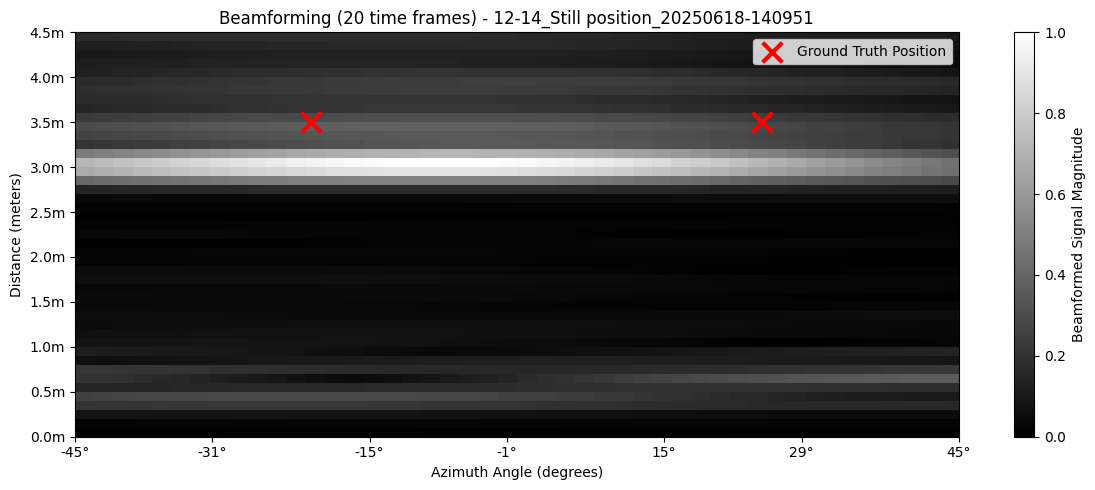


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['12', '14']

--- Blob analysis complete ---
  '12' detected in 3 windows, starting at frames: [250, 500, 510]
  '14' detected in 3 windows, starting at frames: [50, 250, 1160]

--- Summary of detected blobs (GTs = ['12', '14']) ---
  '12' was detected in 3 windows.
  '14' was detected in 3 windows.


{'12': [250, 500, 510], '14': [50, 250, 1160]}

In [16]:
base_file_path = "/kaggle/input/haeeai-project-uwb/SR250Mate/12-14_Still position_20250618-140951_sr250_rx0.npy"
extract_best_blobs(base_file_path)

## Process all the files in the SR250Mate directory

Starting to process all SR250Mate files for aggregated blob detection...

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/13-14_Still position_20250618-141413_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/13-14_Still position_20250618-141413_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for visualization (first 20 frames)...
Generating Beamformed plot...



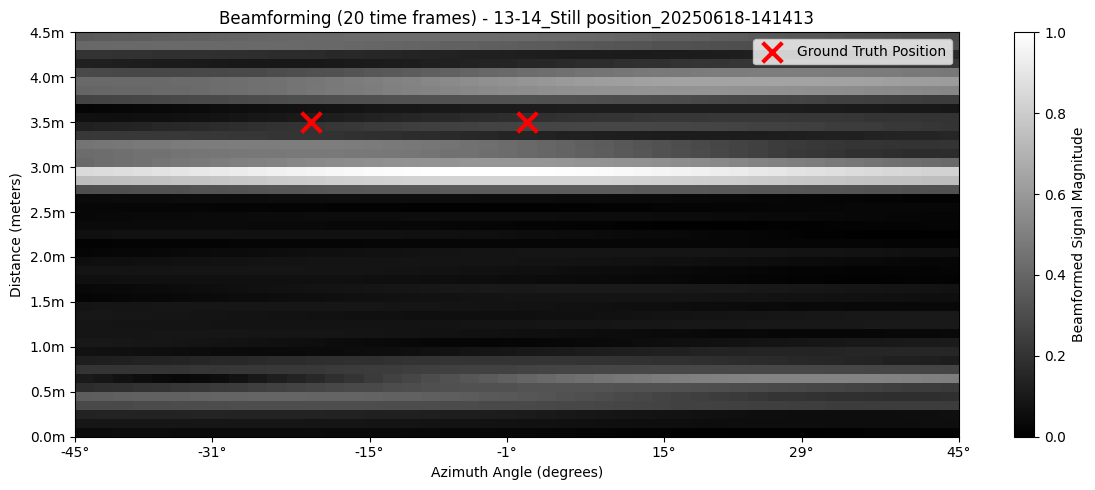


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['13', '14']

--- Blob analysis complete ---
  '13' not detected above threshold in any window.
  '14' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['13', '14']) ---
  '13' was NOT detected in any window above the threshold.
  '14' was NOT detected in any window above the threshold.

No blobs were detected above the threshold at the specified ground truth positions.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/7_Still position_20250618-114258_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/7_Still position_20250618-114258_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46

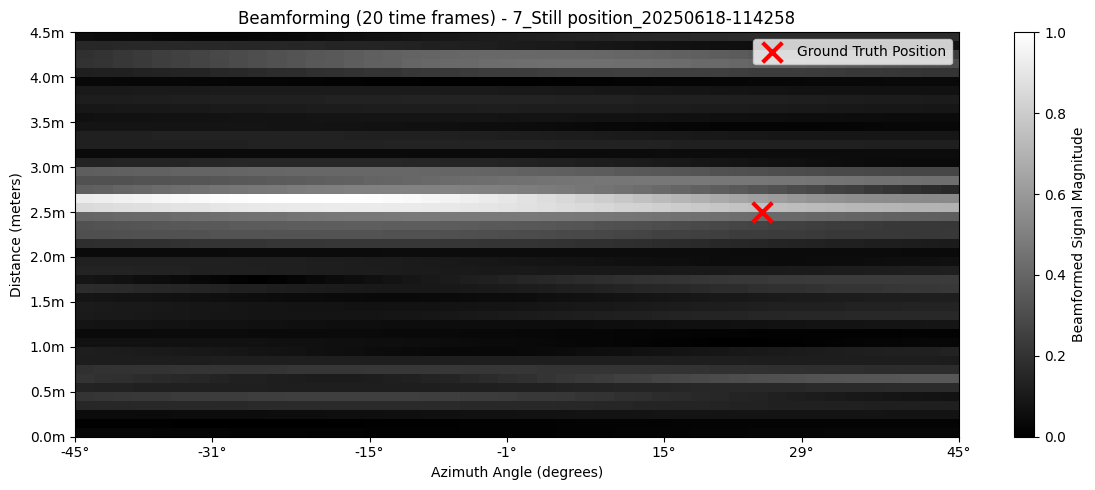


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['7']

--- Blob analysis complete ---
  '7' detected in 31 windows, starting at frames: [0, 40, 60, 80, 90, 220, 230, 240, 450, 460, 470, 510, 530, 540, 560, 780, 890, 900, 910, 920, 950, 970, 980, 990, 1000, 1020, 1030, 1040, 1050, 1160, 1180]

--- Summary of detected blobs (GTs = ['7']) ---
  '7' was detected in 31 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/3-13_Still position_20250618-142324_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/3-13_Still position_20250618-142324_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for visualization (f

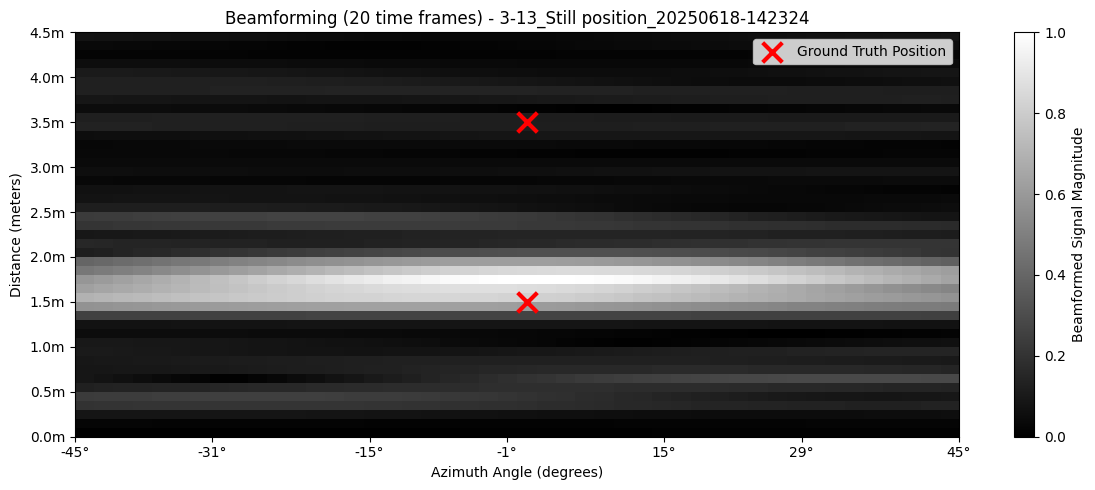


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '13']

--- Blob analysis complete ---
  '3' detected in 89 windows, starting at frames: [0, 80, 110, 130, 140, 150, 160, 180, 200, 210, 220, 230, 240, 250, 260, 270, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 660, 670, 680, 690, 700, 710, 720, 730, 750, 770, 780, 800, 810, 820, 840, 850, 860, 870, 880, 890, 900, 910, 930, 950, 970, 980, 990, 1000, 1010, 1030, 1040, 1050, 1070, 1090, 1110, 1160, 1170, 1180]
  '13' detected in 1 windows, starting at frames: [790]

--- Summary of detected blobs (GTs = ['3', '13']) ---
  '3' was detected in 89 windows.
  '13' was detected in 1 windows.

Processing file: /kaggle/input/haeeai-project-uwb/S

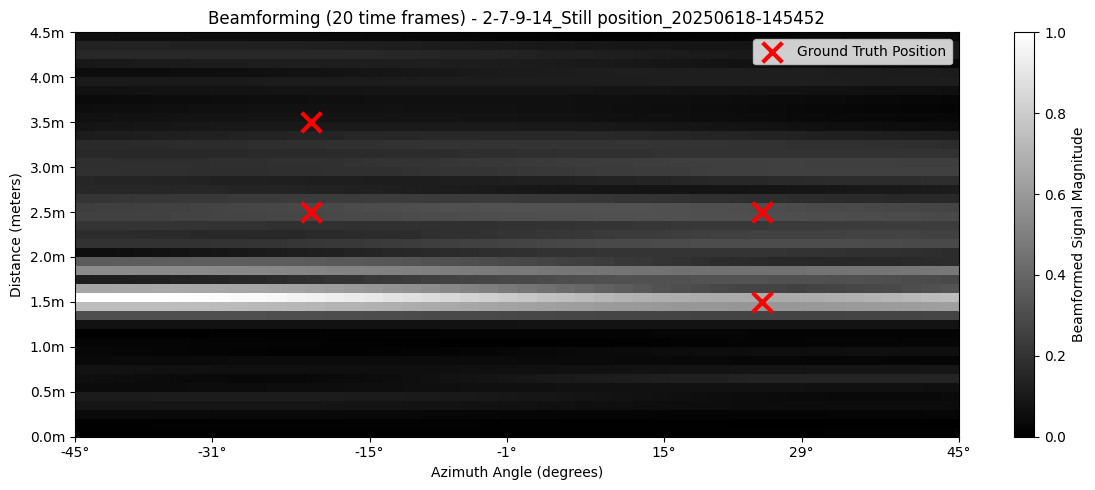


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '7', '9', '14']

--- Blob analysis complete ---
  '2' detected in 44 windows, starting at frames: [0, 30, 40, 60, 130, 150, 170, 190, 220, 240, 250, 270, 290, 360, 380, 390, 410, 420, 430, 440, 460, 530, 650, 660, 800, 820, 830, 840, 850, 860, 870, 880, 910, 940, 950, 970, 990, 1000, 1010, 1020, 1030, 1060, 1100, 1160]
  '7' not detected above threshold in any window.
  '9' detected in 1 windows, starting at frames: [280]
  '14' detected in 1 windows, starting at frames: [970]

--- Summary of detected blobs (GTs = ['2', '7', '9', '14']) ---
  '2' was detected in 44 windows.
  '7' was NOT detected in any window above the threshold.
  '9' was detected in 1 windows.
  '14' was detected in 1 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/2-4-9-

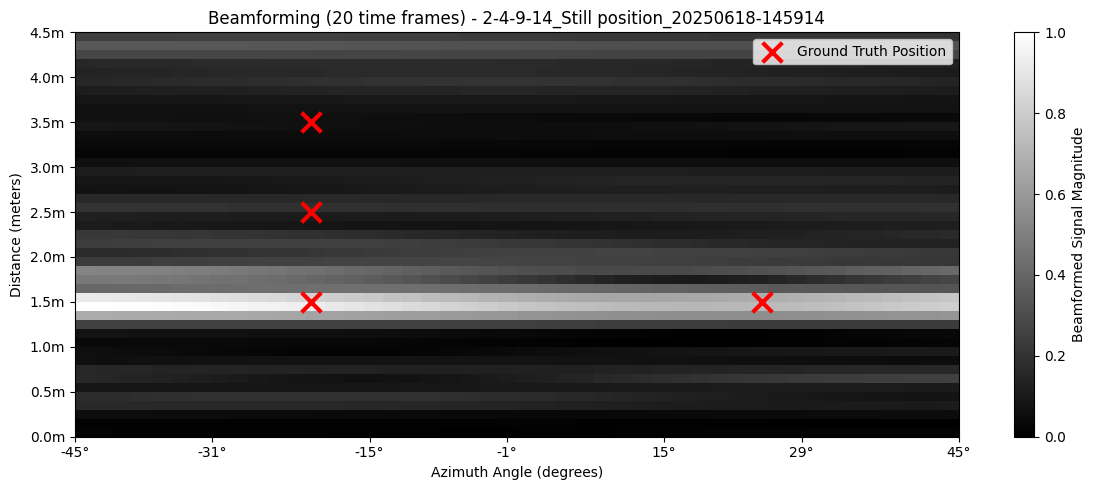


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '4', '9', '14']

--- Blob analysis complete ---
  '2' detected in 51 windows, starting at frames: [0, 10, 20, 40, 60, 90, 110, 160, 200, 210, 230, 240, 260, 270, 280, 290, 300, 310, 320, 340, 360, 400, 440, 470, 480, 490, 500, 510, 540, 550, 690, 710, 730, 740, 770, 790, 810, 910, 1010, 1030, 1050, 1060, 1080, 1090, 1110, 1120, 1140, 1150, 1160, 1170, 1180]
  '4' detected in 92 windows, starting at frames: [0, 10, 20, 40, 60, 90, 110, 130, 140, 150, 160, 170, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 360, 380, 390, 400, 410, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 590, 600, 610, 620, 630, 640, 650, 660, 670, 690, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 880,

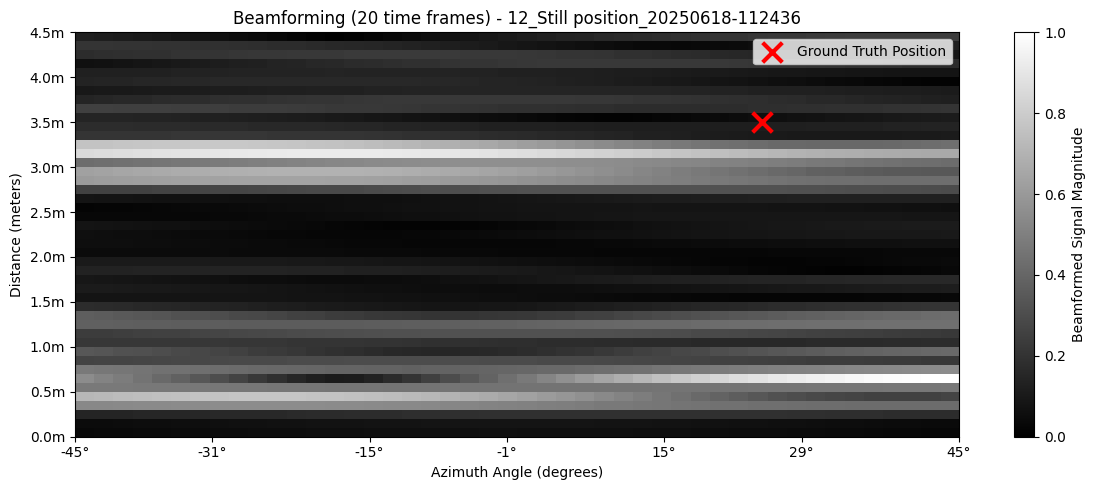


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['12']

--- Blob analysis complete ---
  '12' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['12']) ---
  '12' was NOT detected in any window above the threshold.

No blobs were detected above the threshold at the specified ground truth positions.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/2_Still position_20250618-114923_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/2_Still position_20250618-114923_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for visualization (first 20 frames)...
Generating Beamformed plot...



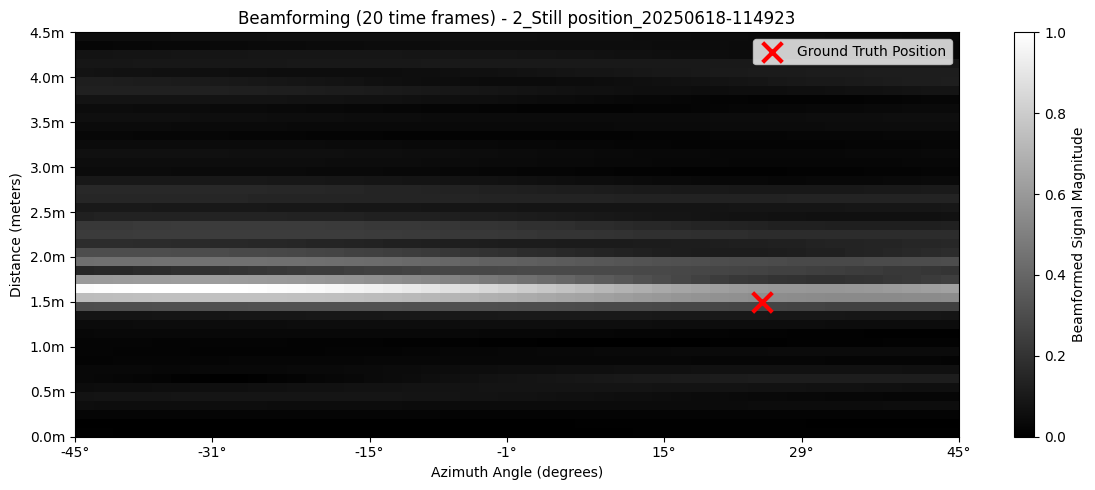


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2']

--- Blob analysis complete ---
  '2' detected in 96 windows, starting at frames: [20, 30, 40, 50, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 230, 250, 270, 280, 290, 300, 310, 320, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 480, 490, 500, 530, 550, 570, 590, 600, 610, 620, 630, 640, 650, 660, 670, 690, 700, 710, 730, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1020, 1030, 1050, 1060, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170]

--- Summary of detected blobs (GTs = ['2']) ---
  '2' was detected in 96 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/8-12_Still position_20250618-150939_sr250_rx0.npy
--- FILE

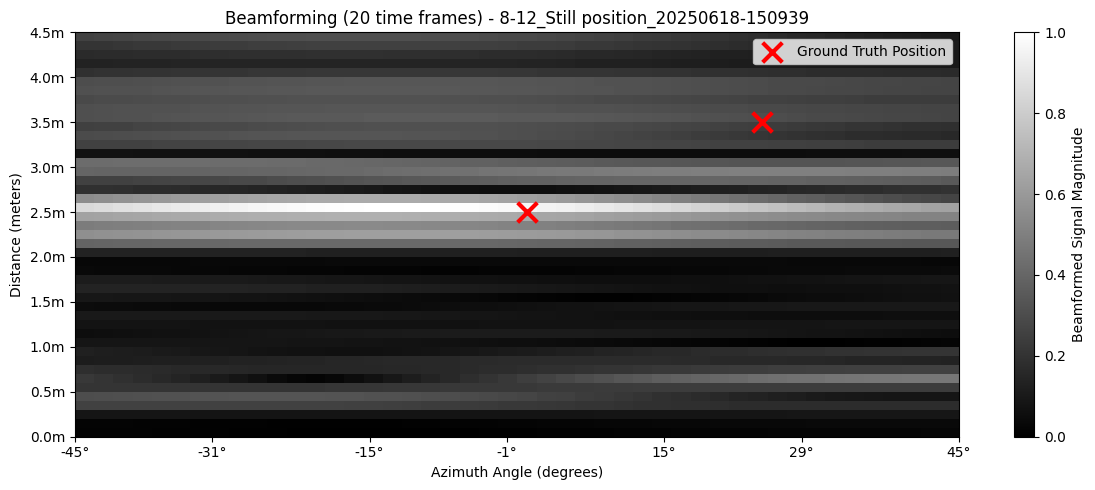


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['8', '12']

--- Blob analysis complete ---
  '8' detected in 83 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 210, 220, 230, 240, 250, 270, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 580, 600, 610, 620, 630, 640, 660, 670, 680, 700, 730, 740, 750, 760, 780, 840, 900, 910, 930, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1070, 1080, 1090, 1110, 1180]
  '12' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['8', '12']) ---
  '8' was detected in 83 windows.
  '12' was NOT detected in any window above the threshold.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/7-12_Still

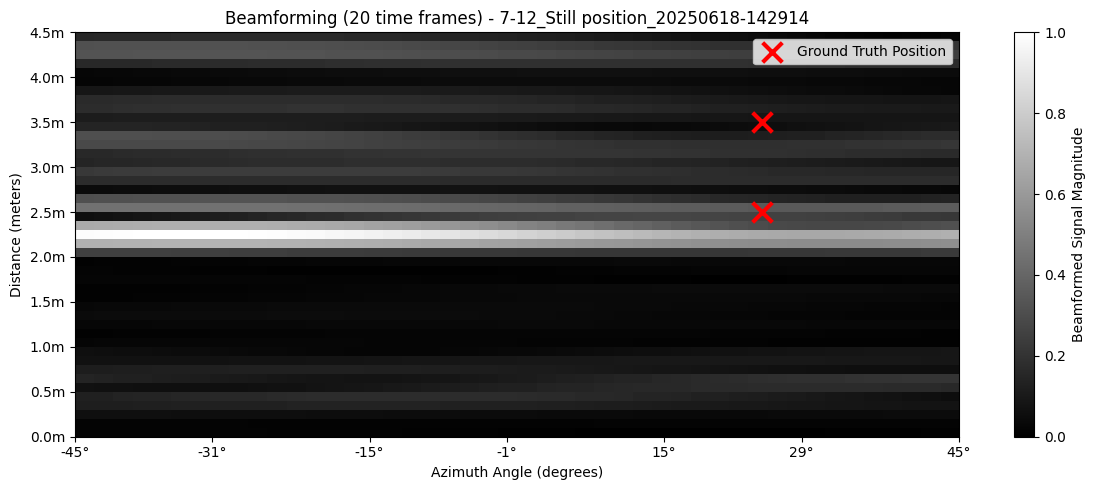


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['7', '12']

--- Blob analysis complete ---
  '7' detected in 19 windows, starting at frames: [10, 170, 190, 450, 470, 550, 820, 870, 880, 890, 900, 910, 990, 1110, 1120, 1130, 1150, 1160, 1180]
  '12' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['7', '12']) ---
  '7' was detected in 19 windows.
  '12' was NOT detected in any window above the threshold.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/2-4-12-14_Still position_20250618-144012_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/2-4-12-14_Still position_20250618-144012_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45

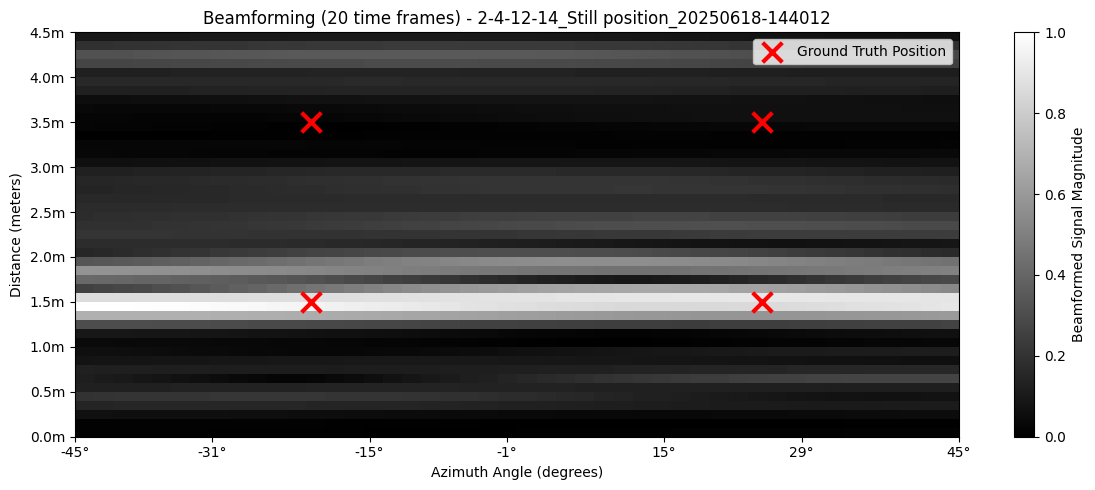


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '4', '12', '14']

--- Blob analysis complete ---
  '2' detected in 44 windows, starting at frames: [0, 10, 20, 30, 50, 70, 80, 90, 110, 130, 220, 240, 260, 300, 310, 320, 330, 360, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 550, 560, 570, 580, 590, 600, 620, 680, 1010, 1020, 1090, 1110, 1120, 1130, 1170]
  '4' detected in 95 windows, starting at frames: [0, 10, 20, 40, 50, 60, 70, 80, 90, 110, 130, 160, 200, 220, 230, 240, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 410, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 550, 560, 570, 580, 590, 600, 620, 630, 640, 650, 660, 670, 680, 690, 710, 720, 730, 740, 750, 760, 790, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 1000, 1010, 1040, 1

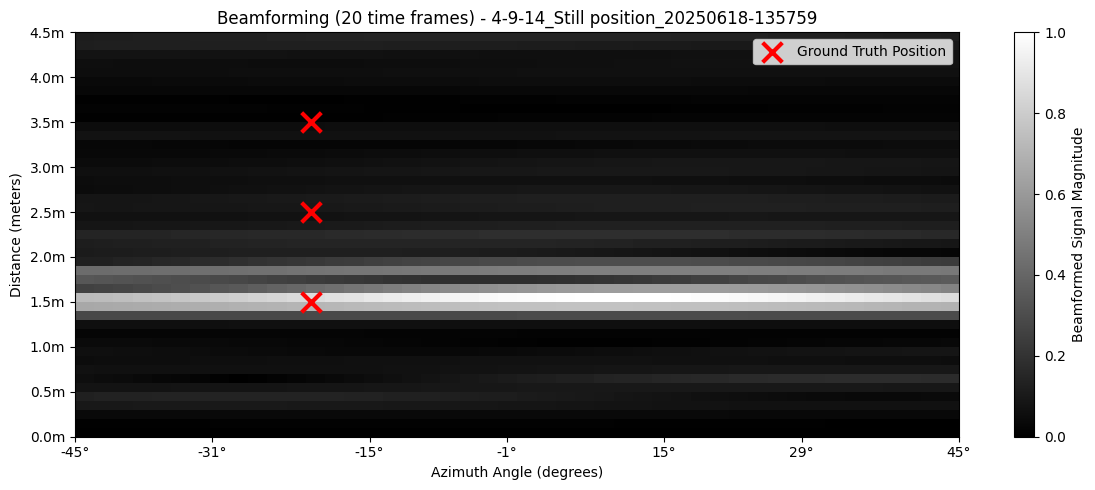


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '9', '14']

--- Blob analysis complete ---
  '4' detected in 114 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 530, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]
  '9' not detected above threshold in any window.
  '14' not detected above threshold in any window.



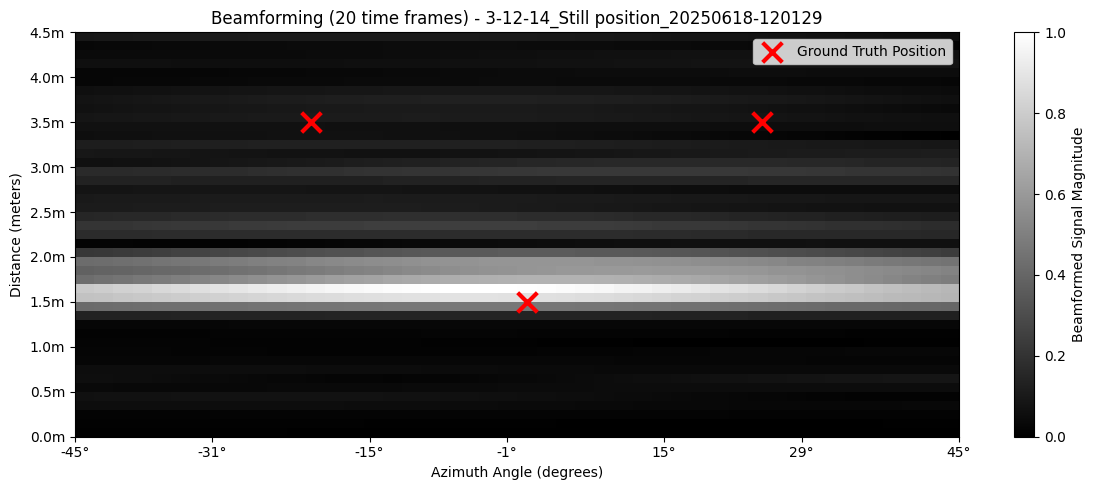


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '12', '14']

--- Blob analysis complete ---
  '3' detected in 69 windows, starting at frames: [0, 20, 30, 40, 70, 80, 90, 100, 110, 120, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 250, 270, 290, 300, 320, 340, 370, 380, 390, 400, 410, 430, 460, 470, 480, 490, 500, 510, 520, 540, 550, 570, 580, 640, 670, 710, 720, 730, 740, 750, 770, 800, 810, 820, 830, 850, 890, 900, 910, 960, 980, 1020, 1040, 1090, 1140, 1150, 1160, 1170, 1180]
  '12' not detected above threshold in any window.
  '14' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['3', '12', '14']) ---
  '3' was detected in 69 windows.
  '12' was NOT detected in any window above the threshold.
  '14' was NOT detected in any window above the threshold.

Processing file: 

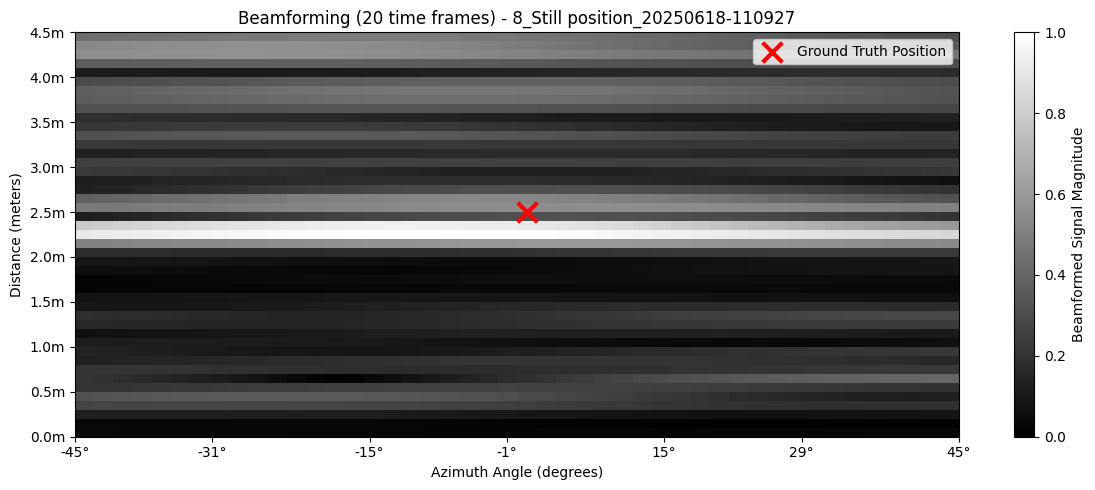


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['8']

--- Blob analysis complete ---
  '8' detected in 64 windows, starting at frames: [0, 20, 40, 60, 80, 100, 110, 120, 130, 140, 170, 180, 200, 210, 220, 230, 270, 300, 310, 320, 330, 350, 360, 370, 390, 420, 460, 490, 500, 510, 520, 530, 540, 580, 620, 630, 640, 650, 660, 670, 680, 690, 700, 720, 730, 750, 760, 770, 790, 800, 810, 860, 880, 940, 1010, 1020, 1030, 1040, 1060, 1120, 1130, 1140, 1150, 1160]

--- Summary of detected blobs (GTs = ['8']) ---
  '8' was detected in 64 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/7_Still position_(250,45)_20250618-105902_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/7_Still position_(250,45)_20250618-105902_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype co

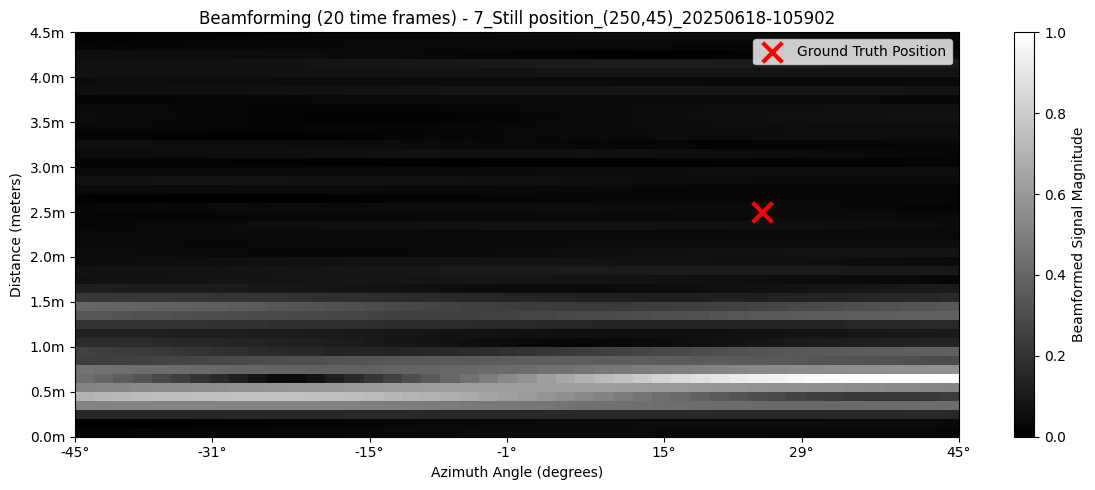


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['7']

--- Blob analysis complete ---
  '7' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['7']) ---
  '7' was NOT detected in any window above the threshold.

No blobs were detected above the threshold at the specified ground truth positions.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/7-8_Still position_20250618-141728_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/7-8_Still position_20250618-141728_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for visualization (first 20 frames)...
Generating Beamformed plot...



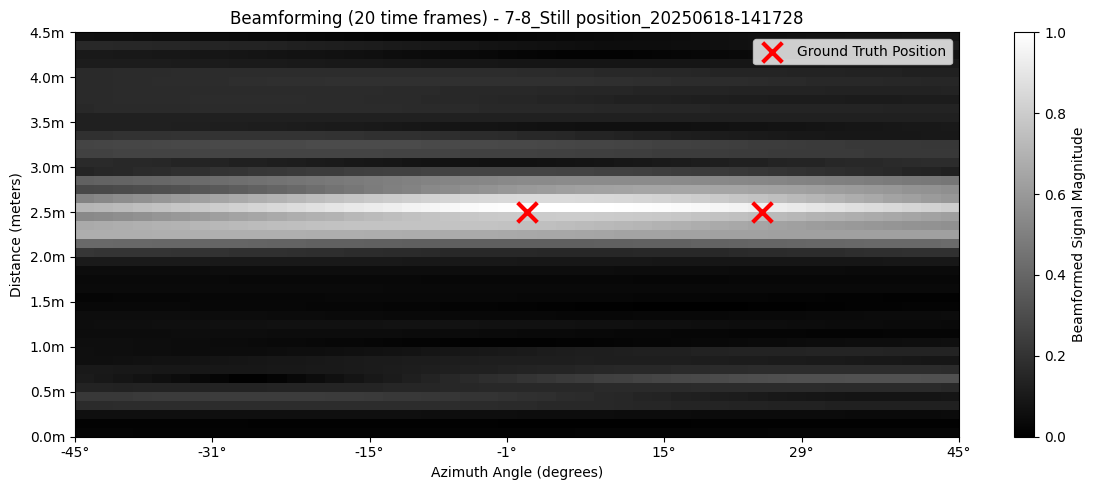


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['7', '8']

--- Blob analysis complete ---
  '7' detected in 40 windows, starting at frames: [0, 20, 30, 40, 50, 110, 140, 190, 220, 240, 270, 380, 430, 460, 470, 490, 500, 520, 540, 560, 610, 630, 730, 740, 790, 800, 810, 910, 930, 1050, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170]
  '8' detected in 54 windows, starting at frames: [0, 10, 20, 30, 40, 50, 110, 120, 140, 150, 190, 200, 210, 220, 230, 240, 270, 380, 400, 430, 440, 460, 490, 500, 510, 520, 540, 560, 610, 630, 730, 740, 790, 800, 810, 900, 910, 930, 970, 990, 1000, 1020, 1030, 1050, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170]

--- Summary of detected blobs (GTs = ['7', '8']) ---
  '7' was detected in 40 windows.
  '8' was detected in 54 windows.

Processing file: /kaggle/inpu

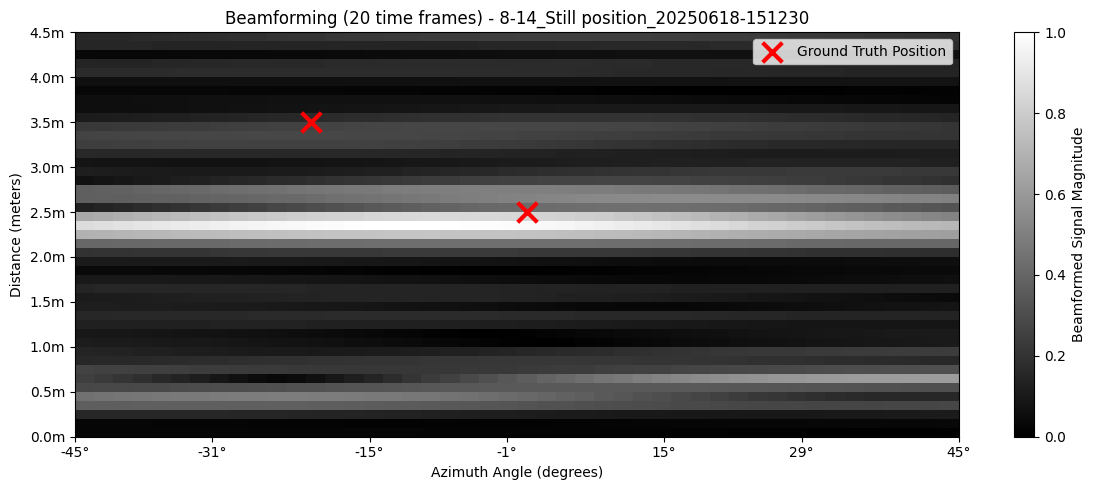


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['8', '14']

--- Blob analysis complete ---
  '8' detected in 43 windows, starting at frames: [40, 60, 70, 80, 100, 110, 120, 130, 160, 170, 190, 230, 250, 280, 300, 320, 360, 420, 450, 460, 470, 490, 570, 580, 590, 600, 700, 710, 720, 730, 740, 750, 760, 780, 790, 800, 810, 820, 850, 870, 950, 1000, 1060]
  '14' detected in 1 windows, starting at frames: [10]

--- Summary of detected blobs (GTs = ['8', '14']) ---
  '8' was detected in 43 windows.
  '14' was detected in 1 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/7_Still position_20250618-112028_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/7_Still position_20250618-112028_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete

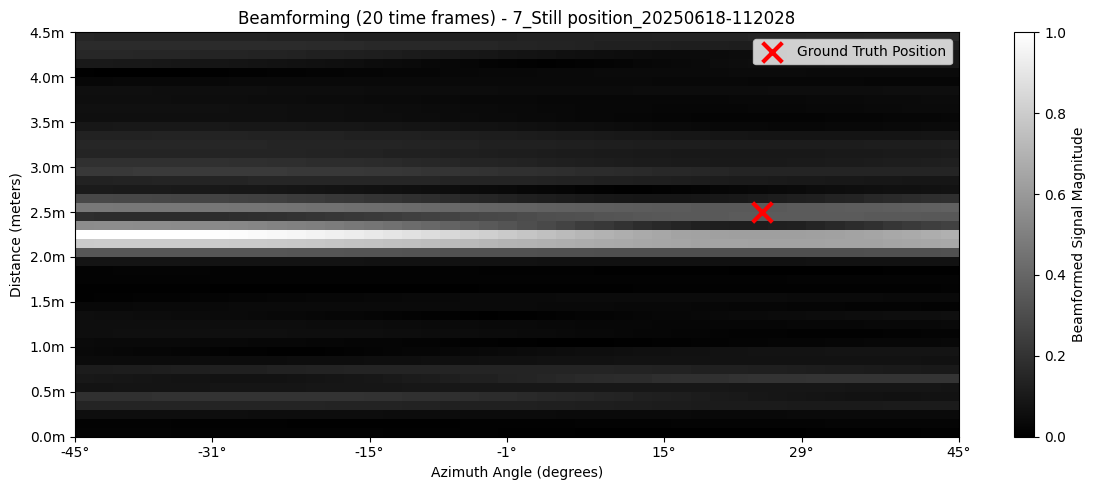


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['7']

--- Blob analysis complete ---
  '7' detected in 39 windows, starting at frames: [100, 120, 190, 290, 310, 320, 340, 350, 390, 410, 420, 430, 440, 480, 520, 540, 560, 580, 590, 610, 620, 650, 670, 790, 810, 820, 830, 850, 860, 890, 910, 930, 940, 960, 970, 1010, 1090, 1100, 1180]

--- Summary of detected blobs (GTs = ['7']) ---
  '7' was detected in 39 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/3-9-7-13_Still position_20250618-144439_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/3-9-7-13_Still position_20250618-144439_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex1

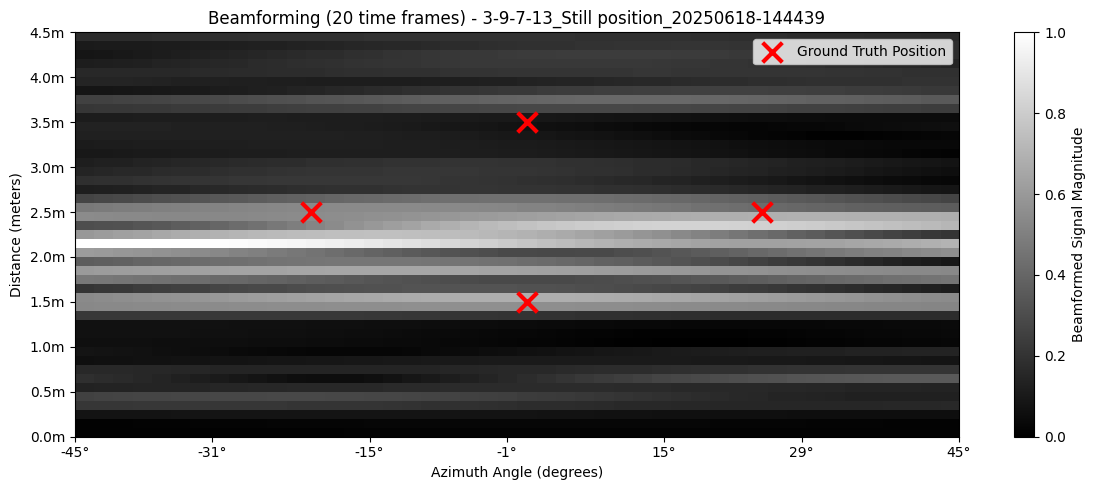


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '9', '7', '13']

--- Blob analysis complete ---
  '3' detected in 95 windows, starting at frames: [10, 30, 50, 60, 70, 140, 160, 170, 180, 190, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 360, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 500, 510, 520, 530, 550, 560, 570, 580, 590, 600, 610, 640, 650, 690, 700, 710, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1140, 1150, 1160, 1170, 1180]
  '9' detected in 6 windows, starting at frames: [120, 340, 480, 630, 690, 720]
  '7' detected in 1 windows, starting at frames: [130]
  '13' not detected above threshold in any window.


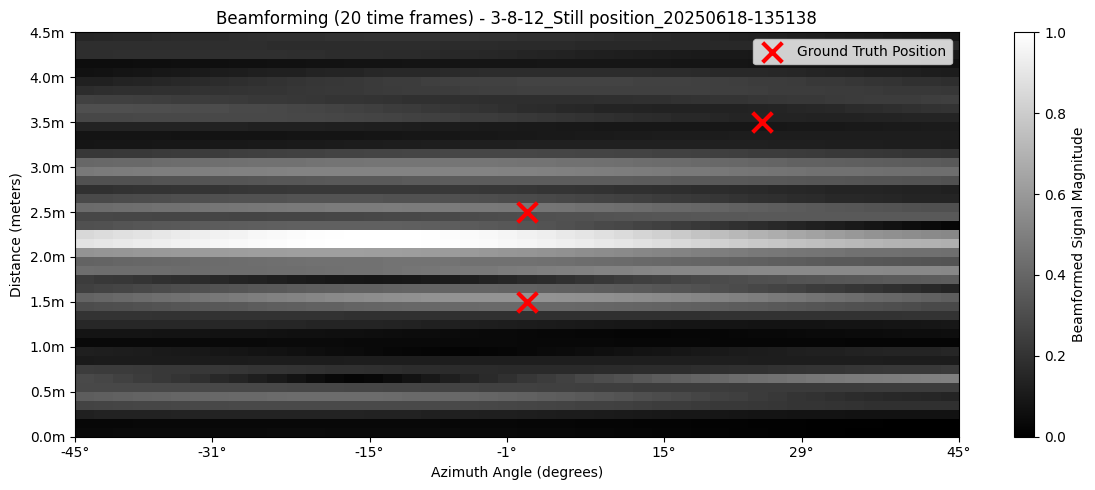


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '8', '12']

--- Blob analysis complete ---
  '3' detected in 99 windows, starting at frames: [10, 30, 40, 50, 60, 70, 80, 90, 100, 110, 160, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 350, 410, 420, 430, 440, 460, 470, 480, 490, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 710, 720, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]
  '8' detected in 1 windows, starting at frames: [640]
  '12' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['3', '8', '12']) ---
  '3' wa

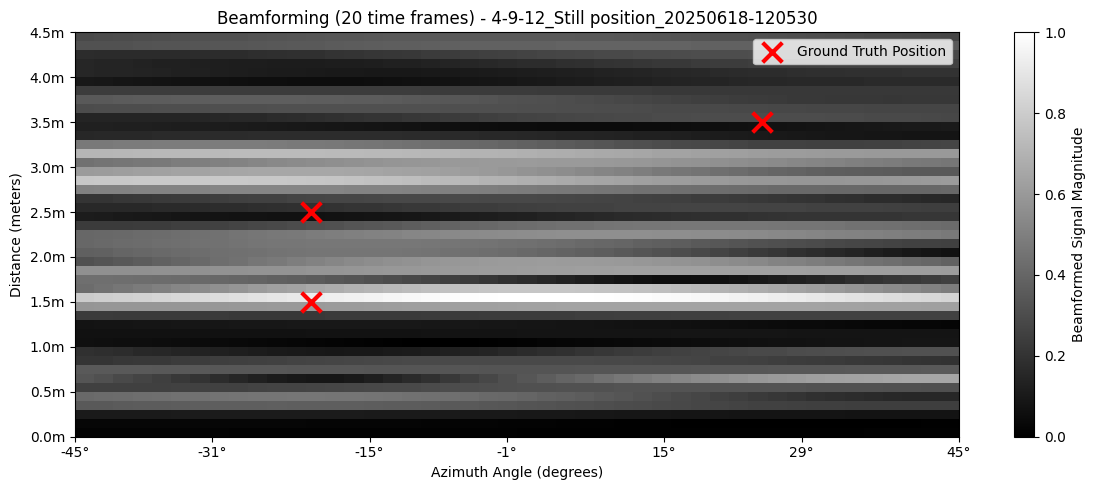


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '9', '12']

--- Blob analysis complete ---
  '4' detected in 109 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 560, 590, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 890, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]
  '9' not detected above threshold in any window.
  '12' not detected above threshold in any window.

--- Summary of detected

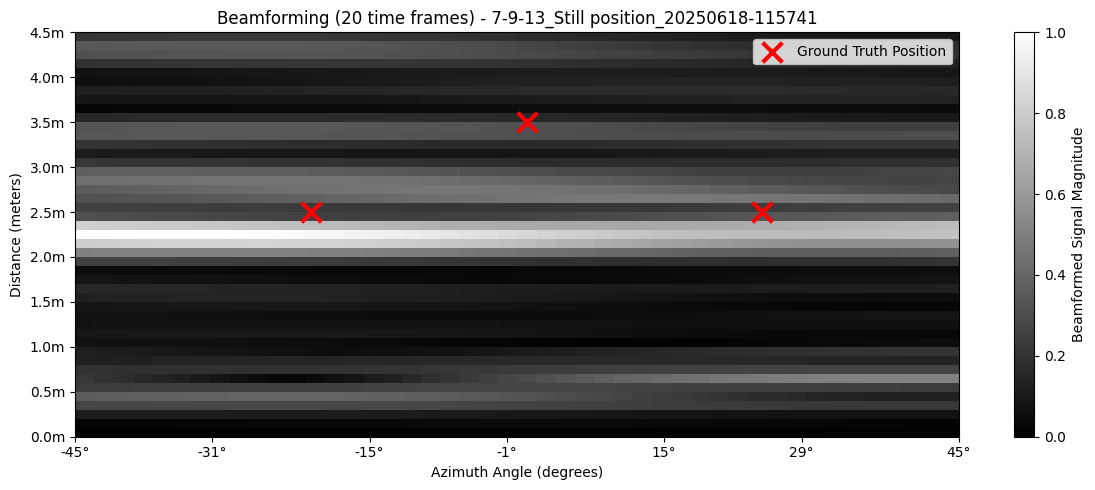


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['7', '9', '13']

--- Blob analysis complete ---
  '7' detected in 37 windows, starting at frames: [30, 50, 60, 80, 100, 130, 140, 160, 180, 200, 330, 490, 500, 510, 530, 550, 560, 570, 590, 670, 680, 690, 720, 830, 840, 870, 880, 890, 910, 920, 930, 940, 960, 1120, 1130, 1140, 1160]
  '9' detected in 58 windows, starting at frames: [30, 40, 50, 60, 70, 80, 90, 100, 120, 130, 140, 160, 180, 200, 250, 270, 330, 420, 430, 440, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 590, 610, 630, 640, 670, 680, 690, 700, 720, 730, 740, 830, 840, 870, 880, 900, 910, 920, 930, 940, 960, 1030, 1050, 1060, 1100, 1120, 1130, 1140]
  '13' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['7', '9', '13']) ---
  '7' was detected in 37 windows.
  '9' wa

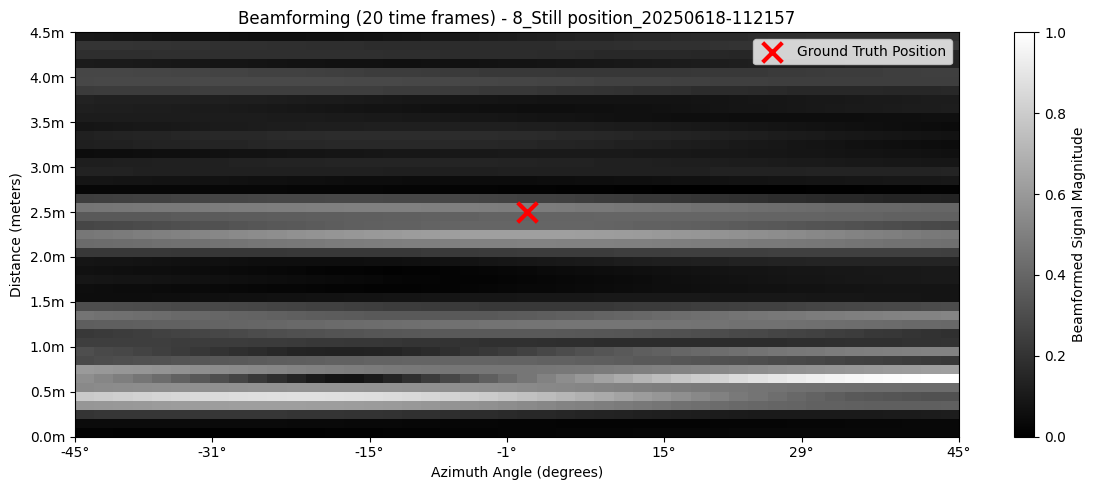


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['8']

--- Blob analysis complete ---
  '8' detected in 83 windows, starting at frames: [20, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 180, 190, 200, 220, 250, 260, 270, 280, 310, 320, 340, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 480, 490, 510, 520, 530, 540, 560, 580, 590, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 800, 810, 820, 830, 860, 870, 880, 890, 900, 910, 920, 930, 970, 1010, 1060, 1070, 1080, 1140, 1150, 1160, 1180]

--- Summary of detected blobs (GTs = ['8']) ---
  '8' was detected in 83 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/3-8-14_Still position_20250618-135318_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/3-8-14_Still position

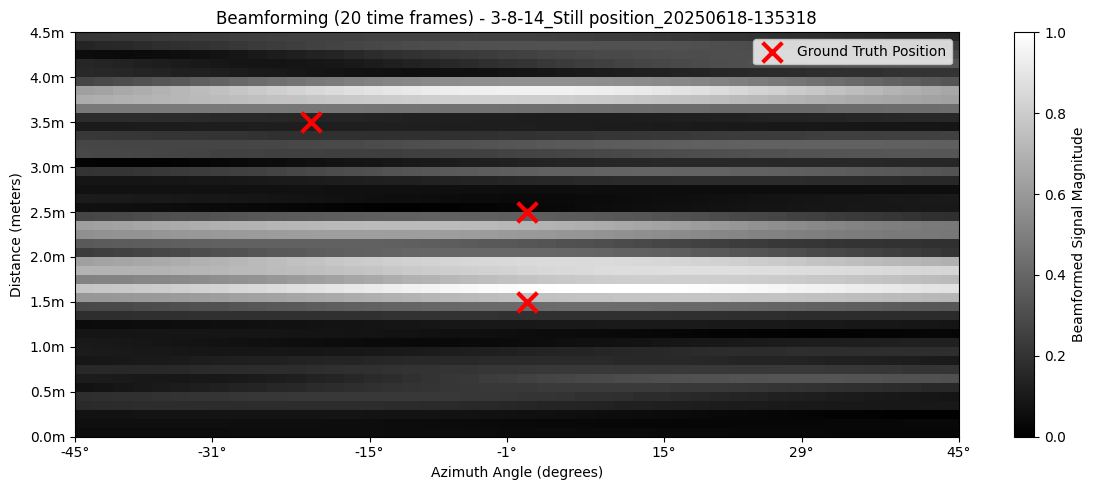


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '8', '14']

--- Blob analysis complete ---
  '3' detected in 107 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 170, 180, 190, 200, 210, 220, 240, 260, 270, 280, 290, 300, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 470, 480, 490, 500, 510, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]
  '8' not detected above threshold in any window.
  '14' detected in 1 windows, starting at frames: [860]

--- Summary of detected blobs

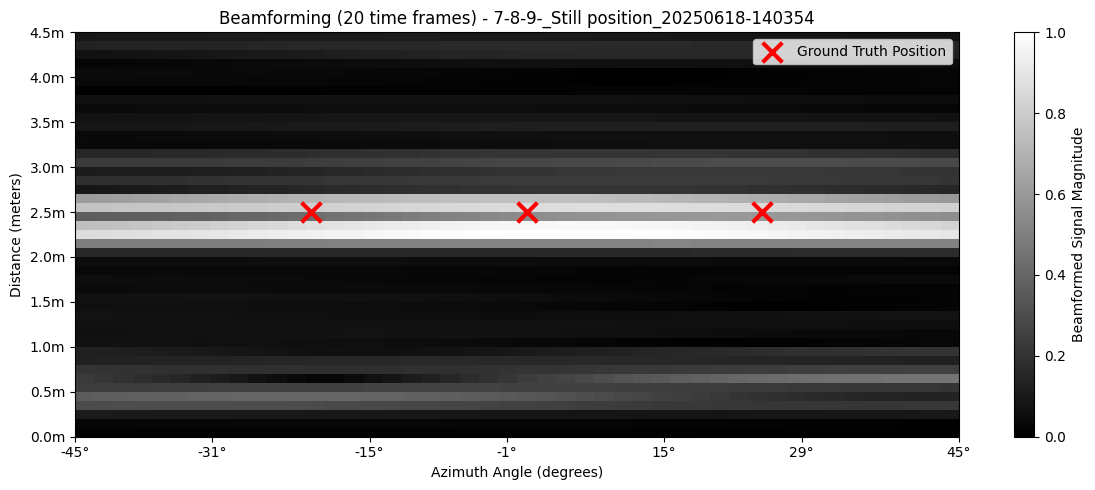


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['7', '8', '9']

--- Blob analysis complete ---
  '7' detected in 58 windows, starting at frames: [0, 10, 30, 60, 70, 80, 90, 100, 110, 130, 170, 190, 220, 230, 240, 260, 290, 300, 310, 320, 380, 390, 400, 410, 420, 430, 460, 530, 540, 560, 590, 610, 620, 660, 680, 700, 720, 730, 790, 810, 830, 840, 850, 860, 870, 880, 890, 930, 940, 950, 960, 970, 1000, 1040, 1130, 1160, 1170, 1180]
  '8' detected in 65 windows, starting at frames: [0, 10, 70, 80, 90, 100, 110, 130, 170, 190, 220, 230, 240, 260, 290, 300, 310, 320, 330, 380, 390, 400, 410, 420, 430, 440, 460, 500, 520, 530, 540, 560, 590, 610, 620, 660, 680, 700, 720, 730, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 910, 930, 940, 950, 960, 970, 1000, 1030, 1040, 1130, 1160, 1170, 1180]
  '9' detected 

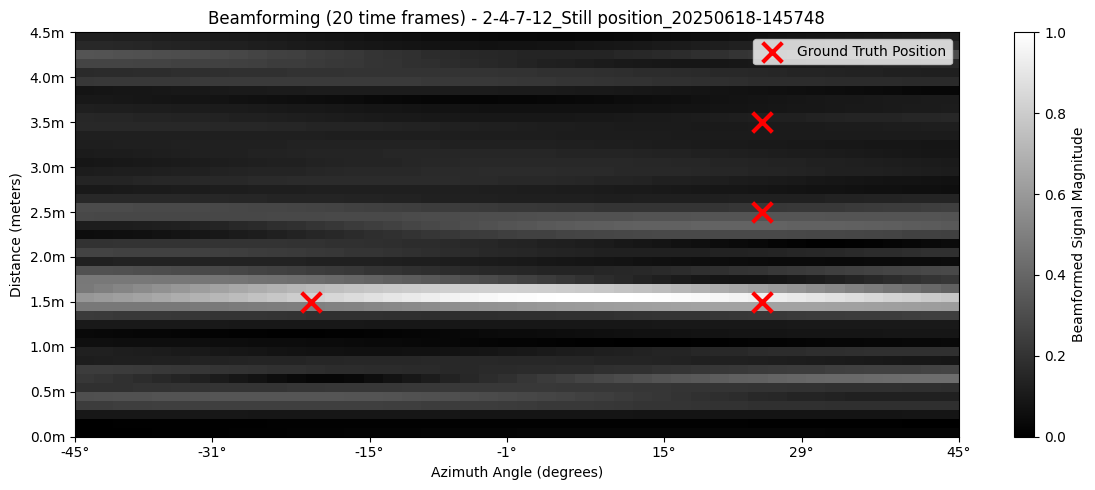


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '4', '7', '12']

--- Blob analysis complete ---
  '2' detected in 70 windows, starting at frames: [0, 10, 20, 30, 40, 60, 100, 130, 140, 150, 160, 180, 190, 210, 220, 230, 240, 250, 260, 280, 290, 300, 310, 330, 350, 360, 370, 380, 400, 410, 430, 450, 460, 470, 480, 500, 520, 530, 560, 570, 590, 610, 630, 640, 670, 680, 700, 710, 730, 740, 750, 760, 780, 790, 800, 820, 830, 850, 880, 890, 910, 930, 950, 960, 970, 1040, 1070, 1100, 1120, 1160]
  '4' detected in 96 windows, starting at frames: [0, 10, 20, 30, 50, 60, 70, 80, 90, 110, 120, 130, 140, 150, 160, 180, 200, 210, 220, 230, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 400, 410, 420, 430, 450, 460, 470, 480, 490, 500, 520, 530, 560, 570, 580, 590, 600, 610, 630, 640, 660, 670, 680, 

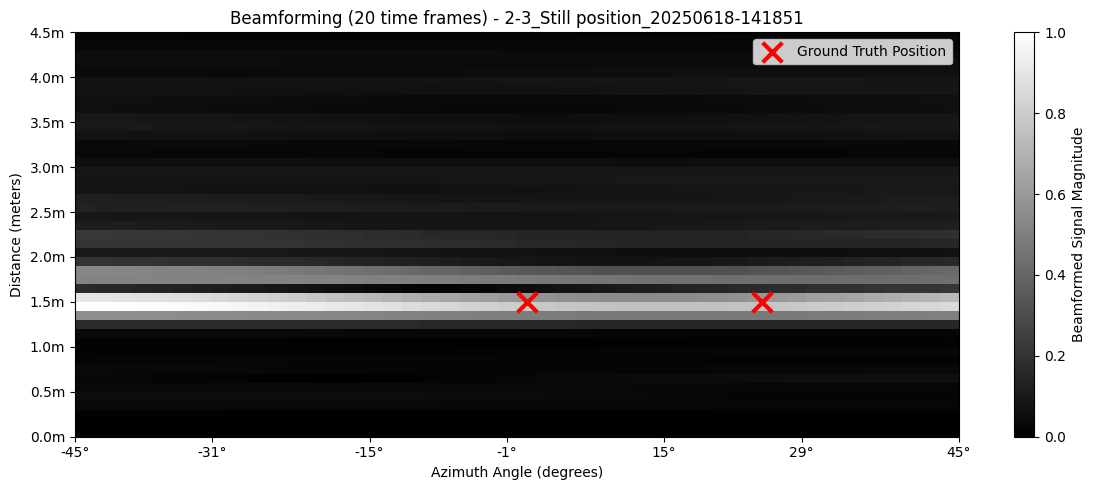


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '3']

--- Blob analysis complete ---
  '2' detected in 64 windows, starting at frames: [30, 100, 120, 130, 150, 160, 170, 230, 250, 280, 290, 300, 310, 320, 330, 340, 360, 380, 390, 450, 460, 470, 480, 490, 500, 510, 550, 560, 570, 580, 610, 620, 640, 650, 680, 710, 720, 730, 750, 770, 780, 790, 800, 810, 860, 870, 890, 910, 920, 930, 950, 960, 970, 980, 1000, 1070, 1090, 1110, 1120, 1140, 1150, 1160, 1170, 1180]
  '3' detected in 101 windows, starting at frames: [10, 20, 30, 40, 50, 60, 100, 120, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 360, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 550, 560, 570, 580, 590, 610, 620, 650, 660, 670, 680, 690, 700, 710, 720, 730, 750, 

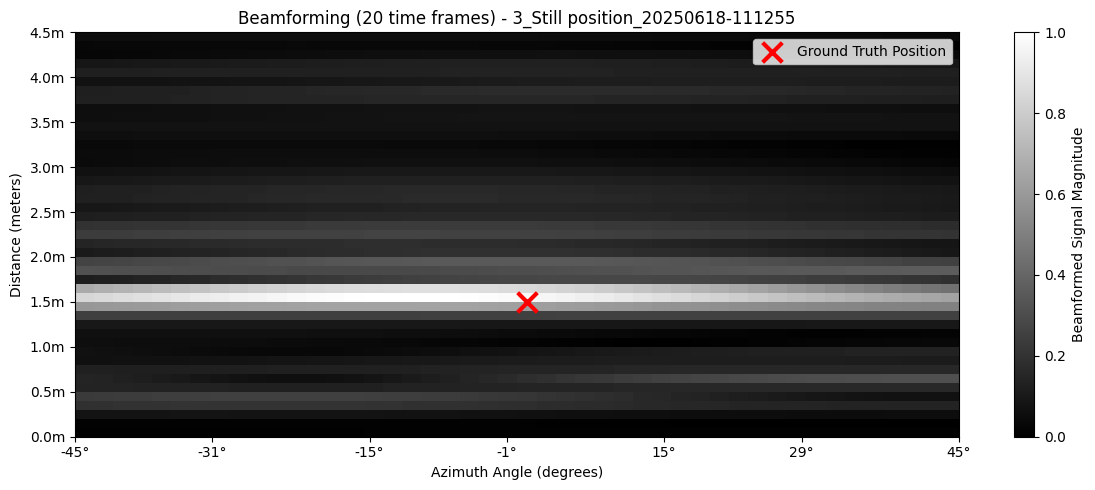


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3']

--- Blob analysis complete ---
  '3' detected in 110 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 470, 480, 490, 500, 510, 520, 530, 550, 560, 580, 590, 600, 610, 620, 640, 650, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170]

--- Summary of detected blobs (GTs = ['3']) ---
  '3' was detected in 110 windows.

Processing file: /kaggle/input/haeeai-project-u

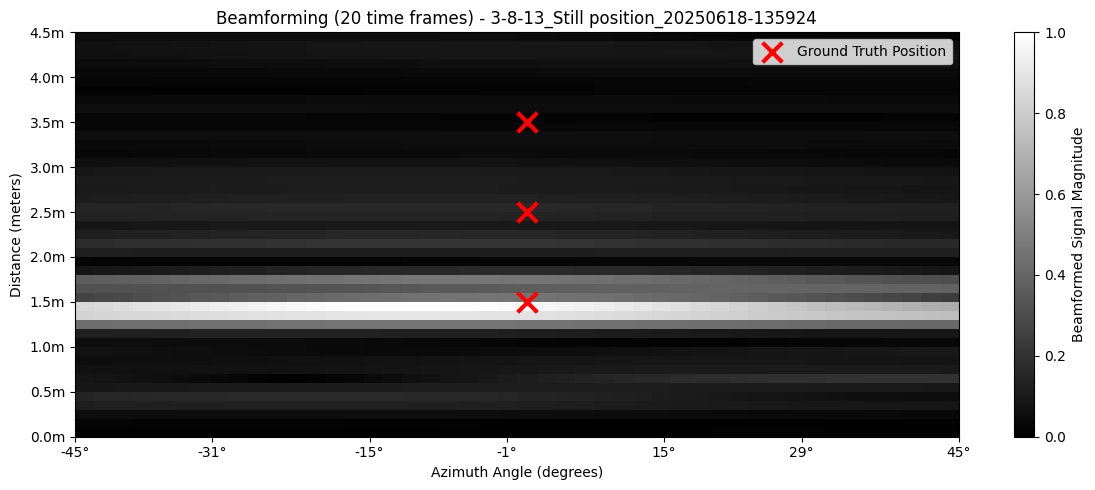


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '8', '13']

--- Blob analysis complete ---
  '3' detected in 85 windows, starting at frames: [10, 50, 70, 170, 280, 290, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 440, 450, 460, 480, 490, 500, 510, 540, 550, 560, 570, 580, 590, 600, 610, 630, 640, 650, 660, 670, 680, 690, 700, 710, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1180]
  '8' not detected above threshold in any window.
  '13' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['3', '8', '13']) ---
  '3' was detected in 85 windows.
  '8' was NOT detected in any window above th

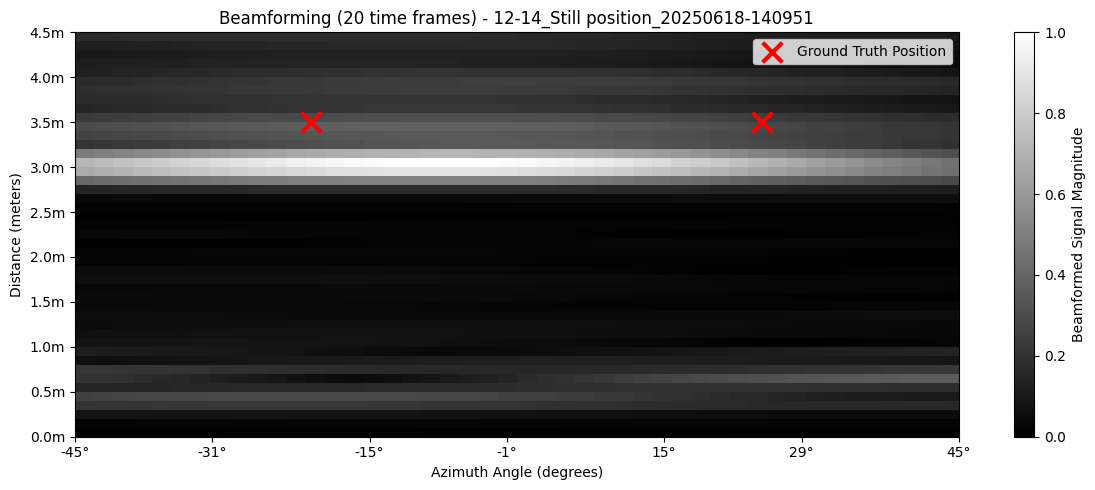


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['12', '14']

--- Blob analysis complete ---
  '12' detected in 3 windows, starting at frames: [250, 500, 510]
  '14' detected in 3 windows, starting at frames: [50, 250, 1160]

--- Summary of detected blobs (GTs = ['12', '14']) ---
  '12' was detected in 3 windows.
  '14' was detected in 3 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/3-4-12-13_Still position_20250618-144608_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/3-4-12-13_Still position_20250618-144608_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for visualization (first 20 frames)..

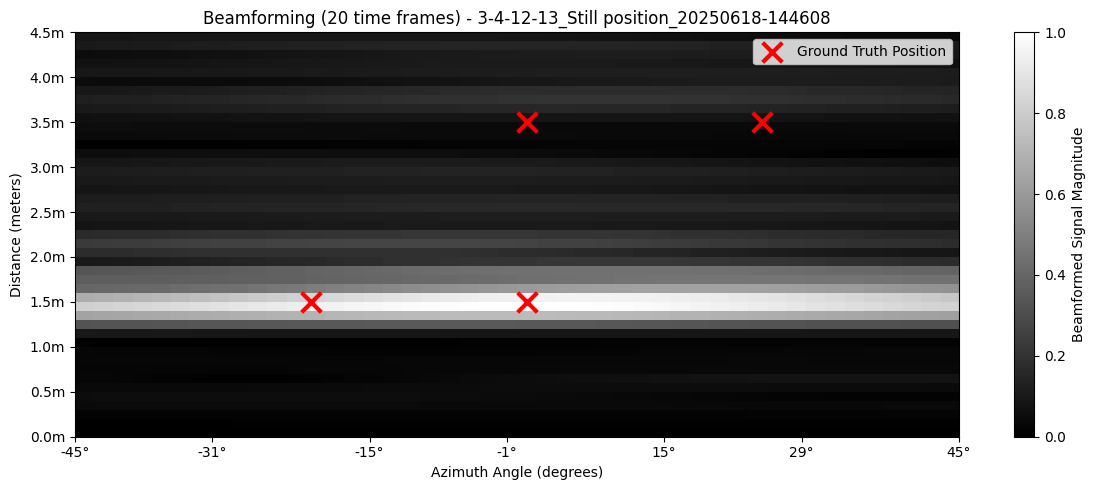


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '4', '12', '13']

--- Blob analysis complete ---
  '3' detected in 89 windows, starting at frames: [0, 10, 20, 30, 50, 60, 80, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 270, 280, 310, 320, 350, 360, 380, 390, 400, 410, 420, 430, 440, 450, 470, 480, 490, 510, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 640, 650, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 800, 810, 820, 830, 840, 850, 860, 870, 890, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1020, 1030, 1040, 1050, 1070, 1090, 1100, 1170]
  '4' detected in 87 windows, starting at frames: [0, 10, 20, 30, 50, 60, 70, 80, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 270, 280, 310, 320, 350, 360, 380, 390, 400, 410, 420, 430, 440, 470, 490, 

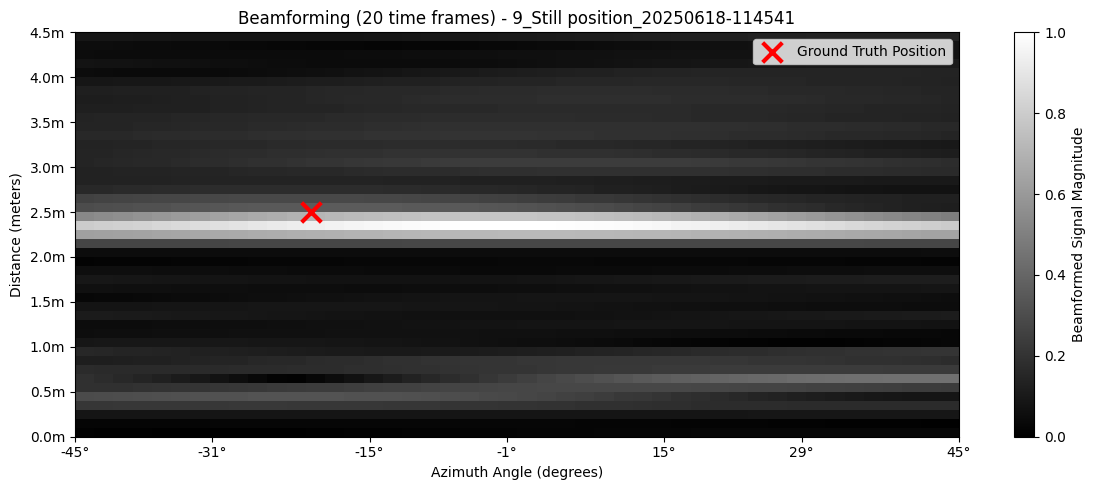


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['9']

--- Blob analysis complete ---
  '9' detected in 49 windows, starting at frames: [20, 70, 110, 120, 130, 140, 150, 160, 180, 220, 240, 250, 270, 280, 300, 400, 420, 430, 450, 460, 520, 530, 580, 590, 600, 620, 640, 650, 670, 720, 740, 750, 860, 930, 940, 950, 960, 970, 980, 990, 1010, 1040, 1050, 1080, 1090, 1110, 1120, 1140, 1170]

--- Summary of detected blobs (GTs = ['9']) ---
  '9' was detected in 49 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/4-2-14 _Still position_20250618-115434_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/4-2-14 _Still position_20250618-115434_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full 

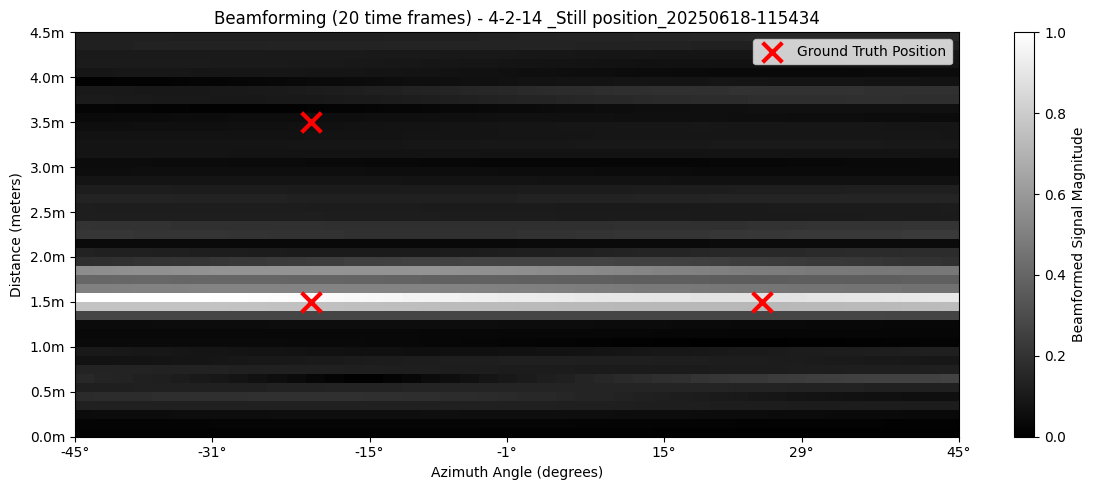


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '2', '14']

--- Blob analysis complete ---
  '4' detected in 102 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 330, 340, 350, 360, 370, 380, 400, 410, 420, 440, 450, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 610, 620, 650, 670, 690, 720, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1140, 1160, 1170]
  '2' detected in 77 windows, starting at frames: [0, 10, 20, 30, 40, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 180, 200, 230, 250, 260, 270, 280, 290, 30

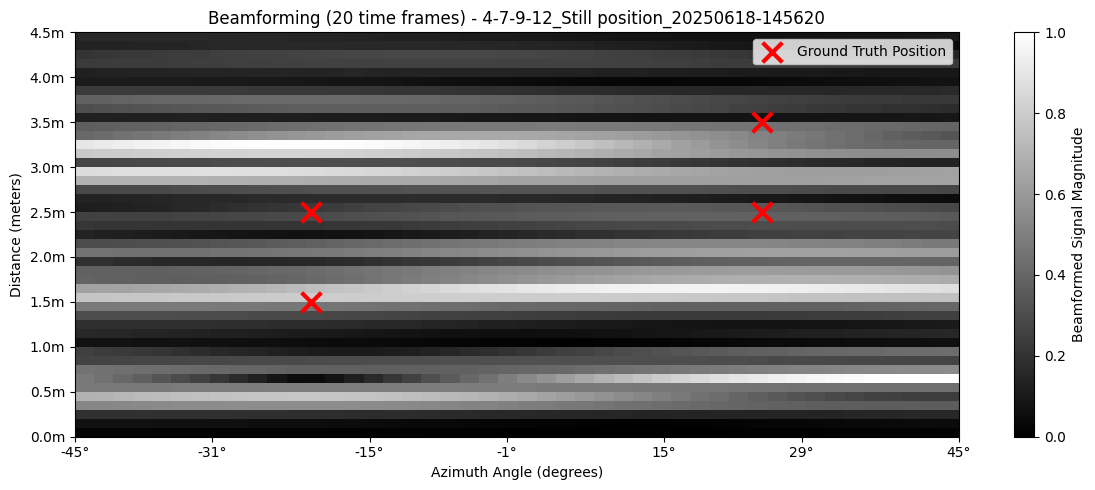


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '7', '9', '12']

--- Blob analysis complete ---
  '4' detected in 95 windows, starting at frames: [0, 20, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 310, 320, 330, 340, 410, 430, 450, 480, 490, 500, 510, 520, 530, 540, 560, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 920, 940, 950, 960, 970, 980, 990, 1000, 1020, 1030, 1050, 1060, 1080, 1090, 1100, 1120, 1140, 1160, 1170, 1180]
  '7' detected in 4 windows, starting at frames: [320, 560, 580, 1120]
  '9' detected in 14 windows, starting at frames: [390, 410, 460, 550, 560, 570, 580, 810, 830, 840, 850, 960, 1110, 1120]
 

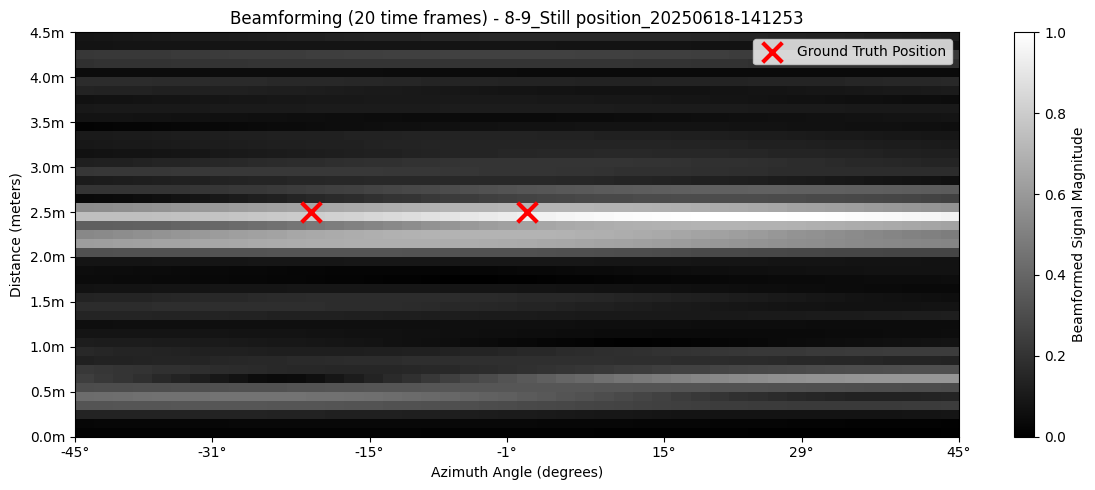


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['8', '9']

--- Blob analysis complete ---
  '8' detected in 35 windows, starting at frames: [0, 10, 30, 270, 330, 370, 390, 440, 460, 470, 530, 540, 550, 560, 570, 600, 630, 650, 670, 710, 780, 790, 800, 910, 920, 940, 980, 990, 1010, 1080, 1090, 1110, 1130, 1160, 1170]
  '9' detected in 31 windows, starting at frames: [0, 10, 30, 180, 270, 370, 420, 460, 530, 540, 550, 560, 570, 650, 670, 710, 780, 790, 800, 810, 910, 940, 980, 990, 1010, 1080, 1090, 1100, 1110, 1130, 1160]

--- Summary of detected blobs (GTs = ['8', '9']) ---
  '8' was detected in 35 windows.
  '9' was detected in 31 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/12-13-14_Still position_20250618-140232_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/12-1

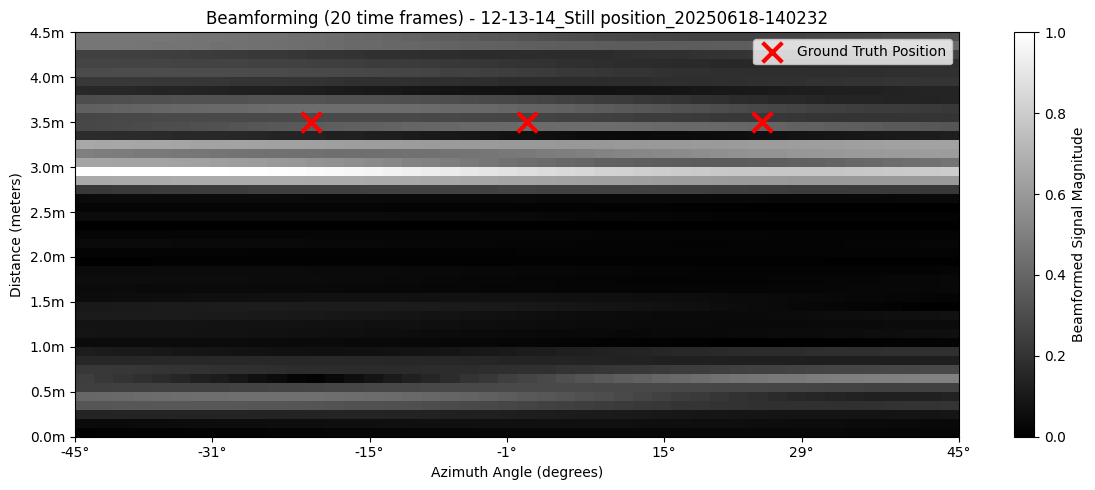


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['12', '13', '14']

--- Blob analysis complete ---
  '12' detected in 2 windows, starting at frames: [180, 850]
  '13' detected in 4 windows, starting at frames: [180, 410, 840, 850]
  '14' detected in 4 windows, starting at frames: [180, 410, 840, 850]

--- Summary of detected blobs (GTs = ['12', '13', '14']) ---
  '12' was detected in 2 windows.
  '13' was detected in 4 windows.
  '14' was detected in 4 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/4-9_Still position_20250618-143050_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/4-9_Still position_20250618-143050_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed dat

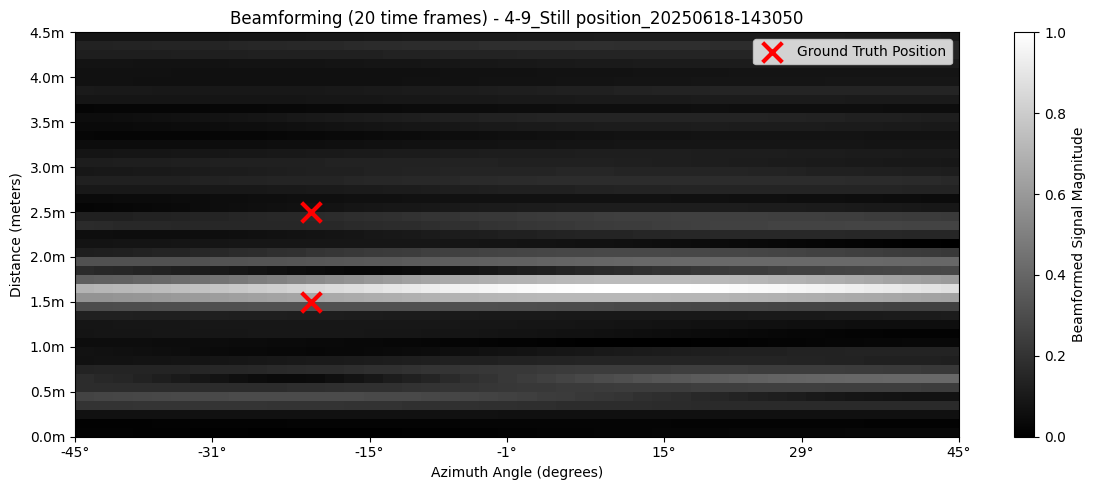


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '9']

--- Blob analysis complete ---
  '4' detected in 104 windows, starting at frames: [0, 10, 20, 30, 40, 50, 70, 80, 90, 100, 110, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 240, 250, 260, 270, 280, 290, 300, 310, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 560, 580, 590, 610, 630, 640, 650, 660, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 960, 970, 980, 990, 1000, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1130, 1150, 1160, 1170]
  '9' detected in 2 windows, starting at frames: [230, 620]

--- Summary of detected blobs (GTs = ['4', '9']) ---
  '4' was detected in 104 windows.
  '9' was 

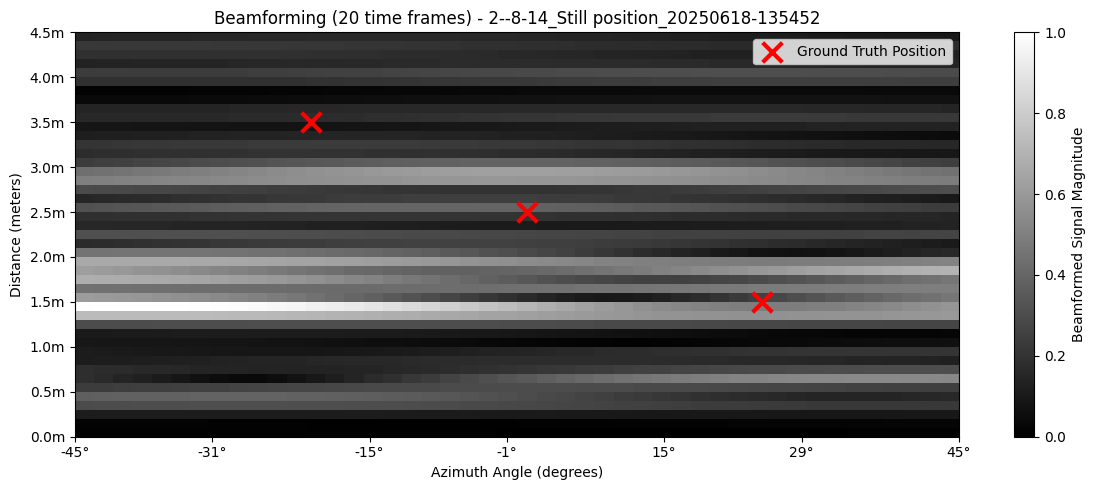


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '8', '14']

--- Blob analysis complete ---
  '2' detected in 14 windows, starting at frames: [60, 240, 380, 390, 400, 420, 460, 470, 490, 500, 540, 550, 1120, 1180]
  '8' detected in 21 windows, starting at frames: [10, 30, 80, 100, 130, 140, 150, 250, 440, 510, 540, 570, 620, 740, 750, 760, 810, 830, 840, 860, 970]
  '14' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['2', '8', '14']) ---
  '2' was detected in 14 windows.
  '8' was detected in 21 windows.
  '14' was NOT detected in any window above the threshold.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/12_Still position_20250618-114145_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/12_Still position_20250618-114145_sr250_rx0.npy ---

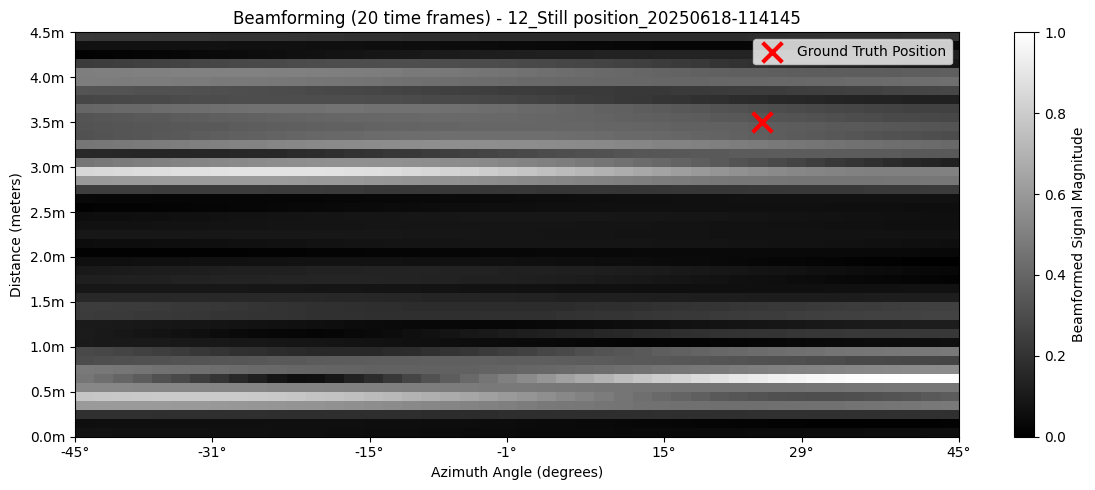


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['12']

--- Blob analysis complete ---
  '12' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['12']) ---
  '12' was NOT detected in any window above the threshold.

No blobs were detected above the threshold at the specified ground truth positions.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/4_Still position_20250618-114655_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/4_Still position_20250618-114655_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for visualization (first 20 frames)...
Generating Beamformed plot...



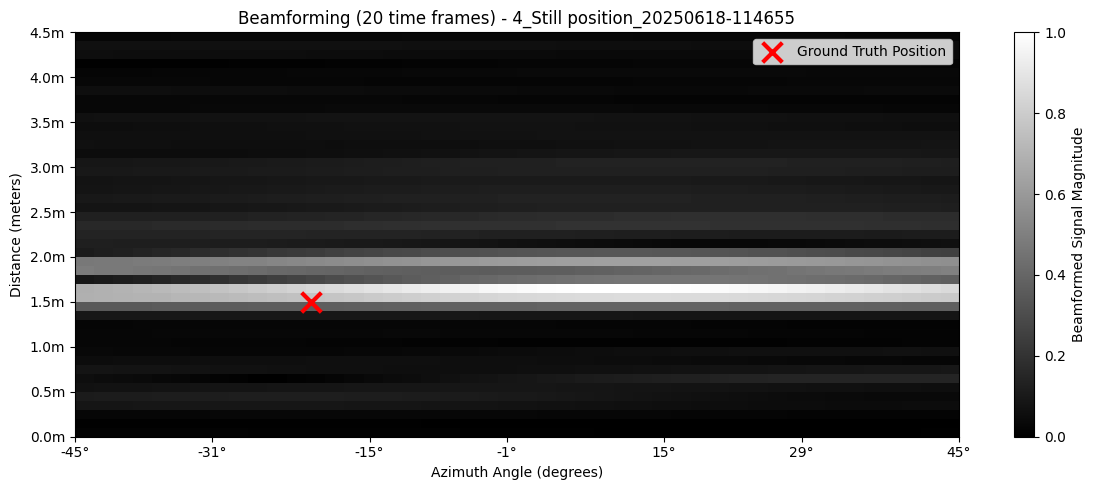


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4']

--- Blob analysis complete ---
  '4' detected in 36 windows, starting at frames: [0, 20, 30, 50, 90, 110, 120, 130, 150, 340, 350, 460, 480, 500, 510, 520, 530, 550, 600, 690, 730, 740, 750, 780, 800, 810, 840, 860, 870, 880, 890, 900, 990, 1070, 1140, 1170]

--- Summary of detected blobs (GTs = ['4']) ---
  '4' was detected in 36 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/14_Still position_20250618-112731_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/14_Still position_20250618-112731_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for

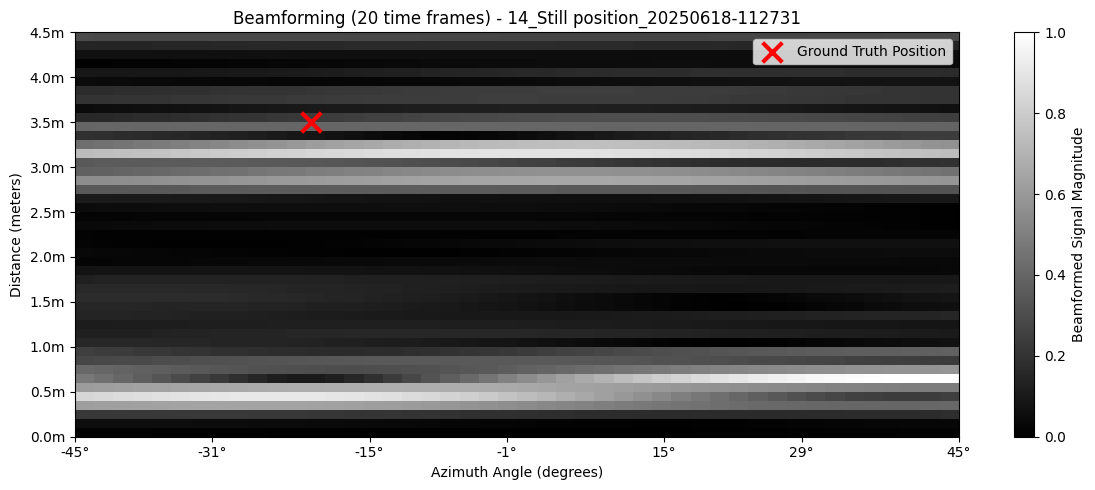


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['14']

--- Blob analysis complete ---
  '14' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['14']) ---
  '14' was NOT detected in any window above the threshold.

No blobs were detected above the threshold at the specified ground truth positions.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/2-12-14 _Still position_20250618-115119_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/2-12-14 _Still position_20250618-115119_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for visualization (first 20 frames)...
Generating Beamfo

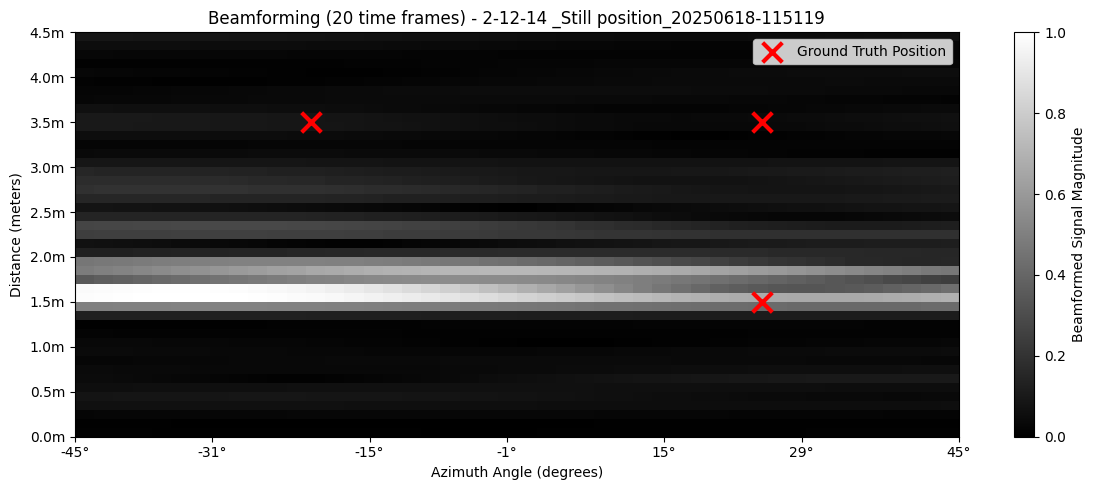


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '12', '14']

--- Blob analysis complete ---
  '2' detected in 69 windows, starting at frames: [0, 10, 20, 30, 50, 60, 70, 80, 150, 160, 180, 200, 210, 220, 230, 240, 250, 260, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 540, 550, 560, 580, 590, 640, 650, 660, 680, 690, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 910, 950]
  '12' not detected above threshold in any window.
  '14' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['2', '12', '14']) ---
  '2' was detected in 69 windows.
  '12' was NOT detected in any window above the threshold.
  '14' was NOT detected in any window above the threshold.

Processing file: /kaggle/i

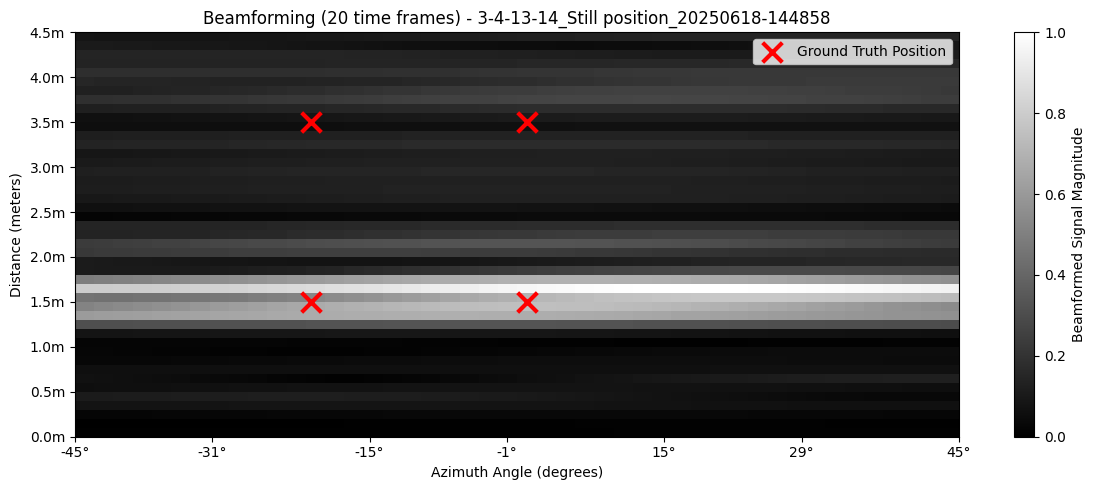


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '4', '13', '14']

--- Blob analysis complete ---
  '3' detected in 112 windows, starting at frames: [0, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 310, 320, 340, 350, 360, 370, 380, 390, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1130, 1140, 1150, 1160, 1170, 1180]
  '4' detected in 109 windows, starting at frames: [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 

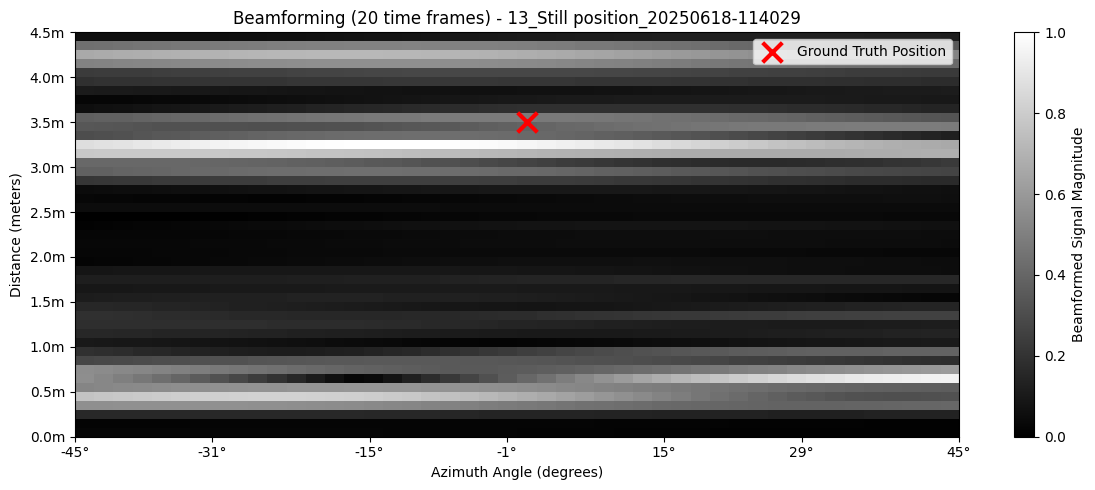


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['13']

--- Blob analysis complete ---
  '13' detected in 3 windows, starting at frames: [890, 970, 990]

--- Summary of detected blobs (GTs = ['13']) ---
  '13' was detected in 3 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/14-2_Still position_20250618-151512_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/14-2_Still position_20250618-151512_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for visualization (first 20 frames)...
Generating Beamformed plot...



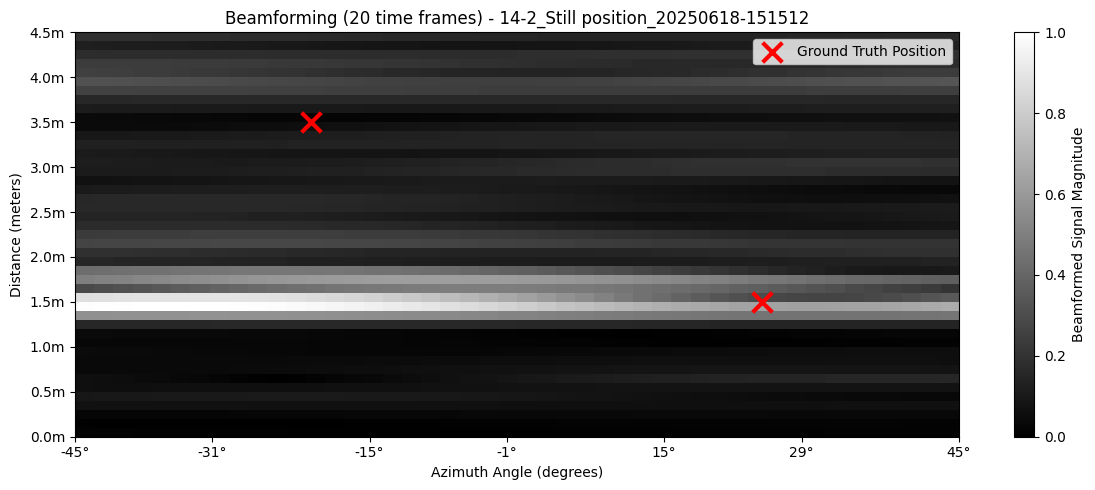


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['14', '2']

--- Blob analysis complete ---
  '14' not detected above threshold in any window.
  '2' detected in 73 windows, starting at frames: [30, 60, 80, 160, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 410, 420, 430, 440, 450, 460, 480, 490, 500, 510, 530, 540, 550, 560, 570, 580, 600, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 910, 920, 930, 940, 950, 960, 1070, 1080, 1100, 1110, 1120, 1130, 1150, 1160, 1170]

--- Summary of detected blobs (GTs = ['14', '2']) ---
  '14' was NOT detected in any window above the threshold.
  '2' was detected in 73 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/2-8_Still position_20250618-151109_sr250_rx0.npy
--- 

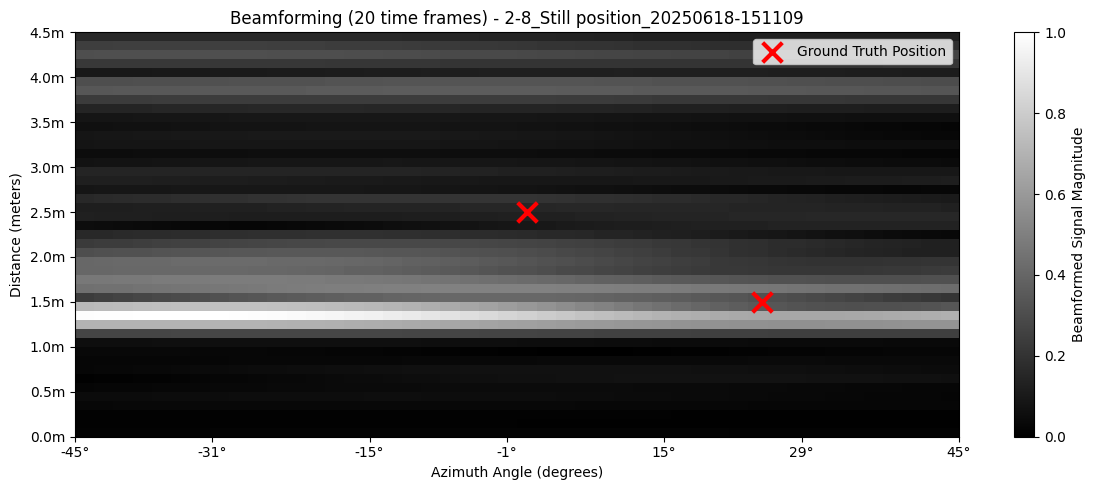


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '8']

--- Blob analysis complete ---
  '2' detected in 18 windows, starting at frames: [250, 260, 270, 330, 350, 470, 480, 520, 540, 600, 610, 630, 660, 680, 690, 820, 1010, 1030]
  '8' detected in 2 windows, starting at frames: [490, 620]

--- Summary of detected blobs (GTs = ['2', '8']) ---
  '2' was detected in 18 windows.
  '8' was detected in 2 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/4-8_Still position_20250618-143357_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/4-8_Still position_20250618-143357_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying co

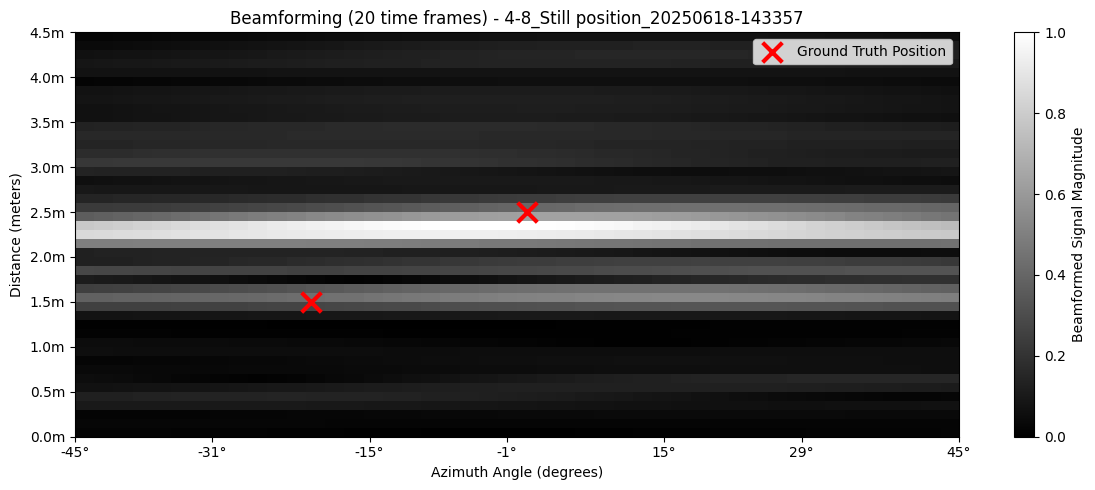


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '8']

--- Blob analysis complete ---
  '4' detected in 74 windows, starting at frames: [20, 30, 40, 50, 60, 80, 100, 110, 140, 160, 180, 190, 200, 210, 220, 230, 250, 260, 270, 280, 290, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 580, 590, 600, 610, 620, 630, 680, 690, 700, 710, 720, 740, 760, 770, 780, 790, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 950, 960, 980, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1100, 1110, 1170, 1180]
  '8' detected in 33 windows, starting at frames: [70, 230, 240, 270, 410, 470, 480, 490, 510, 520, 530, 560, 600, 610, 630, 640, 650, 660, 670, 680, 730, 740, 750, 760, 770, 780, 900, 930, 950, 970, 990, 1070, 1180]

--- Summary of detected blobs (GTs = ['4', '8']) ---
  '4' was detected in 74 windows.
  '

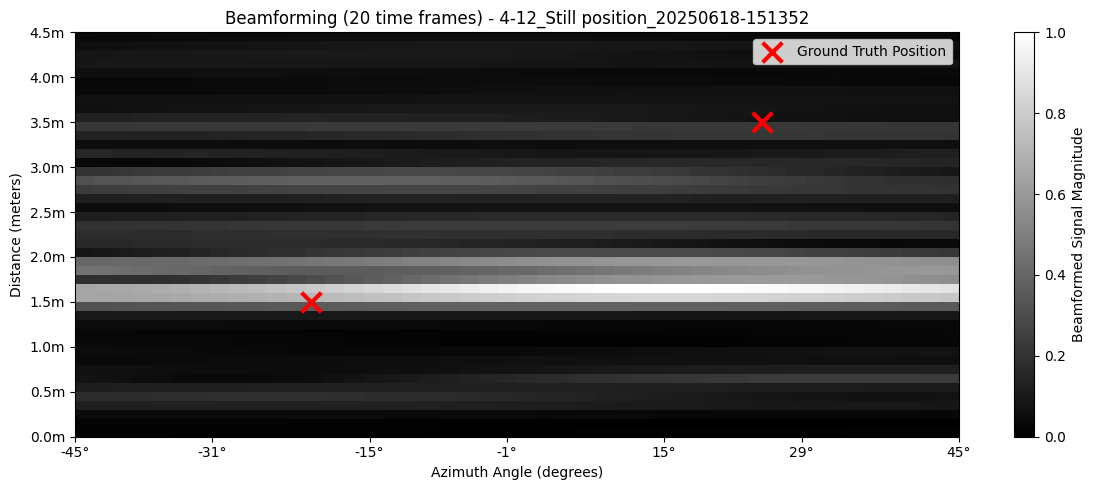


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '12']

--- Blob analysis complete ---
  '4' detected in 102 windows, starting at frames: [0, 10, 20, 30, 50, 70, 80, 90, 100, 110, 120, 130, 150, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 330, 350, 360, 380, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 730, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1140, 1160, 1170]
  '12' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['4', '12']) ---
  '4' was detected in 102 windows.
  '12' was NOT detected i

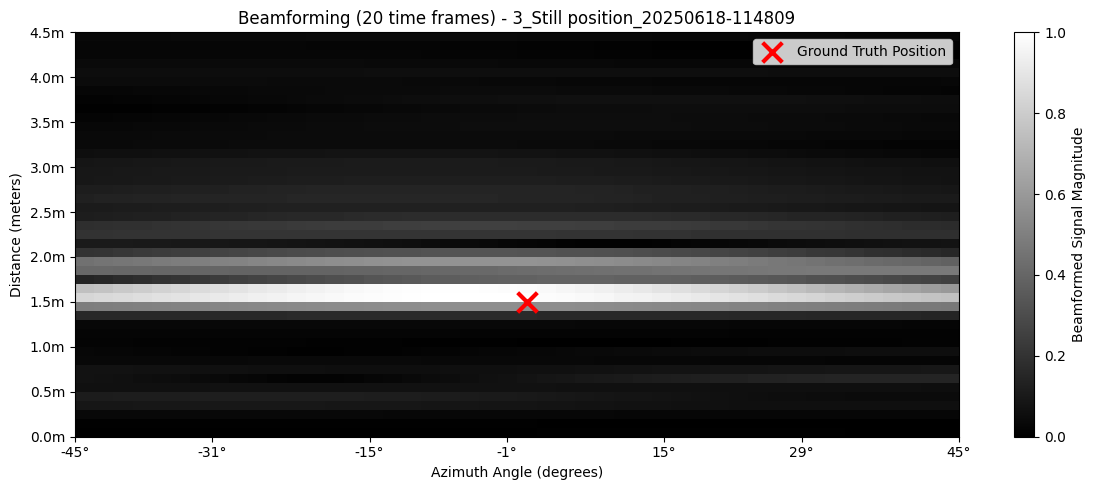


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3']

--- Blob analysis complete ---
  '3' detected in 114 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]

--- Summary of detected blobs (GTs = ['3']) ---
  '3' was detected in 114 windows.

Processing file: /kaggle/in

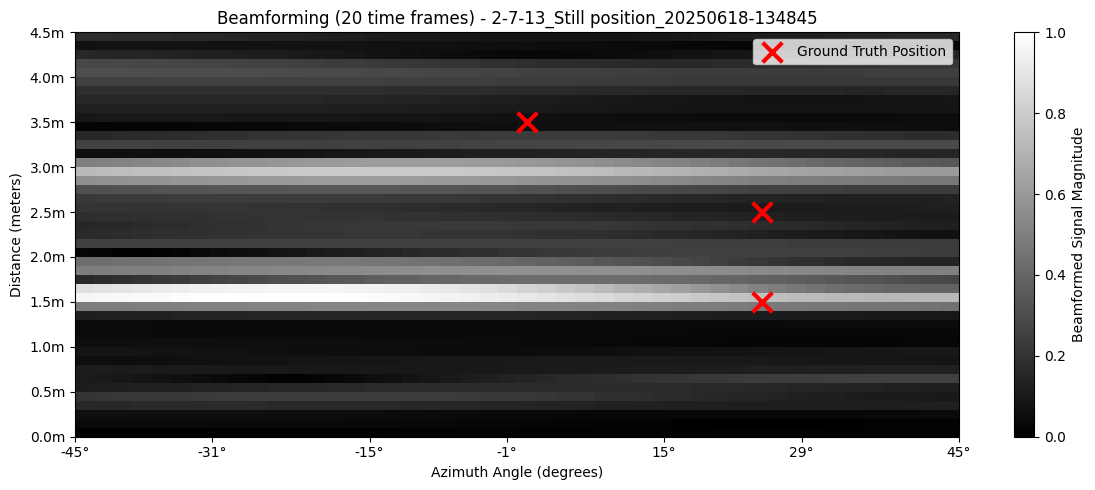


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '7', '13']

--- Blob analysis complete ---
  '2' detected in 19 windows, starting at frames: [0, 10, 40, 60, 80, 120, 140, 150, 160, 170, 180, 480, 1010, 1070, 1090, 1100, 1110, 1150, 1170]
  '7' not detected above threshold in any window.
  '13' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['2', '7', '13']) ---
  '2' was detected in 19 windows.
  '7' was NOT detected in any window above the threshold.
  '13' was NOT detected in any window above the threshold.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/2-3-4_Still position_20250618-140525_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/2-3-4_Still position_20250618-140525_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype 

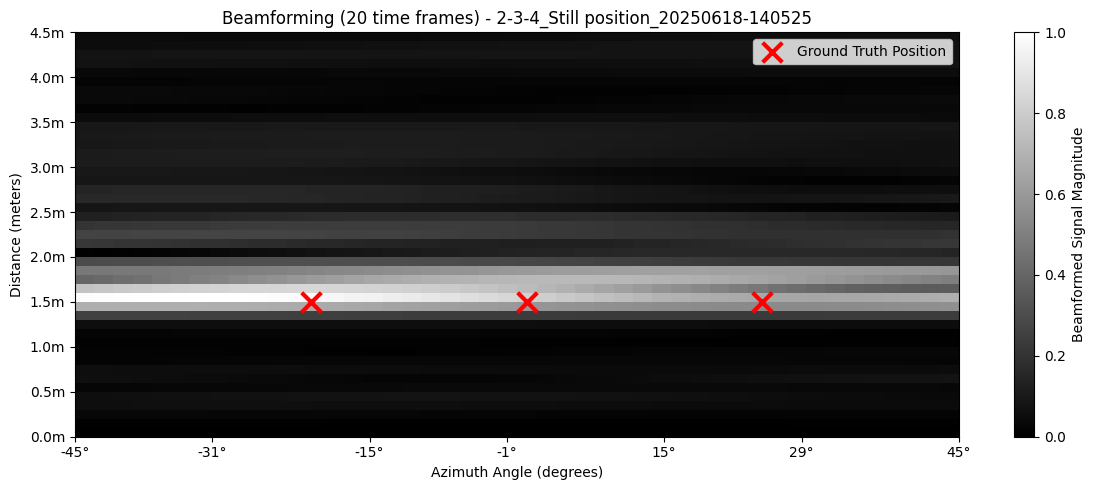


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '3', '4']

--- Blob analysis complete ---
  '2' detected in 80 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 170, 190, 200, 210, 220, 230, 240, 250, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 430, 450, 460, 470, 480, 490, 510, 520, 530, 540, 560, 570, 590, 610, 620, 640, 670, 690, 710, 720, 770, 850, 870, 880, 890, 910, 920, 930, 940, 950, 960, 970, 980, 1040, 1050, 1060, 1080, 1090, 1140, 1150, 1160, 1170, 1180]
  '3' detected in 89 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 80, 90, 100, 110, 120, 130, 140, 150, 170, 190, 200, 210, 220, 230, 240, 250, 260, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 510, 520, 530, 

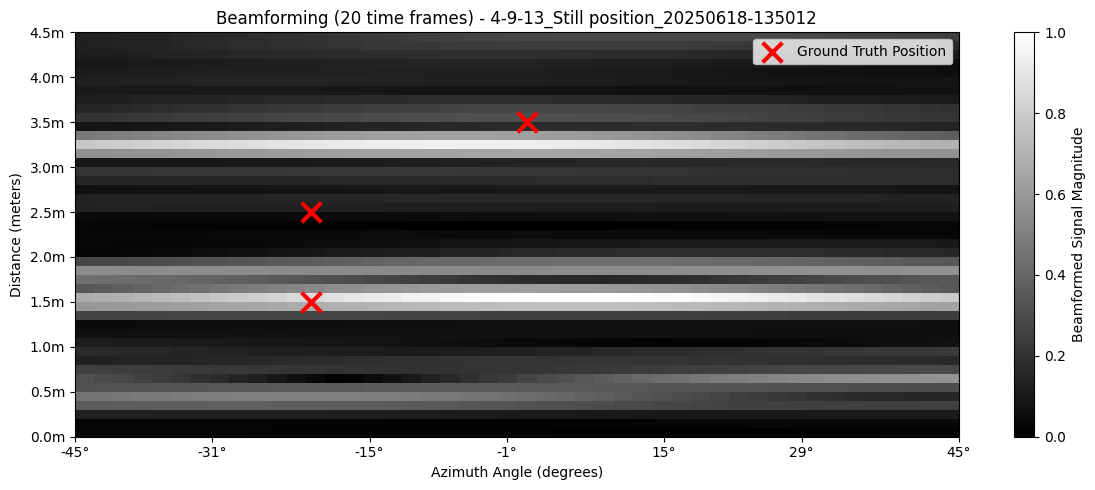


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '9', '13']

--- Blob analysis complete ---
  '4' detected in 98 windows, starting at frames: [0, 10, 20, 30, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 260, 270, 280, 290, 300, 310, 330, 340, 350, 390, 400, 410, 420, 440, 460, 480, 500, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 660, 670, 680, 700, 710, 720, 730, 740, 750, 760, 780, 790, 800, 820, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 960, 970, 980, 990, 1000, 1010, 1020, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]
  '9' detected in 1 windows, starting at frames: [380]
  '13' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['4', '9', '13']) ---
  '4' was detec

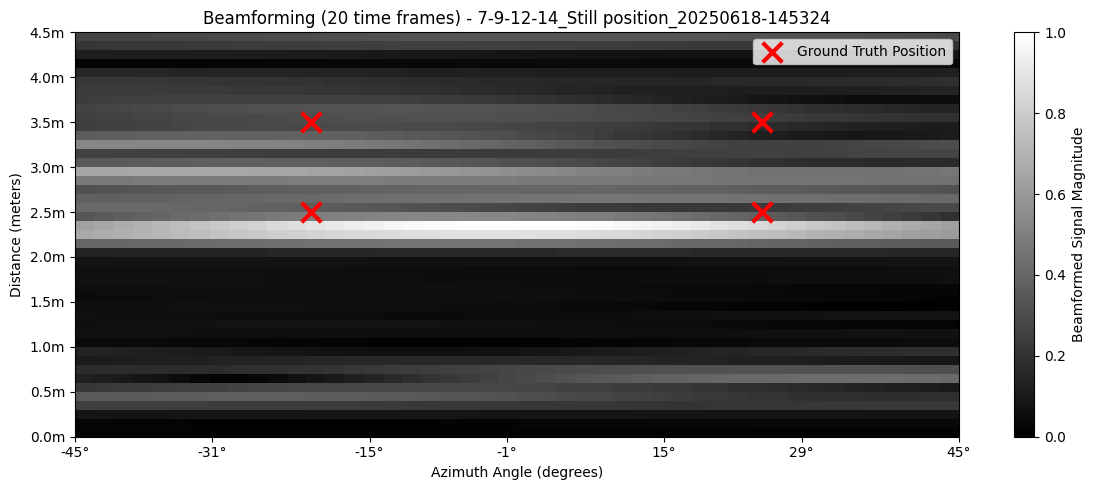


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['7', '9', '12', '14']

--- Blob analysis complete ---
  '7' detected in 26 windows, starting at frames: [10, 20, 30, 40, 50, 110, 140, 150, 230, 280, 330, 340, 350, 360, 410, 440, 470, 480, 570, 670, 750, 1000, 1020, 1080, 1100, 1160]
  '9' detected in 33 windows, starting at frames: [10, 20, 30, 40, 50, 110, 120, 130, 140, 150, 160, 200, 230, 250, 280, 330, 470, 480, 570, 600, 610, 660, 670, 720, 750, 760, 810, 960, 970, 1000, 1010, 1100, 1160]
  '12' not detected above threshold in any window.
  '14' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['7', '9', '12', '14']) ---
  '7' was detected in 26 windows.
  '9' was detected in 33 windows.
  '12' was NOT detected in any window above the threshold.
  '14' was NOT detected in any wi

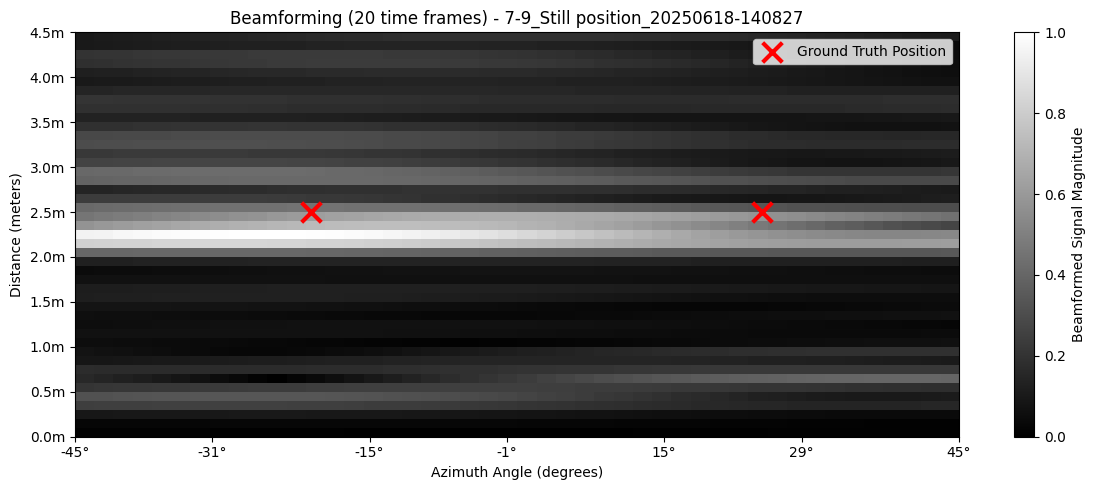


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['7', '9']

--- Blob analysis complete ---
  '7' detected in 52 windows, starting at frames: [10, 30, 50, 180, 200, 220, 230, 290, 350, 360, 370, 380, 420, 430, 440, 450, 460, 470, 500, 510, 520, 530, 570, 580, 590, 600, 620, 670, 690, 750, 760, 770, 780, 790, 800, 870, 910, 970, 980, 990, 1050, 1060, 1070, 1080, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]
  '9' detected in 72 windows, starting at frames: [10, 30, 40, 50, 150, 170, 180, 190, 200, 260, 270, 290, 300, 360, 370, 380, 400, 430, 440, 450, 460, 470, 480, 500, 510, 520, 530, 570, 580, 590, 600, 620, 640, 670, 690, 730, 740, 750, 760, 770, 780, 790, 800, 810, 830, 850, 870, 880, 910, 930, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 11

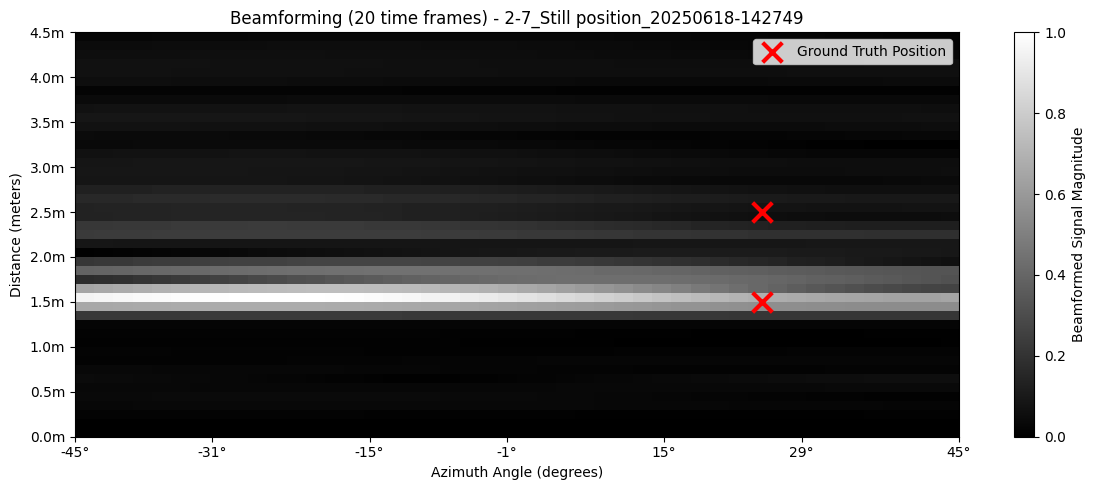


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '7']

--- Blob analysis complete ---
  '2' detected in 85 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 90, 100, 110, 130, 140, 150, 160, 170, 190, 200, 210, 220, 230, 240, 250, 260, 270, 340, 350, 360, 370, 380, 390, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 550, 570, 580, 590, 620, 640, 650, 660, 670, 690, 700, 710, 720, 730, 750, 760, 770, 780, 790, 800, 820, 840, 880, 910, 930, 960, 980, 990, 1010, 1020, 1030, 1040, 1050, 1060, 1090, 1110, 1130, 1150, 1160, 1170, 1180]
  '7' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['2', '7']) ---
  '2' was detected in 85 windows.
  '7' was NOT detected in any window above the threshold.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/

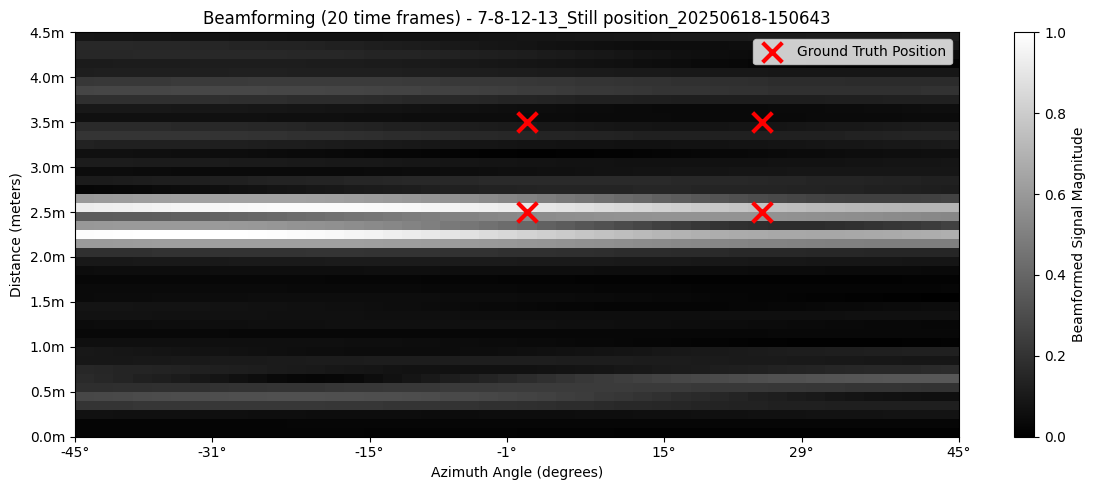


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['7', '8', '12', '13']

--- Blob analysis complete ---
  '7' detected in 58 windows, starting at frames: [0, 10, 20, 30, 50, 60, 70, 110, 120, 140, 150, 190, 220, 230, 250, 260, 270, 280, 320, 330, 340, 350, 390, 410, 420, 430, 450, 460, 470, 480, 490, 500, 620, 630, 640, 660, 710, 730, 740, 780, 820, 830, 840, 870, 910, 950, 970, 980, 990, 1060, 1080, 1090, 1100, 1120, 1130, 1160, 1170, 1180]
  '8' detected in 74 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 110, 120, 140, 150, 180, 190, 220, 230, 240, 250, 260, 270, 280, 300, 320, 330, 340, 350, 370, 390, 410, 420, 430, 450, 460, 470, 480, 490, 500, 520, 530, 550, 610, 620, 630, 640, 660, 710, 730, 740, 780, 790, 810, 820, 830, 840, 850, 870, 880, 890, 910, 950, 970, 980, 990, 1010, 1020, 1060, 1080, 1

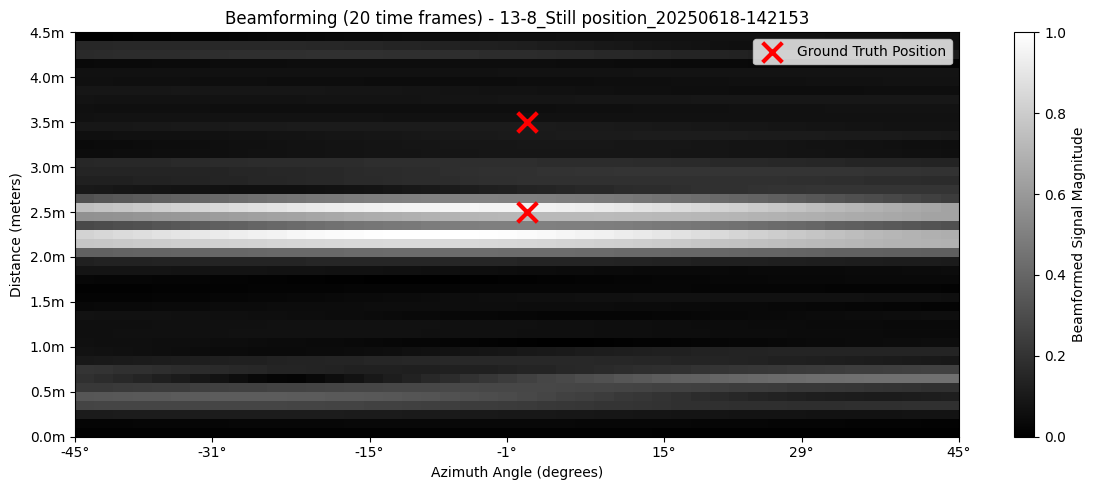


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['13', '8']

--- Blob analysis complete ---
  '13' not detected above threshold in any window.
  '8' detected in 48 windows, starting at frames: [0, 60, 80, 100, 110, 140, 160, 170, 180, 200, 240, 290, 340, 380, 390, 410, 420, 440, 480, 500, 520, 530, 540, 550, 560, 570, 580, 590, 600, 630, 640, 660, 680, 690, 700, 710, 770, 800, 810, 830, 840, 900, 920, 930, 980, 990, 1070, 1160]

--- Summary of detected blobs (GTs = ['13', '8']) ---
  '13' was NOT detected in any window above the threshold.
  '8' was detected in 48 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/8-9-13-14_Still position_20250618-150804_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/8-9-13-14_Still position_20250618-150804_sr250_rx0.npy ---

Shape of the a

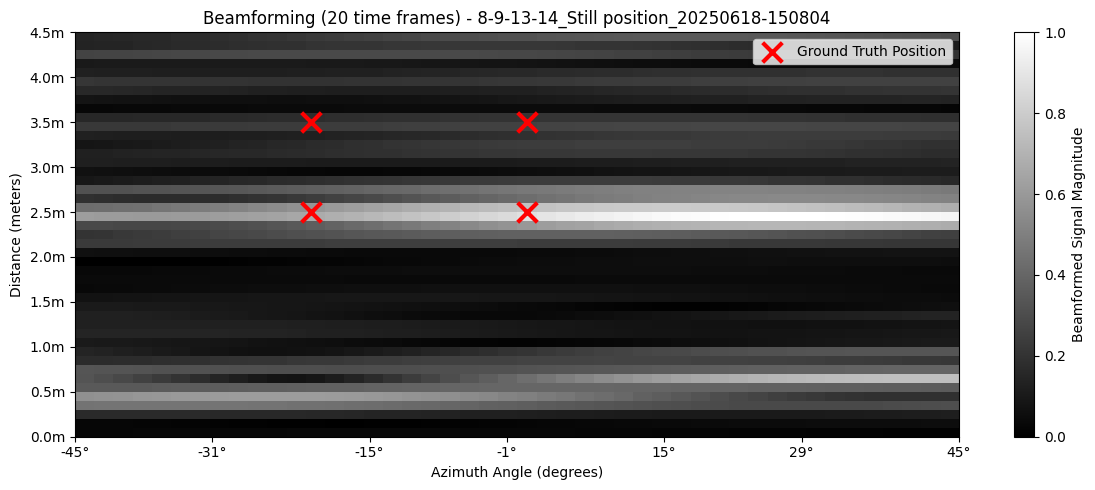


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['8', '9', '13', '14']

--- Blob analysis complete ---
  '8' detected in 51 windows, starting at frames: [0, 10, 20, 70, 120, 220, 310, 340, 350, 360, 490, 500, 530, 540, 550, 560, 570, 650, 680, 690, 700, 720, 730, 740, 750, 760, 790, 820, 830, 840, 850, 870, 900, 920, 930, 940, 980, 990, 1000, 1010, 1030, 1050, 1080, 1090, 1100, 1110, 1120, 1130, 1150, 1170, 1180]
  '9' detected in 42 windows, starting at frames: [70, 220, 310, 340, 360, 490, 500, 530, 540, 650, 680, 690, 700, 720, 730, 740, 750, 760, 790, 820, 830, 850, 870, 900, 920, 930, 940, 960, 980, 990, 1000, 1010, 1030, 1050, 1080, 1090, 1100, 1110, 1130, 1150, 1170, 1180]
  '13' not detected above threshold in any window.
  '14' not detected above threshold in any window.

--- Summary of detected blobs (GTs 

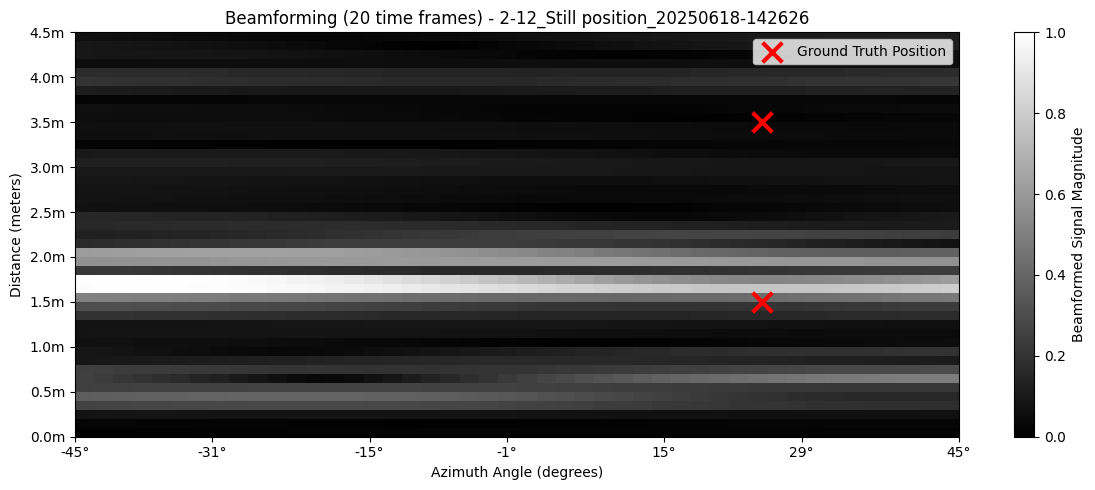


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '12']

--- Blob analysis complete ---
  '2' detected in 85 windows, starting at frames: [10, 20, 30, 90, 160, 170, 180, 190, 210, 230, 280, 290, 300, 320, 340, 350, 360, 370, 390, 400, 440, 450, 460, 470, 480, 490, 500, 520, 530, 540, 560, 570, 580, 590, 600, 610, 630, 640, 650, 660, 670, 690, 700, 720, 740, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]
  '12' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['2', '12']) ---
  '2' was detected in 85 windows.
  '12' was NOT detected in any window above the threshold.

Processing file: /kaggle/input/haeeai-projec

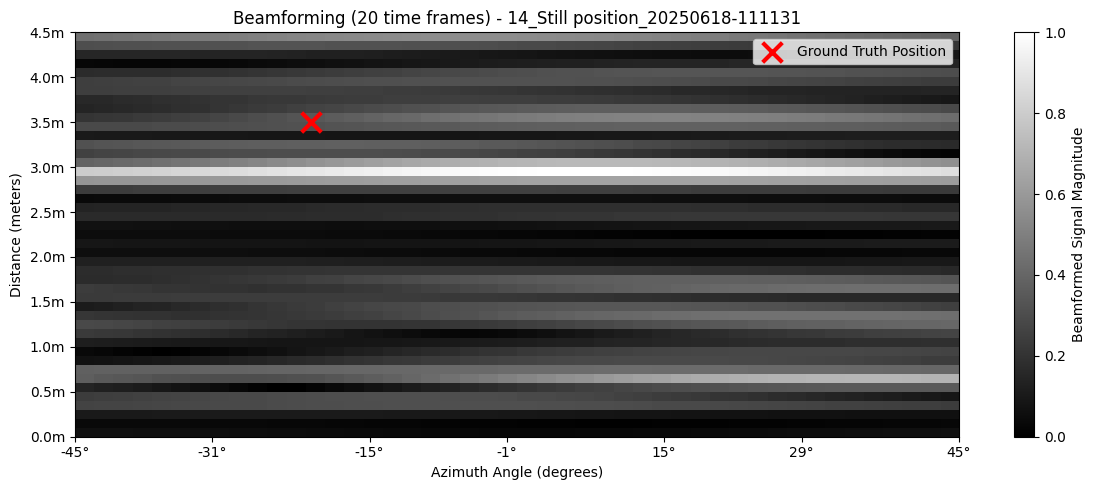


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['14']

--- Blob analysis complete ---
  '14' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['14']) ---
  '14' was NOT detected in any window above the threshold.

No blobs were detected above the threshold at the specified ground truth positions.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/2-4-13_Still position_20250618-120003_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/2-4-13_Still position_20250618-120003_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for visualization (first 20 frames)...
Generating Beamformed

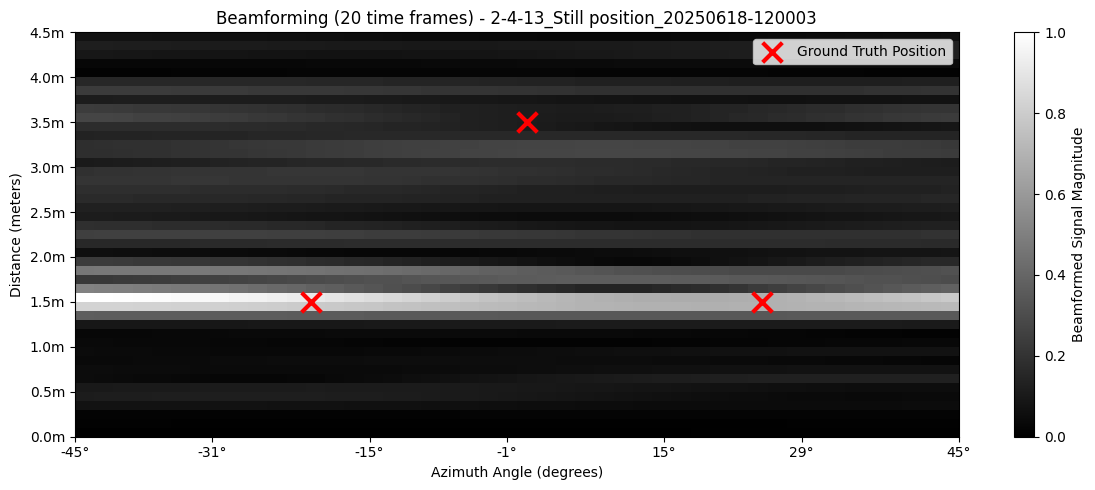


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '4', '13']

--- Blob analysis complete ---
  '2' detected in 93 windows, starting at frames: [0, 10, 20, 40, 50, 70, 80, 90, 100, 110, 120, 150, 170, 200, 210, 220, 230, 240, 250, 260, 280, 290, 300, 310, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 530, 550, 570, 580, 590, 600, 610, 620, 630, 650, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 850, 860, 870, 880, 910, 920, 950, 960, 990, 1010, 1020, 1030, 1050, 1070, 1080, 1100, 1110, 1120, 1130, 1140, 1160, 1170, 1180]
  '4' detected in 100 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 280, 290, 300, 310, 320, 330, 340, 350, 360

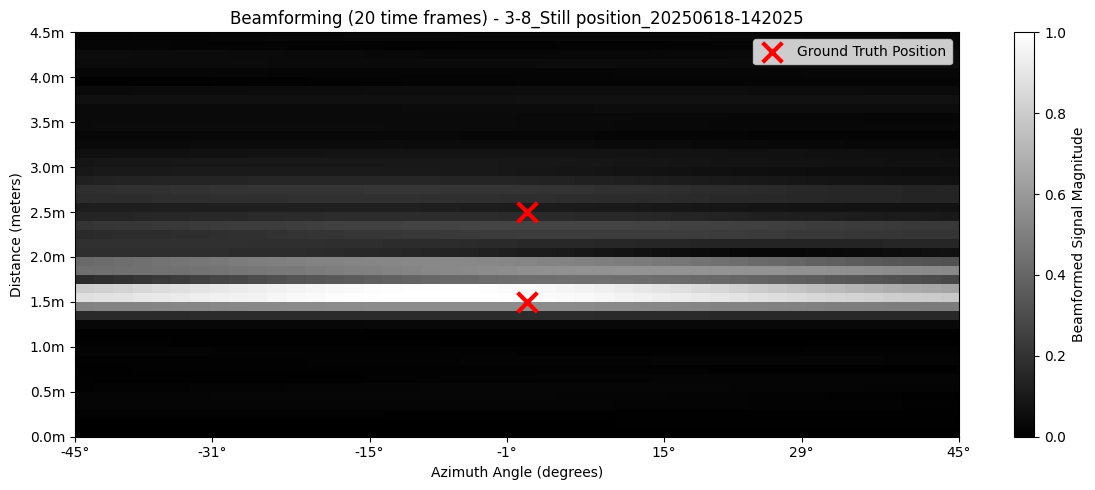


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '8']

--- Blob analysis complete ---
  '3' detected in 116 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1090, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]
  '8' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['3', '8']

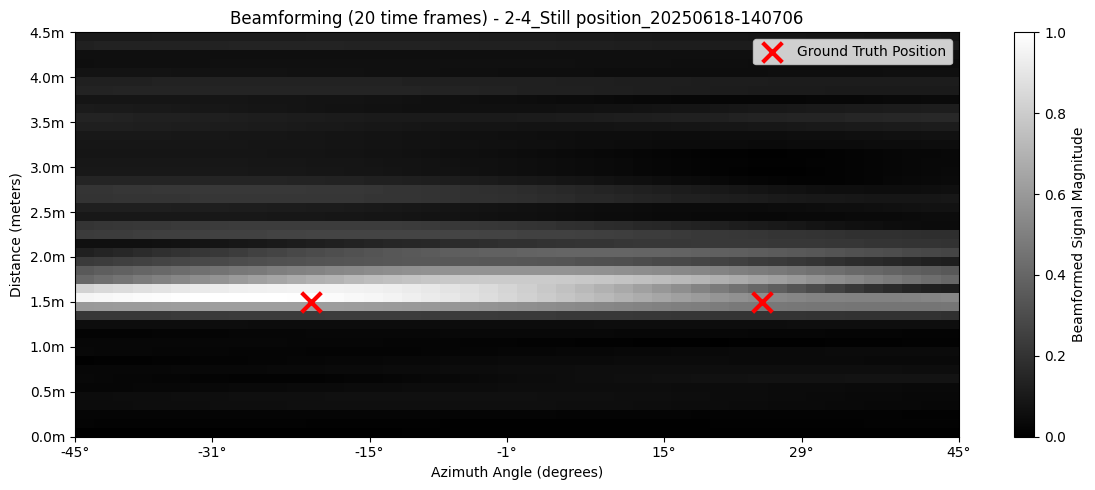


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '4']

--- Blob analysis complete ---
  '2' detected in 87 windows, starting at frames: [10, 20, 30, 40, 50, 70, 100, 110, 120, 130, 140, 160, 170, 180, 200, 210, 230, 240, 250, 270, 290, 310, 320, 330, 350, 360, 370, 380, 390, 400, 410, 420, 430, 450, 460, 490, 500, 510, 520, 530, 550, 560, 580, 590, 600, 620, 640, 650, 660, 670, 680, 690, 710, 730, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1040, 1050, 1060, 1080, 1100, 1110, 1130]
  '4' detected in 104 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 200, 210, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 350, 360, 370, 380, 390, 400, 410, 420, 430, 

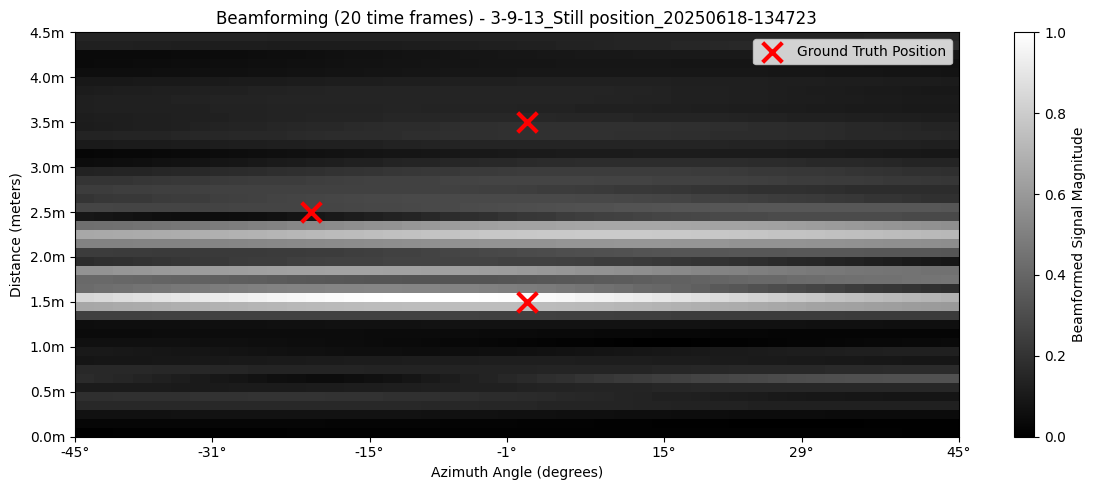


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '9', '13']

--- Blob analysis complete ---
  '3' detected in 109 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 860, 870, 880, 890, 900, 910, 920, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1050, 1060, 1070, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]
  '9' detected in 5 windows, starting at frames: [260, 280, 300, 830, 900]
  '13' not detected above threshold in any window.

--

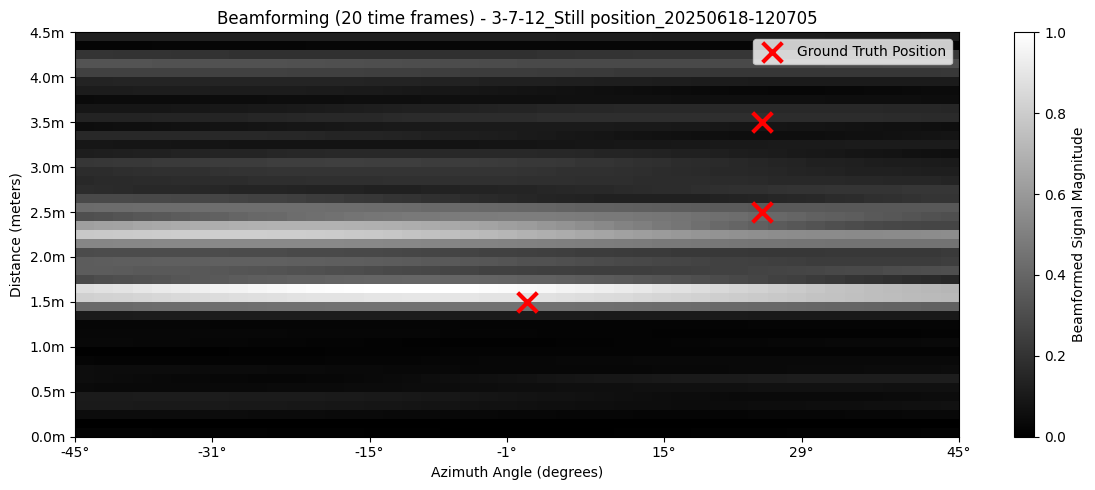


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '7', '12']

--- Blob analysis complete ---
  '3' detected in 111 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1160]
  '7' detected in 1 windows, starting at frames: [590]
  '12' not detected above threshold in any window.

--- Summary o

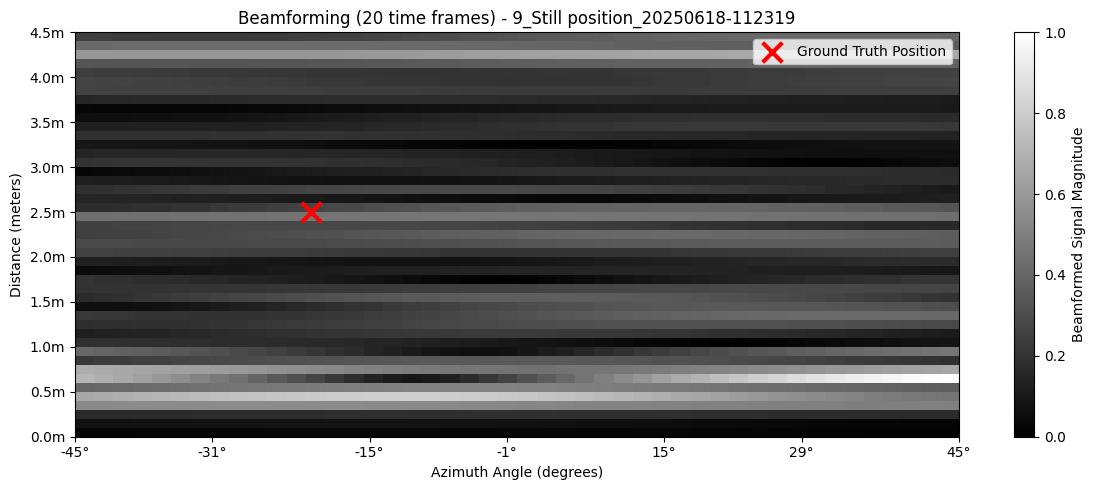


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['9']

--- Blob analysis complete ---
  '9' detected in 62 windows, starting at frames: [10, 20, 40, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 170, 180, 190, 210, 220, 250, 290, 340, 350, 370, 380, 390, 420, 450, 470, 490, 530, 540, 550, 570, 590, 610, 620, 640, 700, 720, 730, 760, 780, 800, 840, 850, 870, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 1030, 1070, 1080, 1090, 1130, 1180]

--- Summary of detected blobs (GTs = ['9']) ---
  '9' was detected in 62 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/4-14_Still position_20250618-142446_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/4-14_Still position_20250618-142446_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complet

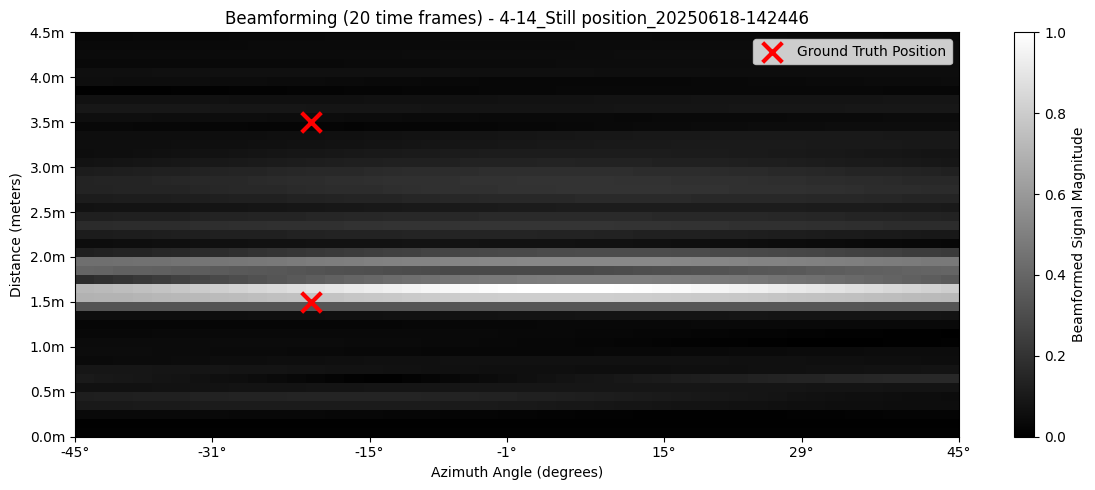


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '14']

--- Blob analysis complete ---
  '4' detected in 115 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 780, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]
  '14' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['4', '14']

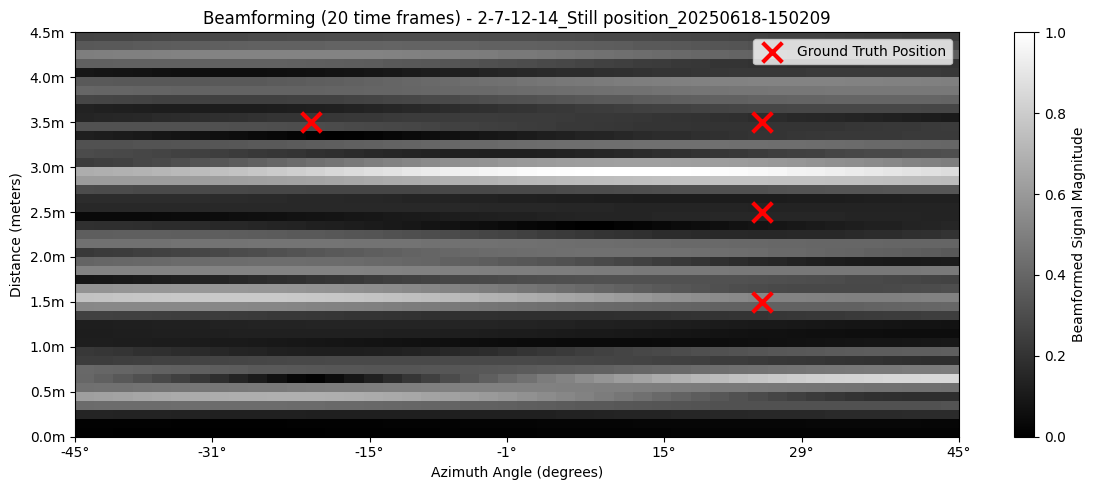


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '7', '12', '14']

--- Blob analysis complete ---
  '2' detected in 58 windows, starting at frames: [0, 50, 60, 70, 80, 100, 110, 120, 140, 150, 170, 190, 200, 210, 220, 250, 260, 270, 280, 290, 300, 310, 320, 370, 420, 440, 450, 480, 570, 590, 610, 620, 630, 640, 650, 660, 670, 680, 690, 710, 770, 790, 810, 820, 870, 880, 890, 910, 930, 990, 1030, 1050, 1080, 1090, 1100, 1110, 1140, 1160]
  '7' not detected above threshold in any window.
  '12' not detected above threshold in any window.
  '14' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['2', '7', '12', '14']) ---
  '2' was detected in 58 windows.
  '7' was NOT detected in any window above the threshold.
  '12' was NOT detected in any window above the threshold.
  '14' was N

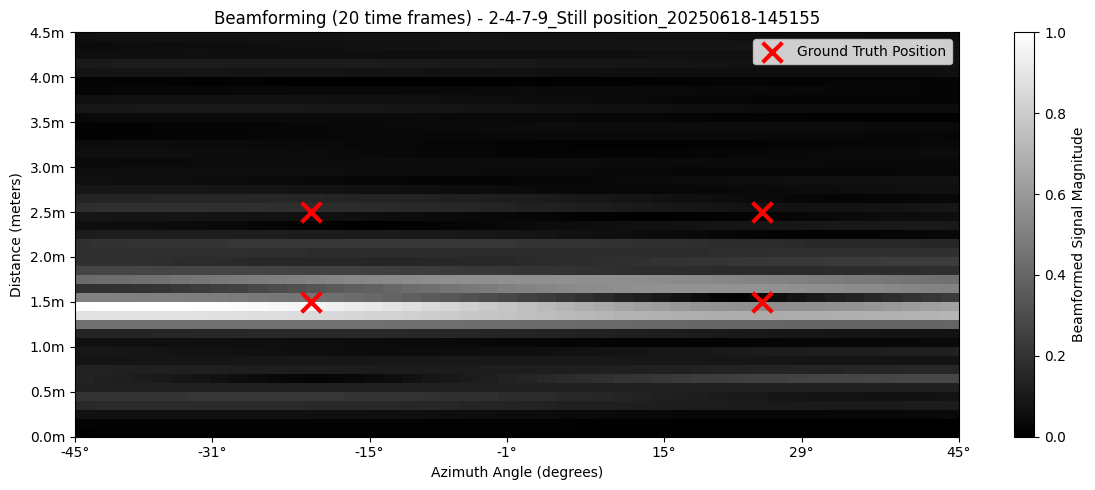


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '4', '7', '9']

--- Blob analysis complete ---
  '2' detected in 49 windows, starting at frames: [70, 80, 130, 150, 160, 170, 180, 200, 270, 280, 290, 310, 340, 360, 390, 410, 420, 440, 460, 470, 480, 490, 500, 550, 560, 570, 590, 600, 630, 700, 740, 750, 760, 770, 790, 820, 830, 840, 850, 880, 890, 900, 940, 950, 970, 980, 1050, 1090, 1110]
  '4' detected in 84 windows, starting at frames: [30, 50, 60, 70, 80, 110, 120, 130, 150, 170, 180, 200, 210, 220, 230, 240, 250, 280, 290, 300, 310, 320, 330, 340, 350, 360, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 560, 570, 590, 600, 620, 630, 640, 650, 660, 670, 680, 690, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 970, 980, 1000, 10

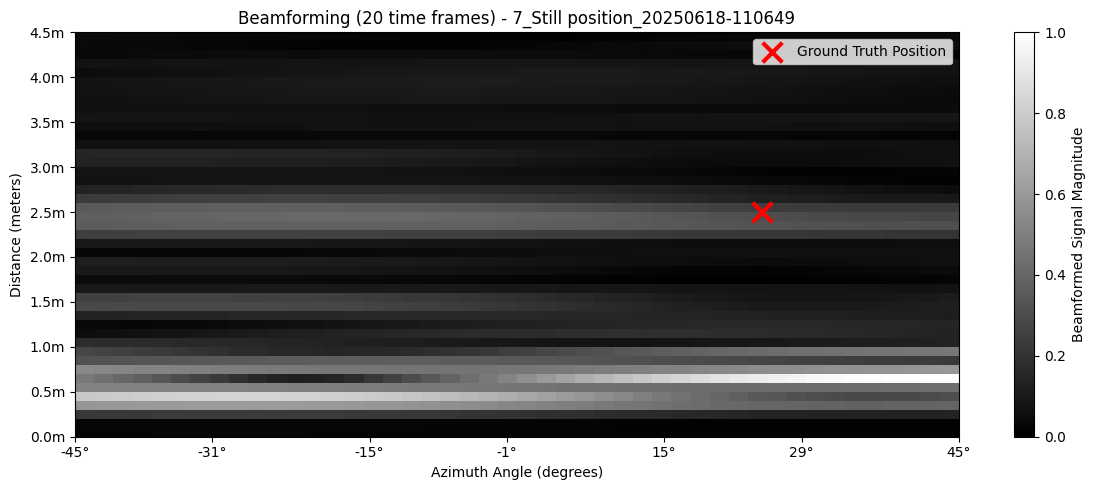


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['7']

--- Blob analysis complete ---
  '7' detected in 33 windows, starting at frames: [60, 120, 140, 160, 180, 190, 200, 220, 250, 290, 310, 320, 330, 380, 400, 480, 500, 530, 540, 560, 580, 650, 670, 680, 720, 910, 920, 930, 970, 980, 1010, 1020, 1050]

--- Summary of detected blobs (GTs = ['7']) ---
  '7' was detected in 33 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/2-4-12_Still position_20250618-115616_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/2-4-12_Still position_20250618-115616_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for v

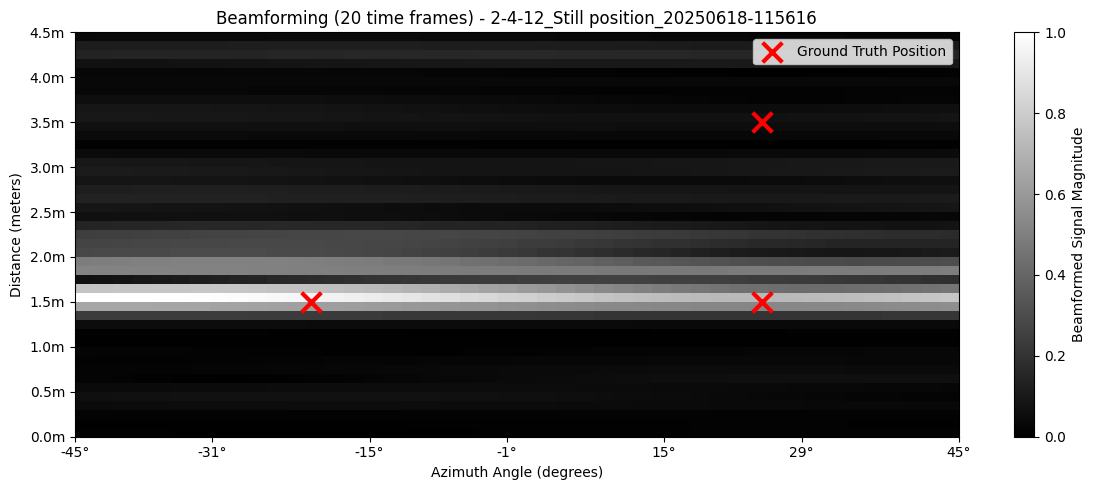


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '4', '12']

--- Blob analysis complete ---
  '2' detected in 87 windows, starting at frames: [0, 20, 30, 40, 60, 70, 90, 100, 120, 140, 160, 180, 200, 220, 250, 260, 270, 290, 300, 310, 320, 330, 340, 350, 360, 380, 390, 410, 420, 430, 440, 460, 480, 500, 510, 520, 530, 540, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 900, 910, 920, 940, 950, 990, 1000, 1010, 1030, 1040, 1050, 1100, 1130, 1140, 1150, 1170, 1180]
  '4' detected in 107 windows, starting at frames: [0, 10, 20, 30, 40, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 380, 390, 400, 410, 430,

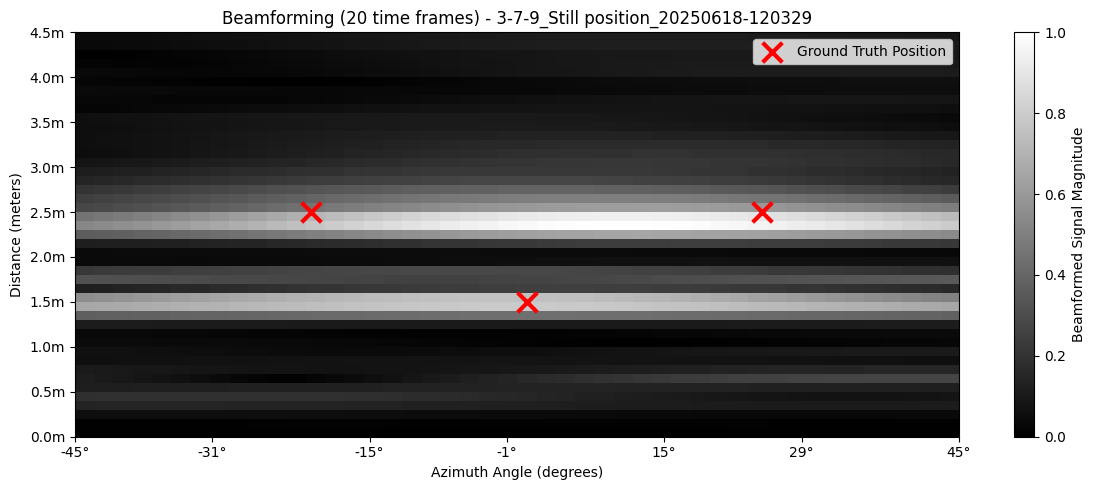


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '7', '9']

--- Blob analysis complete ---
  '3' detected in 87 windows, starting at frames: [0, 10, 20, 30, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 410, 420, 500, 510, 530, 540, 560, 590, 610, 630, 640, 650, 660, 670, 680, 690, 700, 720, 740, 750, 780, 790, 810, 850, 860, 870, 880, 890, 900, 910, 920, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1040, 1060, 1080, 1090, 1100, 1120, 1130, 1150]
  '7' detected in 33 windows, starting at frames: [10, 20, 70, 80, 90, 140, 150, 320, 340, 440, 460, 470, 540, 550, 560, 570, 590, 610, 620, 630, 640, 740, 760, 780, 820, 830, 850, 880, 910, 930, 1030, 1140, 1160]
  '9' detected in 32 windows, 

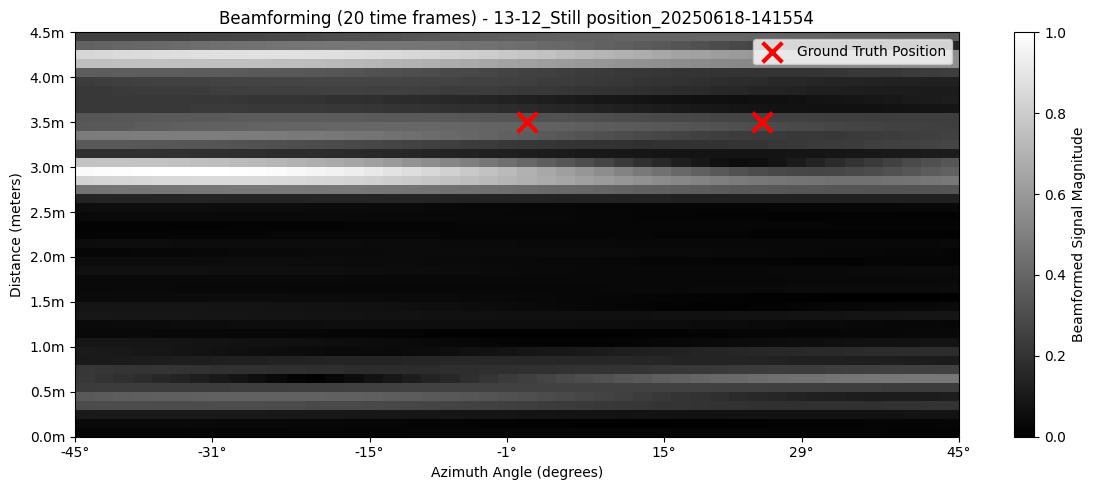


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['13', '12']

--- Blob analysis complete ---
  '13' not detected above threshold in any window.
  '12' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['13', '12']) ---
  '13' was NOT detected in any window above the threshold.
  '12' was NOT detected in any window above the threshold.

No blobs were detected above the threshold at the specified ground truth positions.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/3-7-13_Still position_20250618-120843_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/3-7-13_Still position_20250618-120843_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (12

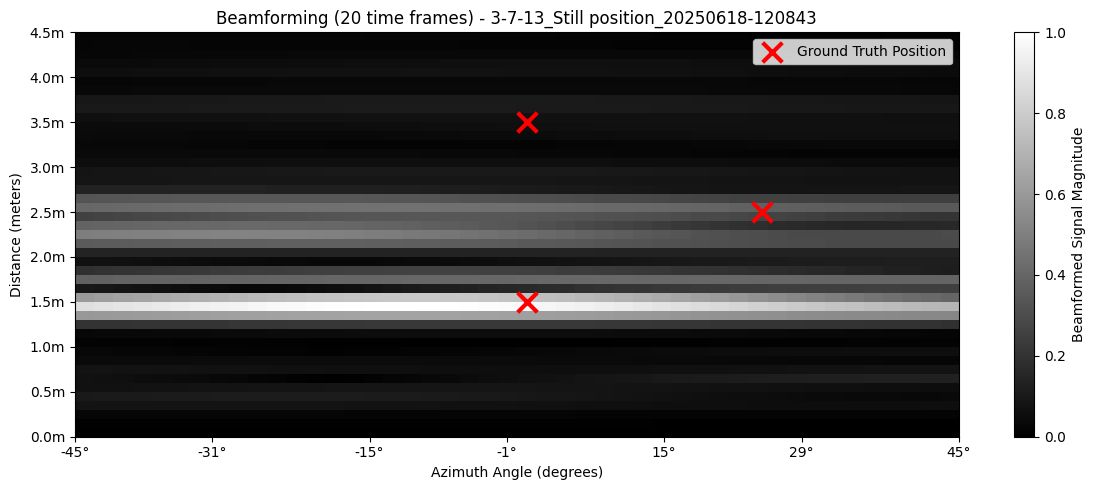


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '7', '13']

--- Blob analysis complete ---
  '3' detected in 38 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 130, 400, 510, 550, 600, 610, 620, 630, 640, 710, 720, 730, 750, 770, 780, 790, 800, 810, 830, 840, 850, 860, 930, 940, 950, 1010, 1020, 1030, 1140]
  '7' detected in 3 windows, starting at frames: [150, 590, 610]
  '13' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['3', '7', '13']) ---
  '3' was detected in 38 windows.
  '7' was detected in 3 windows.
  '13' was NOT detected in any window above the threshold.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/4_Still position_20250618-111410_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/4_Still position_20250618-11

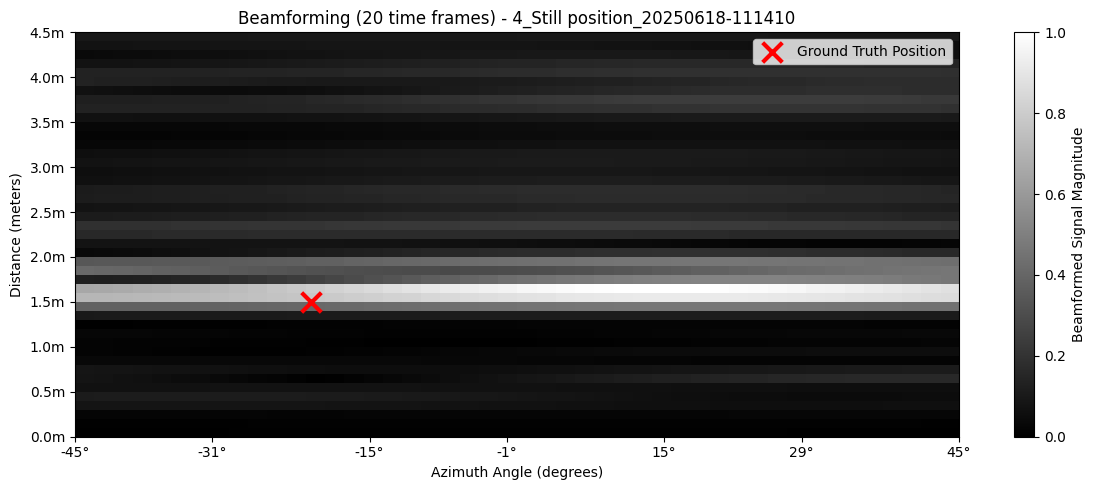


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4']

--- Blob analysis complete ---
  '4' detected in 101 windows, starting at frames: [0, 10, 20, 30, 50, 70, 80, 90, 100, 110, 120, 140, 160, 170, 180, 190, 200, 210, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 410, 430, 440, 450, 460, 470, 500, 510, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 640, 660, 670, 680, 690, 700, 710, 720, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]

--- Summary of detected blobs (GTs = ['4']) ---
  '4' was detected in 101 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/4-12-14 _Still position_20250

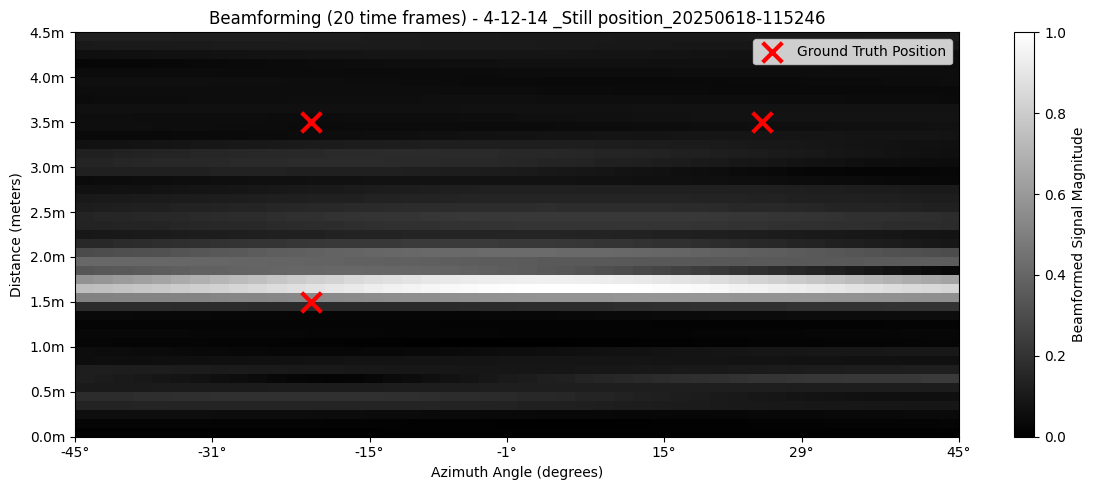


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '12', '14']

--- Blob analysis complete ---
  '4' detected in 103 windows, starting at frames: [30, 40, 60, 80, 90, 120, 130, 140, 160, 170, 180, 190, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1130, 1140, 1150, 1160, 1170, 1180]
  '12' detected in 1 windows, starting at frames: [280]
  '14' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['4',

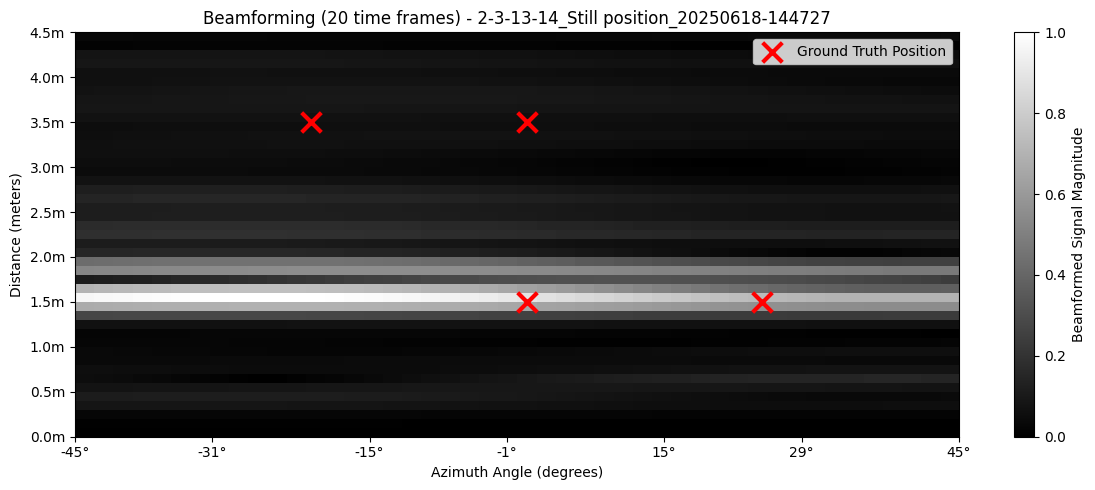


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '3', '13', '14']

--- Blob analysis complete ---
  '2' detected in 91 windows, starting at frames: [0, 10, 20, 30, 40, 50, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 240, 280, 290, 300, 310, 320, 330, 340, 360, 370, 380, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 690, 700, 720, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 880, 890, 920, 970, 990, 1010, 1020, 1030, 1040, 1050, 1060, 1080, 1090, 1100, 1110, 1120, 1170, 1180]
  '3' detected in 99 windows, starting at frames: [0, 10, 20, 30, 40, 50, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 210, 240, 280, 290, 300, 310, 320, 330, 340, 360, 370, 380, 390, 400, 410, 420, 430,

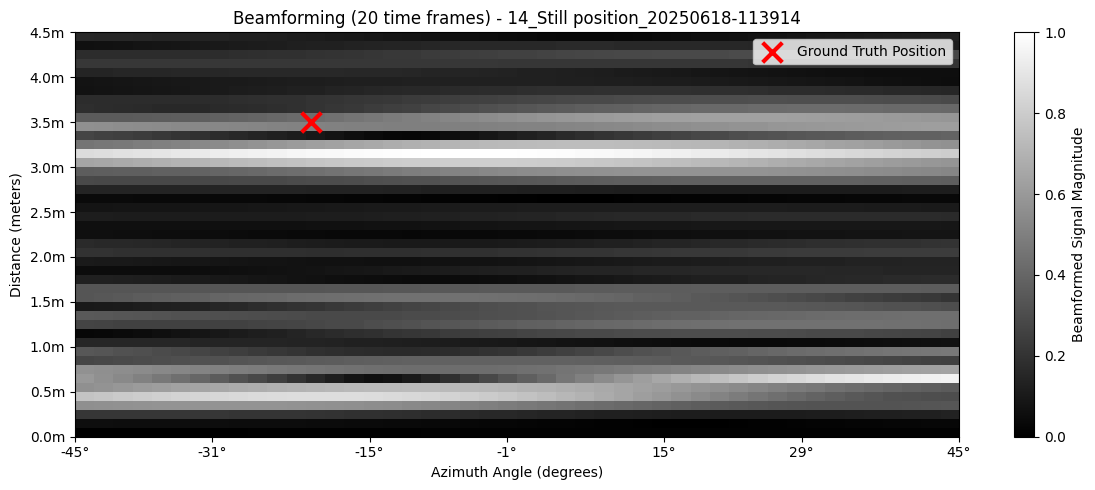


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['14']

--- Blob analysis complete ---
  '14' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['14']) ---
  '14' was NOT detected in any window above the threshold.

No blobs were detected above the threshold at the specified ground truth positions.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/2-7-12_Still position_20250618-140100_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/2-7-12_Still position_20250618-140100_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for visualization (first 20 frames)...
Generating Beamformed

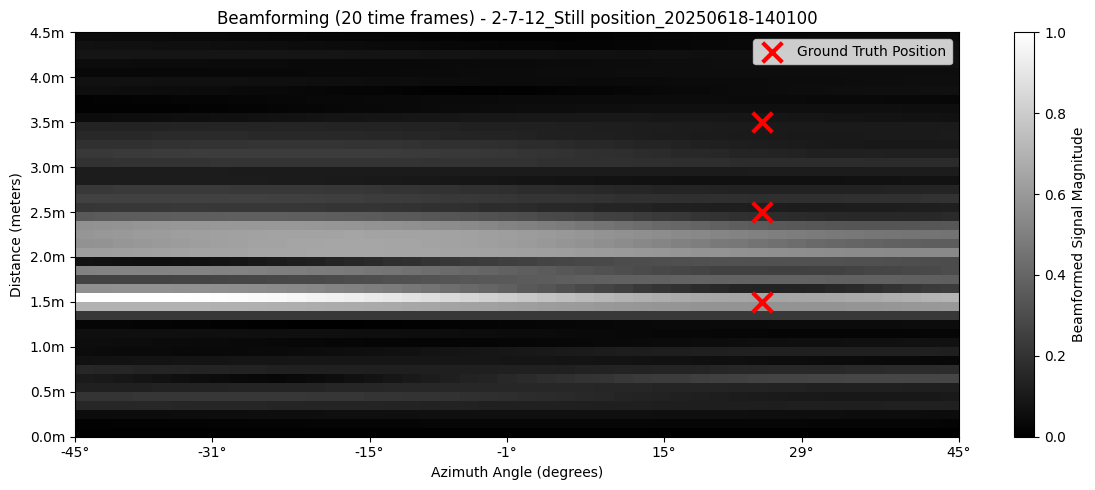


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '7', '12']

--- Blob analysis complete ---
  '2' detected in 76 windows, starting at frames: [0, 10, 30, 40, 100, 120, 190, 210, 290, 310, 320, 330, 340, 350, 360, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 700, 720, 730, 740, 750, 760, 770, 780, 800, 810, 820, 830, 850, 890, 910, 930, 940, 950, 960, 970, 980, 990, 1000, 1020, 1030, 1040, 1050, 1060, 1070, 1110, 1120, 1140]
  '7' not detected above threshold in any window.
  '12' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['2', '7', '12']) ---
  '2' was detected in 76 windows.
  '7' was NOT detected in any window above the threshold.
  '12' was NOT detected in any window abo

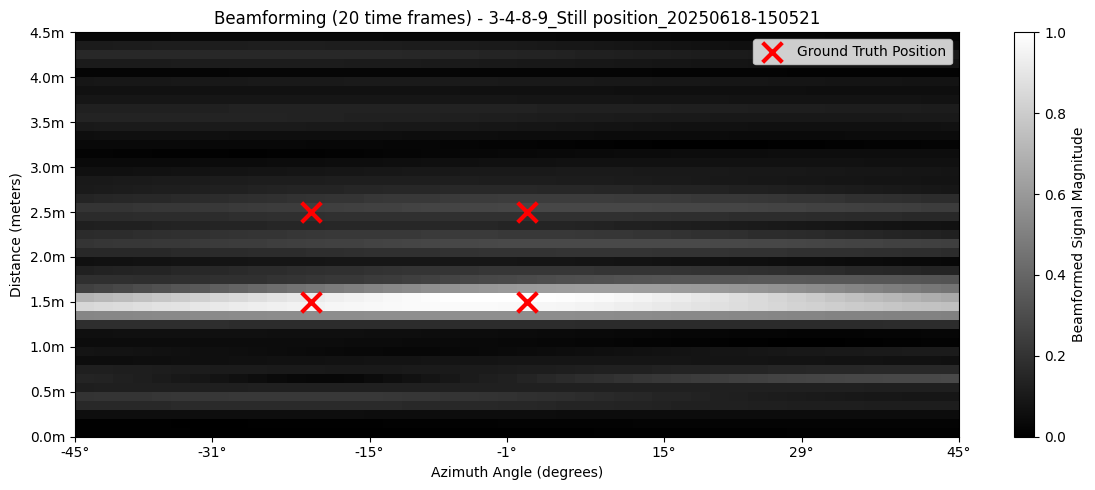


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['3', '4', '8', '9']

--- Blob analysis complete ---
  '3' detected in 102 windows, starting at frames: [0, 10, 20, 30, 50, 60, 80, 90, 100, 110, 150, 170, 180, 190, 200, 210, 220, 230, 240, 250, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 390, 410, 420, 430, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 620, 630, 640, 650, 660, 680, 690, 700, 710, 720, 730, 740, 750, 770, 780, 790, 800, 810, 820, 830, 840, 850, 870, 880, 890, 900, 910, 920, 930, 940, 960, 970, 990, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]
  '4' detected in 101 windows, starting at frames: [0, 10, 20, 30, 50, 60, 80, 100, 110, 120, 150, 170, 180, 190, 200, 210, 220, 230, 240, 250, 270, 280, 2

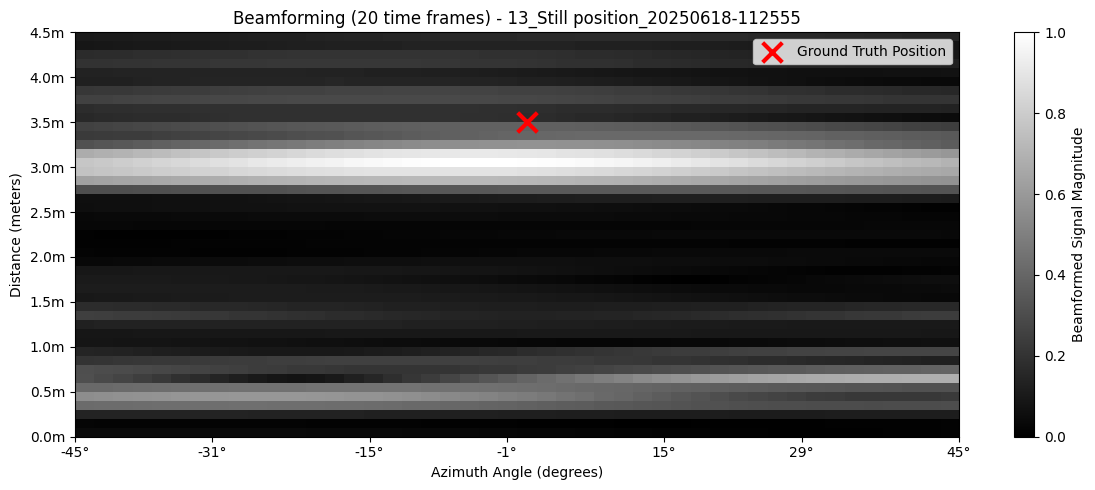


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['13']

--- Blob analysis complete ---
  '13' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['13']) ---
  '13' was NOT detected in any window above the threshold.

No blobs were detected above the threshold at the specified ground truth positions.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/8_Still position_20250618-114420_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/8_Still position_20250618-114420_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range bins.
Shape of the full beamformed data: (1200, 45, 46) with dtype complex128
Applying coherent averaging for visualization (first 20 frames)...
Generating Beamformed plot...



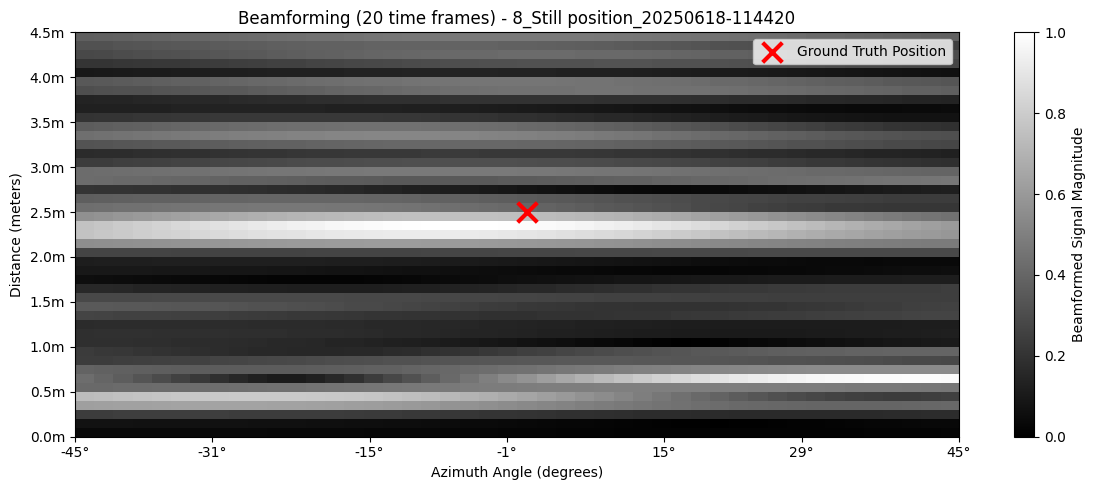


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['8']

--- Blob analysis complete ---
  '8' detected in 57 windows, starting at frames: [10, 20, 30, 40, 90, 120, 140, 150, 160, 170, 180, 220, 230, 250, 260, 270, 280, 290, 300, 310, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 440, 450, 460, 470, 480, 490, 500, 510, 530, 540, 550, 560, 570, 590, 600, 640, 720, 730, 850, 860, 880, 900, 910, 1050, 1070, 1100, 1120]

--- Summary of detected blobs (GTs = ['8']) ---
  '8' was detected in 57 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/4-3_Still position_20250618-141131_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/4-3_Still position_20250618-141131_sr250_rx0.npy ---

Shape of the antennas: (1200, 45), with dtype complex64
Beamforming complete for all frames and range 

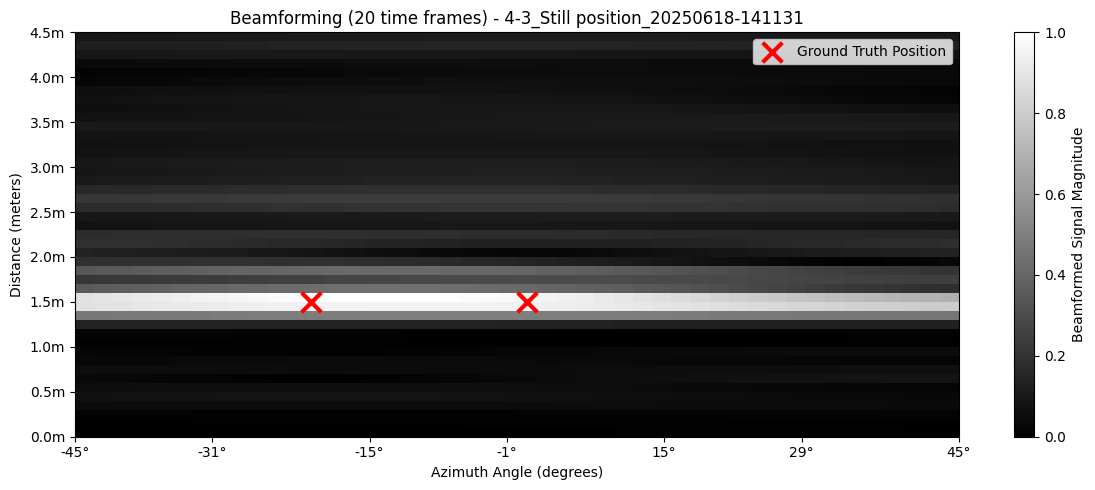


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '3']

--- Blob analysis complete ---
  '4' detected in 104 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 170, 180, 190, 200, 230, 240, 260, 270, 280, 290, 300, 310, 320, 330, 340, 360, 370, 380, 410, 420, 430, 440, 460, 470, 510, 520, 530, 540, 560, 570, 580, 590, 600, 620, 640, 650, 660, 670, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]
  '3' detected in 107 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 220, 230, 

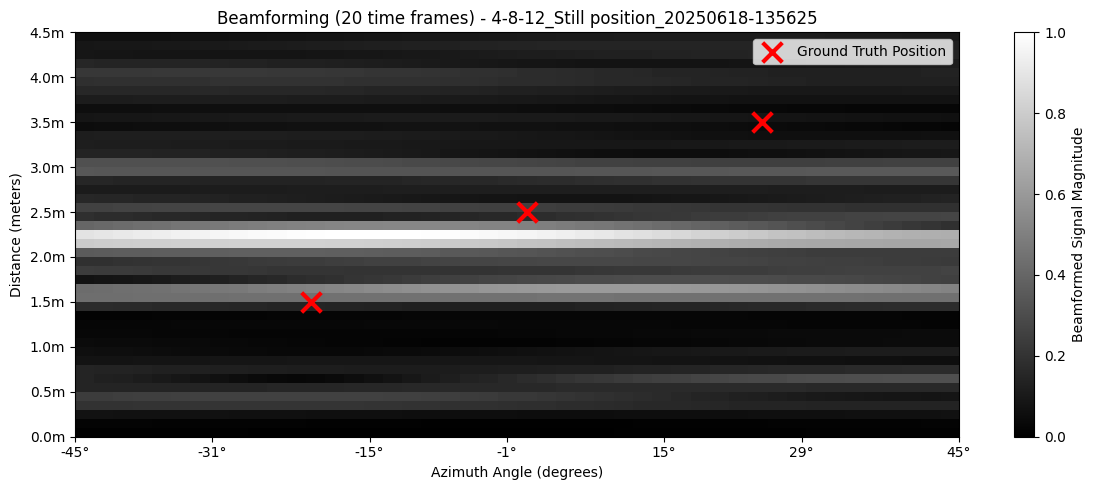


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '8', '12']

--- Blob analysis complete ---
  '4' detected in 92 windows, starting at frames: [20, 30, 40, 60, 70, 80, 90, 100, 110, 140, 160, 180, 190, 200, 210, 220, 240, 260, 270, 290, 300, 310, 320, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 530, 540, 550, 560, 580, 590, 610, 620, 630, 640, 650, 660, 670, 690, 700, 710, 730, 740, 750, 770, 780, 790, 800, 810, 820, 830, 840, 860, 880, 910, 920, 930, 950, 970, 980, 990, 1000, 1010, 1020, 1030, 1060, 1070, 1080, 1100, 1110, 1130, 1140, 1150, 1160, 1170, 1180]
  '8' detected in 5 windows, starting at frames: [590, 700, 880, 920, 950]
  '12' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['4', '8', '12']) ---
  '4' was detected in 92 

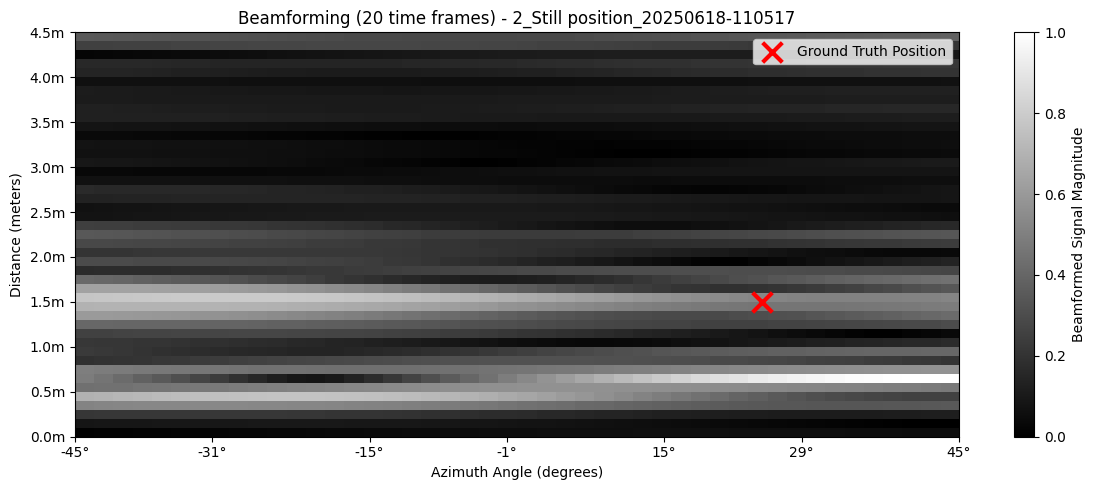


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2']

--- Blob analysis complete ---
  '2' detected in 80 windows, starting at frames: [30, 100, 120, 130, 160, 170, 190, 210, 220, 230, 240, 250, 260, 280, 290, 300, 310, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 470, 480, 490, 520, 530, 540, 550, 560, 570, 580, 590, 600, 620, 630, 640, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 810, 830, 840, 850, 860, 870, 880, 930, 1000, 1020, 1030, 1040, 1050, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1160, 1170]

--- Summary of detected blobs (GTs = ['2']) ---
  '2' was detected in 80 windows.

Processing file: /kaggle/input/haeeai-project-uwb/SR250Mate/4-14_Still position_20250618-143220_sr250_rx0.npy
--- FILENAME: /kaggle/input/haeeai-project-uwb/SR250Mate/4-14_Still position_202506

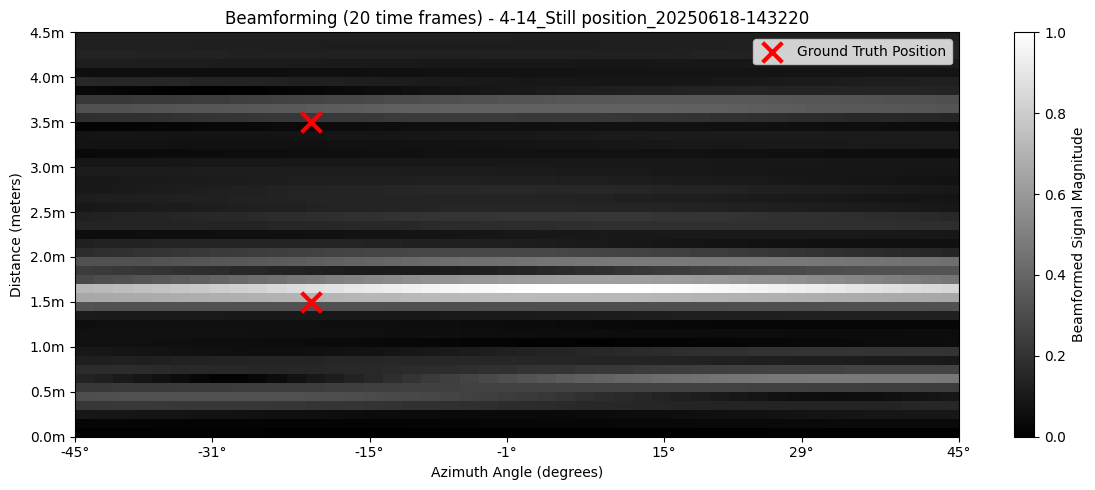


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '14']

--- Blob analysis complete ---
  '4' detected in 111 windows, starting at frames: [0, 10, 20, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 490, 500, 510, 520, 530, 540, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 830, 850, 860, 870, 880, 890, 900, 910, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180]
  '14' detected in 1 windows, starting at frames: [480]

--- Summary of detected blobs (GTs = ['4', '14']) ---
  '4' wa

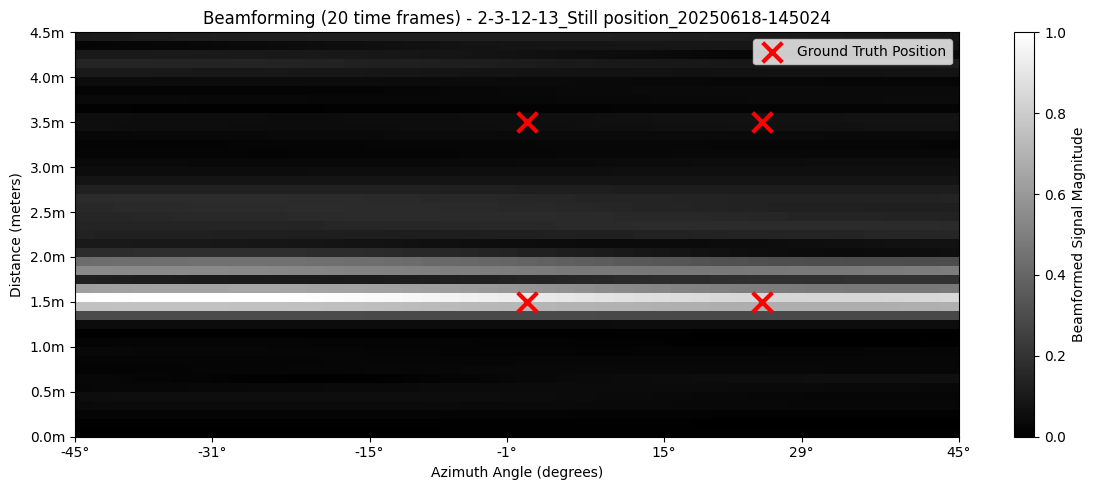


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '3', '12', '13']

--- Blob analysis complete ---
  '2' detected in 104 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 80, 100, 110, 120, 130, 140, 150, 170, 180, 200, 210, 220, 230, 240, 250, 260, 270, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 470, 480, 490, 500, 510, 520, 540, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 860, 870, 880, 890, 900, 910, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1080, 1100, 1110, 1120, 1130, 1140, 1150, 1170, 1180]
  '3' detected in 112 windows, starting at frames: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 200, 210,

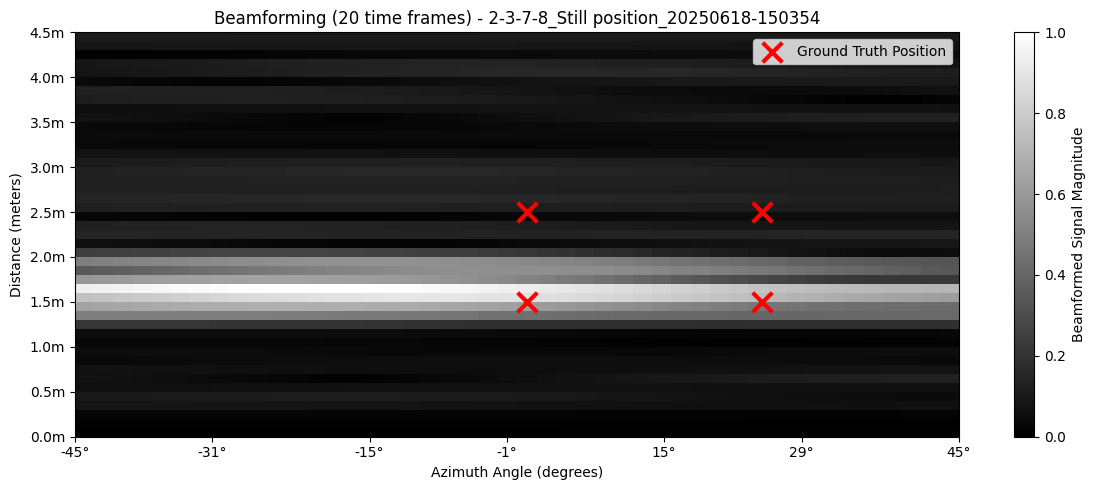


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['2', '3', '7', '8']

--- Blob analysis complete ---
  '2' detected in 66 windows, starting at frames: [0, 20, 30, 40, 50, 60, 150, 170, 190, 210, 220, 240, 290, 310, 320, 330, 360, 370, 390, 440, 460, 480, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 660, 670, 700, 730, 770, 790, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 950, 960, 970, 990, 1000, 1010, 1020, 1090, 1120, 1140, 1160, 1170, 1180]
  '3' detected in 99 windows, starting at frames: [0, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 190, 200, 210, 220, 240, 250, 260, 280, 290, 310, 320, 330, 340, 350, 360, 370, 390, 410, 420, 430, 440, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 640, 650, 660, 670, 690, 70

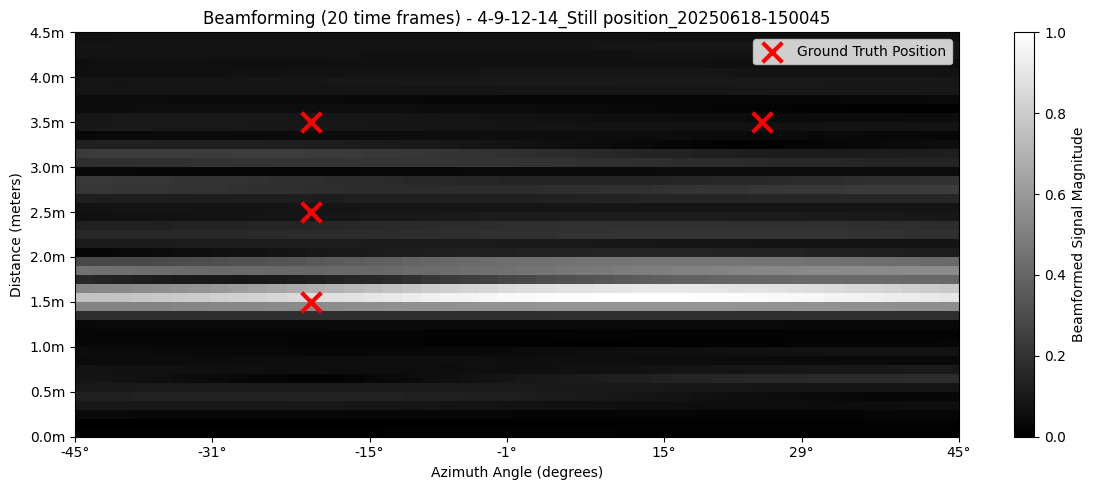


--- Analyzing blobs in time windows (Window size: 20 frames, Stride: 10 frames) ---
Total time frames available for analysis: 1200
Detection threshold for normalized value: 0.6
Analyzing only the following GT positions: ['4', '9', '12', '14']

--- Blob analysis complete ---
  '4' detected in 71 windows, starting at frames: [0, 10, 20, 30, 50, 60, 70, 80, 90, 110, 120, 130, 140, 150, 160, 170, 190, 200, 210, 220, 240, 250, 270, 280, 300, 310, 320, 330, 510, 530, 540, 550, 560, 570, 590, 600, 610, 630, 640, 650, 660, 670, 680, 690, 700, 710, 770, 790, 920, 930, 940, 950, 960, 970, 990, 1010, 1020, 1030, 1040, 1050, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1170, 1180]
  '9' not detected above threshold in any window.
  '12' not detected above threshold in any window.
  '14' not detected above threshold in any window.

--- Summary of detected blobs (GTs = ['4', '9', '12', '14']) ---
  '4' was detected in 71 windows.
  '9' was NOT detected in any window above the threshold.
  

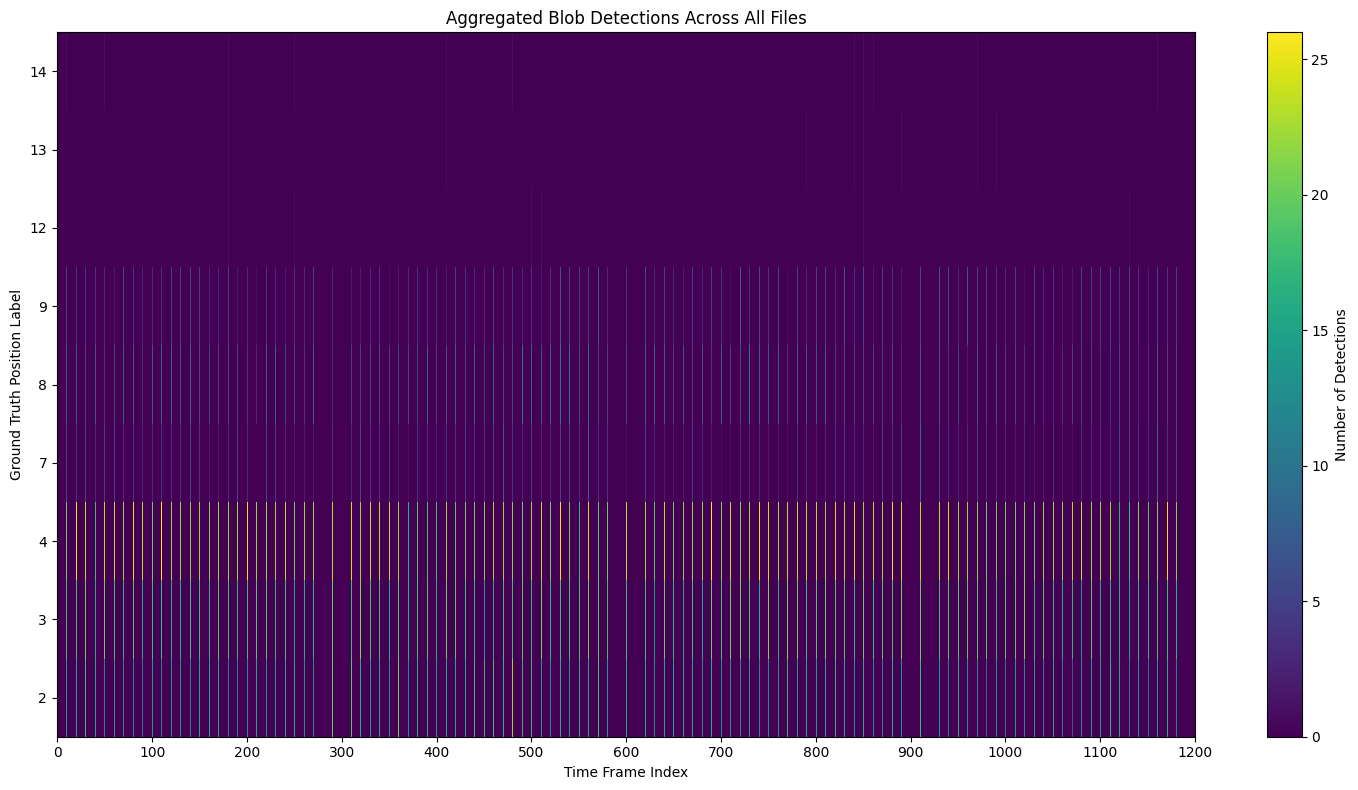

In [17]:
# Define the nine ground truth labels in a fixed order for the Y-axis
# Ensure these match the keys in your `ground_truth_positions` dictionary
gt_labels_ordered = ["2", "3", "4", "7", "8", "9", "12", "13", "14"]
num_gt_labels = len(gt_labels_ordered)

# Define the maximum frame index for the X-axis (0 to 1200 as per requirement)
max_frame_index = 1200
num_frames_xaxis = max_frame_index + 1 # Because it includes 0

# Initialize the aggregation matrix with zeros
# Rows: GT labels, Columns: Frame indices (0 to max_frame_index)
# This matrix will store the count of detections for each (GT_label, frame_index) pair
blob_detection_counts = np.zeros(
    (num_gt_labels, num_frames_xaxis), dtype=int
)

# Create a mapping from GT label to its corresponding row index for easy access
gt_label_to_row_idx = {label: i for i, label in enumerate(gt_labels_ordered)}

print("Starting to process all SR250Mate files for aggregated blob detection...")

total_num_files_processed = 0
# Use os.walk to correctly traverse the directory structure
for dirname, _, filenames in os.walk('/kaggle/input/haeeai-project-uwb/SR250Mate'):
    for filename in filenames:
        # We only process 'rx0.npy' files, as visualise_sr250 will automatically load rx1 and rx2
        # Ensure the filename ends exactly with "_rx0.npy" to avoid processing other variations if any
        # Skip the "move" file
        if filename.endswith("_rx0.npy") and not filename.startswith("(move)"):
            full_path_filename = os.path.join(dirname, filename)
            print(f"\nProcessing file: {full_path_filename}")
            
            # Call the modified extract_best_blobs to get the dictionary of detected frames
            current_file_detections = extract_best_blobs(full_path_filename)

            # If data was successfully processed and blob detections were returned
            if current_file_detections:
                total_num_files_processed += 1
                # Iterate through the detected blobs for the current file
                for gt_label, detected_frames_list in current_file_detections.items():
                    # Only process labels that are part of our defined Y-axis and actually have detections
                    if gt_label in gt_label_to_row_idx and detected_frames_list:
                        row_idx = gt_label_to_row_idx[gt_label]
                        for frame_idx in detected_frames_list:
                            # Only increment if the frame_idx is within our desired X-axis range
                            if 0 <= frame_idx <= max_frame_index:
                                blob_detection_counts[row_idx, frame_idx] += 1
                            else:
                                print(f"Warning: Detected frame {frame_idx} for GT '{gt_label}' is out of the [0, {max_frame_index}] range. Skipping count for this frame.")
            else:
                print(f"No blob detections returned for {full_path_filename}, or processing failed.")

print(f"\n--- Finished processing {total_num_files_processed} eligible files. ---")
print(f"Aggregation matrix shape: {blob_detection_counts.shape}")

# --- Visualization of the aggregated 2D matrix ---
print("\nGenerating aggregated blob detection heatmap...")

plt.figure(figsize=(15, 8))
im = plt.imshow(
    blob_detection_counts,
    aspect='auto',
    origin='lower',  # Keep origin lower so frame 0 is at the bottom of the y-axis
    cmap='viridis',   # Or 'hot', 'magma', 'Greys', etc.
    interpolation='nearest'
)

plt.title('Aggregated Blob Detections Across All Files')
plt.xlabel('Time Frame Index')
plt.ylabel('Ground Truth Position Label')
plt.colorbar(im, label='Number of Detections')

# Set X-axis ticks to show meaningful intervals (e.g., every 100 frames)
x_ticks_interval = 100
plt.xticks(np.arange(0, num_frames_xaxis, x_ticks_interval))

# Set Y-axis ticks to show the GT labels
plt.yticks(np.arange(num_gt_labels), gt_labels_ordered)

plt.tight_layout()
plt.show()